# set up

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install adjustText

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/My Drive/codelab/direct_probe/attention

/content/drive/My Drive/codelab/direct_probe/attention


In [ ]:
cd ../DirectProbe/

/content/drive/My Drive/codelab/direct_probe/DirectProbe


In [ ]:
dfg_label = ['-1','0','1']
distance_label =  ['2.0','3.0','4.0','5.0','6.0']
siblings_label = ['0','1']

tasks = ['dfg','distance','siblings']
tasks_and_labels = [
    ('dfg',dfg_label),
    ('distance',distance_label),
    ('siblings',siblings_label)
    ]

# calculate layer-wise accuracy

In [ ]:
def get_label_accuracy(prediction_file, labels):
    correct = [0 for _ in labels]
    total = [0 for _ in labels]

    with open(prediction_file) as f:
        for line in f:
            predictions = line.rstrip('\n').split('\t')
            label, pred = predictions[0], predictions[1].split(',')[0]
            index_of_hyph = pred.index('-')
            predicted_label = pred[index_of_hyph+1:]

            index_of_label = labels.index(label)
            total[index_of_label] += 1
            if label == predicted_label:
                correct[index_of_label] += 1

    accuracy = []
    for cor, tot in zip(correct, total):
        accuracy.append(round(cor/tot, 3))
    #print(f'accuracy per label: {accuracy}')
    return accuracy

In [ ]:
def get_layer_wise_means(model,task,labels):
  layers = [3,4,6,8,10,11]
  means = []
  valid_layers=[]

  for layer in layers:

    predict_path = os.path.join(res_dir, task, model, str(layer), 'prediction.txt')
    if not os.path.exists(predict_path):
        continue
    try:
        acc = get_label_accuracy(predict_path, labels)
    except:
        continue
    mean_acc =np.mean(acc)
    means.append(mean_acc)
    print(f'mean accuracy of {model} at layer {layer} on {task} task : {round(mean_acc,3)}')
    valid_layers.append(layer)


  return valid_layers, means



In [ ]:
os.makedirs("./plots", exist_ok=True)
from adjustText import adjust_text
def layer_wise_mean_accuracy_all_tasks(models, colors,tasks_and_labels,models_name):

  layers = [3,4,6,8,10,11]
  markers = ['o', 's', '^']
  for (task,labels) in tasks_and_labels:
    plt.figure(figsize=(8, 6), dpi=300)
    texts = []
    for i, (model, color, marker) in enumerate(zip(models, colors,markers)):
        valid_layers, means = get_layer_wise_means(model,task,labels)

        plt.plot(
                  valid_layers,
                  means,
                  marker=marker,
                  linestyle=':',
                  linewidth=2,
                  markersize=8,
                  color=color,
                  label=model
              )

        for x, y in zip(valid_layers, means):
            text = plt.annotate(f"{y:.3f}", xy=(x, y), fontsize=18,fontweight='bold')
            texts.append(text)
    adjust_text(texts)
    plt.yticks(fontsize=20)
    plt.xticks( ticks=layers,labels=[f"{l}" for l in layers],fontsize=22)
    plt.xlabel(f"layer",fontsize=22)
    plt.ylabel(f"mean accuracy across labels",fontsize=22)
    plt.legend(fontsize =17,loc='best',framealpha=0.7)
    plt.grid(axis='both', linestyle='--', alpha=0.6)
    plt.tight_layout()
    title =f"layer_wise_trend_{models_name}_{task}_task"
    plt.savefig(f"./plots/{title}.pdf", dpi=300)
    plt.show()


# layer-wise accuracy comparison - linear diagram

### codeSSM vs Rocoder

mean accuracy of codeSSM at layer 3 on dfg task : 0.802
mean accuracy of codeSSM at layer 4 on dfg task : 0.788
mean accuracy of codeSSM at layer 6 on dfg task : 0.806
mean accuracy of codeSSM at layer 8 on dfg task : 0.824
mean accuracy of codeSSM at layer 10 on dfg task : 0.82
mean accuracy of codeSSM at layer 11 on dfg task : 0.82
mean accuracy of rocoder at layer 3 on dfg task : 0.775
mean accuracy of rocoder at layer 4 on dfg task : 0.794
mean accuracy of rocoder at layer 6 on dfg task : 0.808
mean accuracy of rocoder at layer 8 on dfg task : 0.818
mean accuracy of rocoder at layer 10 on dfg task : 0.797
mean accuracy of rocoder at layer 11 on dfg task : 0.794


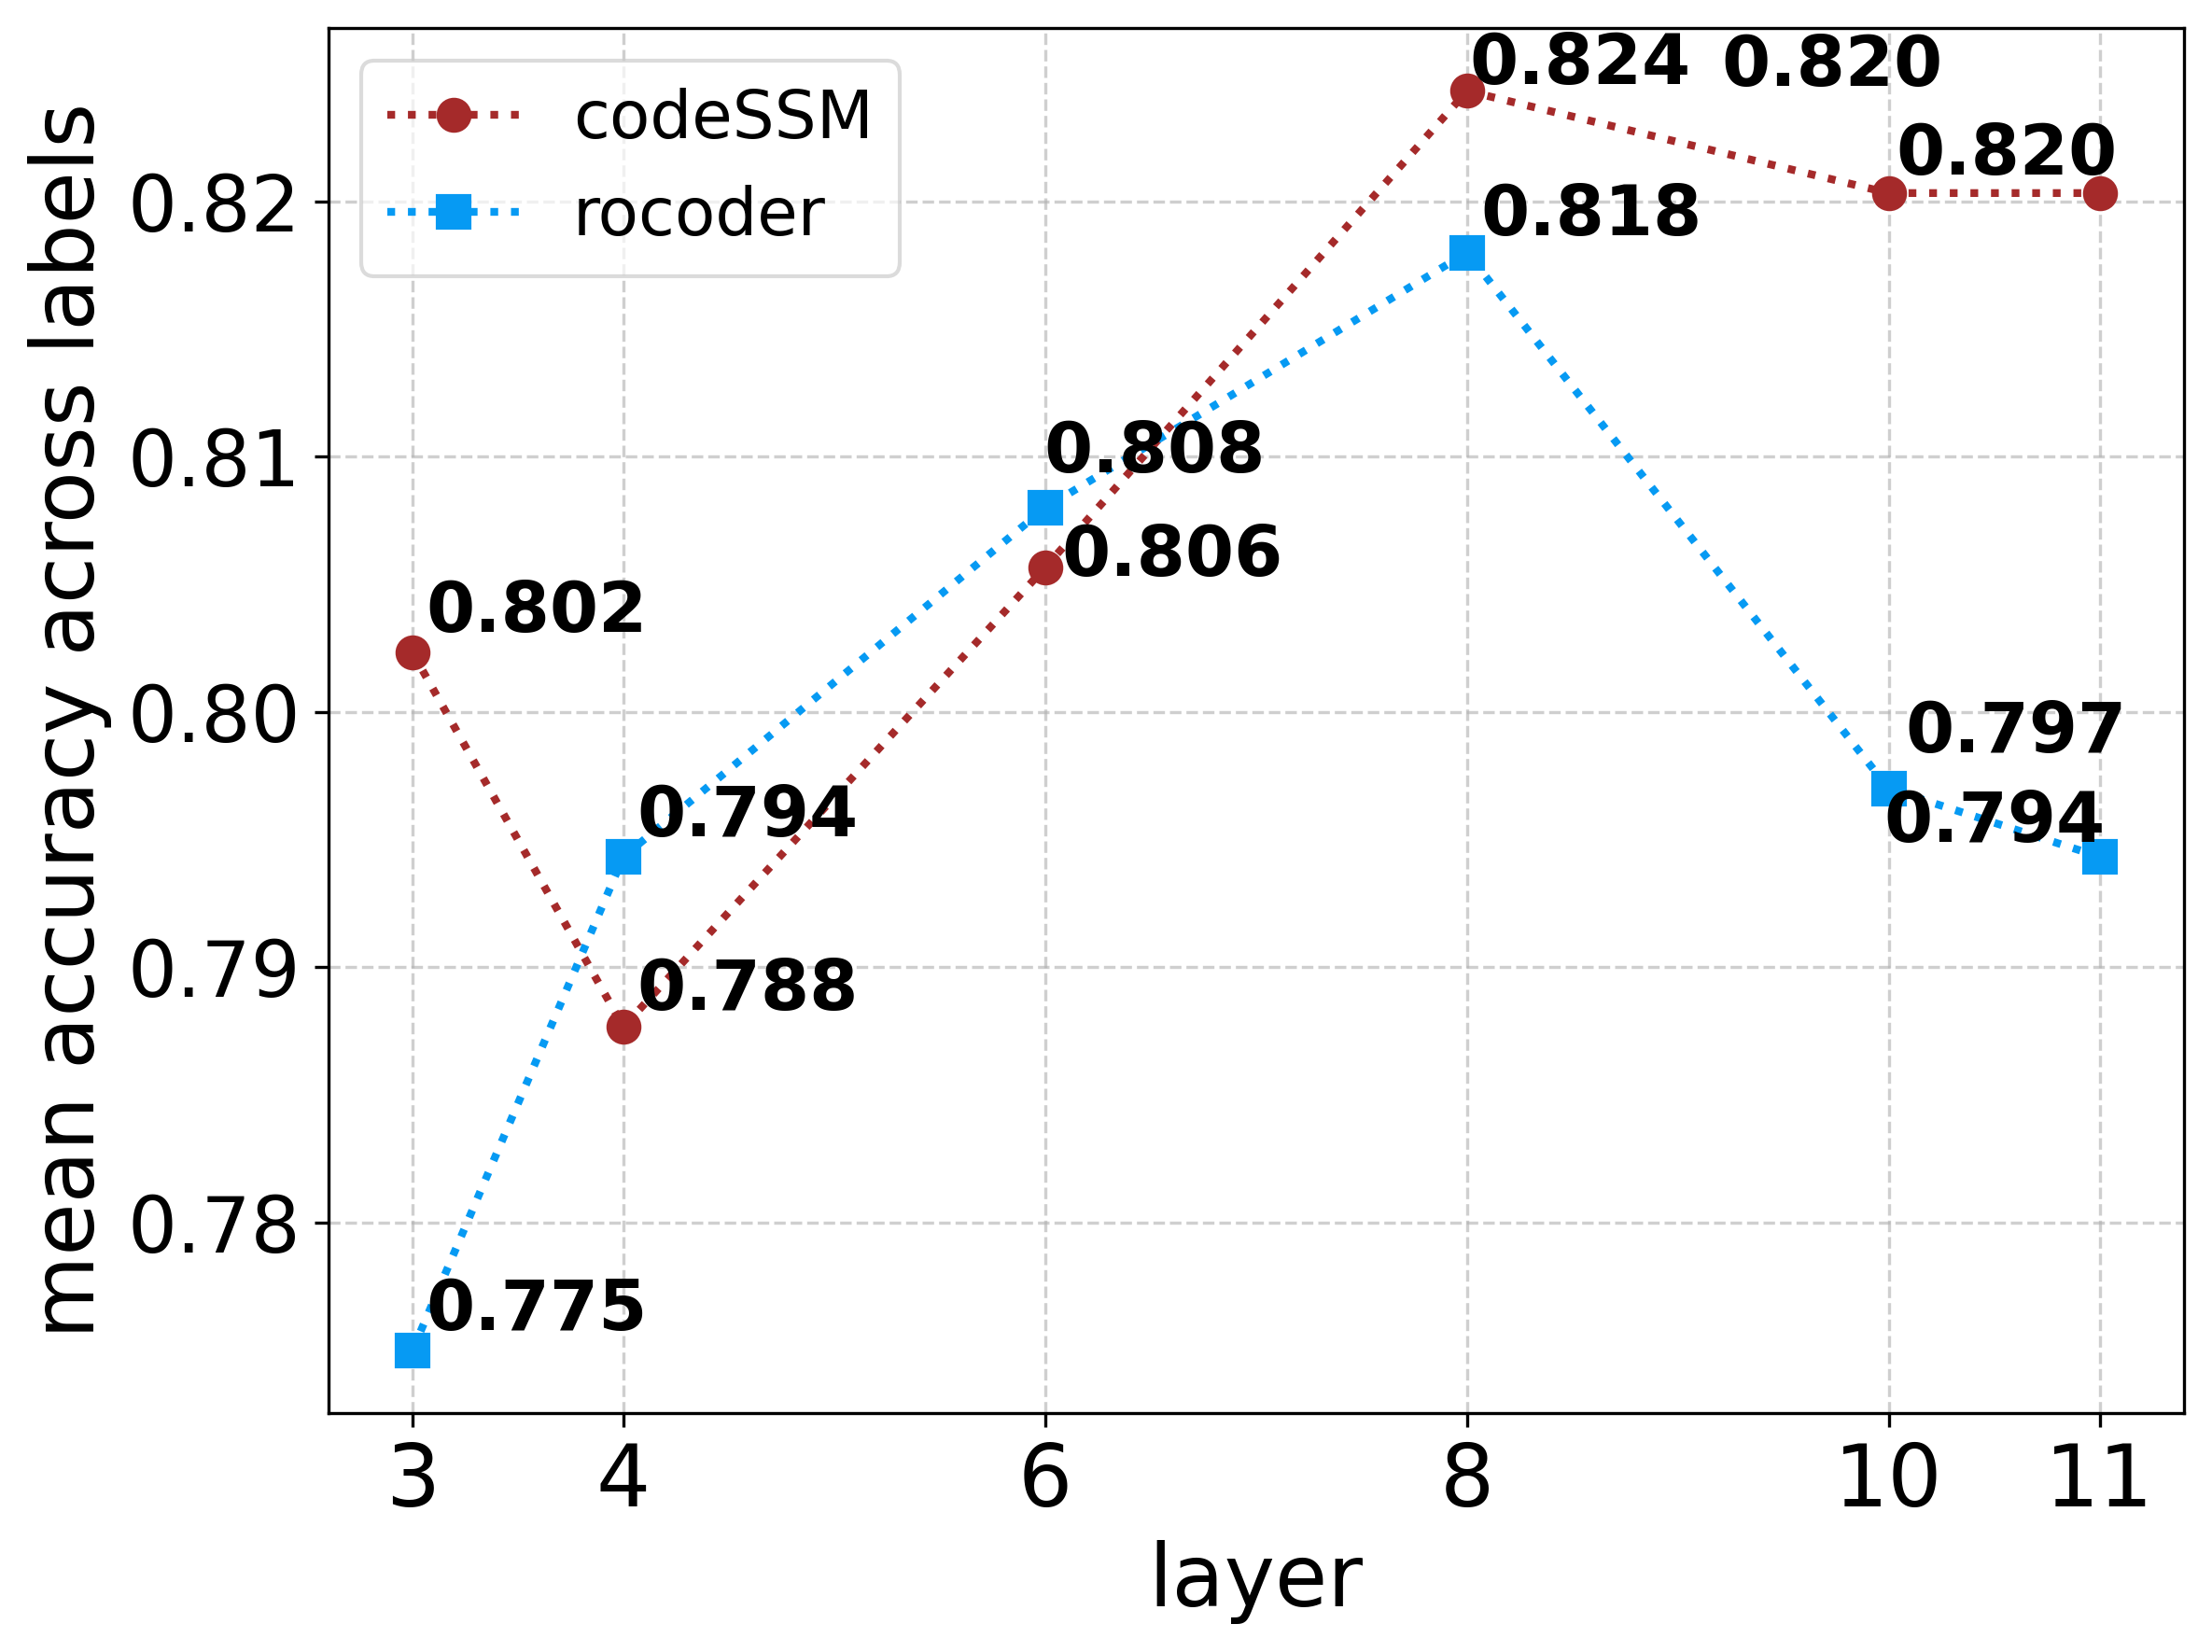

mean accuracy of codeSSM at layer 3 on distance task : 0.59
mean accuracy of codeSSM at layer 4 on distance task : 0.603
mean accuracy of codeSSM at layer 6 on distance task : 0.621
mean accuracy of codeSSM at layer 8 on distance task : 0.623
mean accuracy of codeSSM at layer 10 on distance task : 0.632
mean accuracy of codeSSM at layer 11 on distance task : 0.626
mean accuracy of rocoder at layer 3 on distance task : 0.559
mean accuracy of rocoder at layer 4 on distance task : 0.574
mean accuracy of rocoder at layer 6 on distance task : 0.595
mean accuracy of rocoder at layer 8 on distance task : 0.581
mean accuracy of rocoder at layer 10 on distance task : 0.515


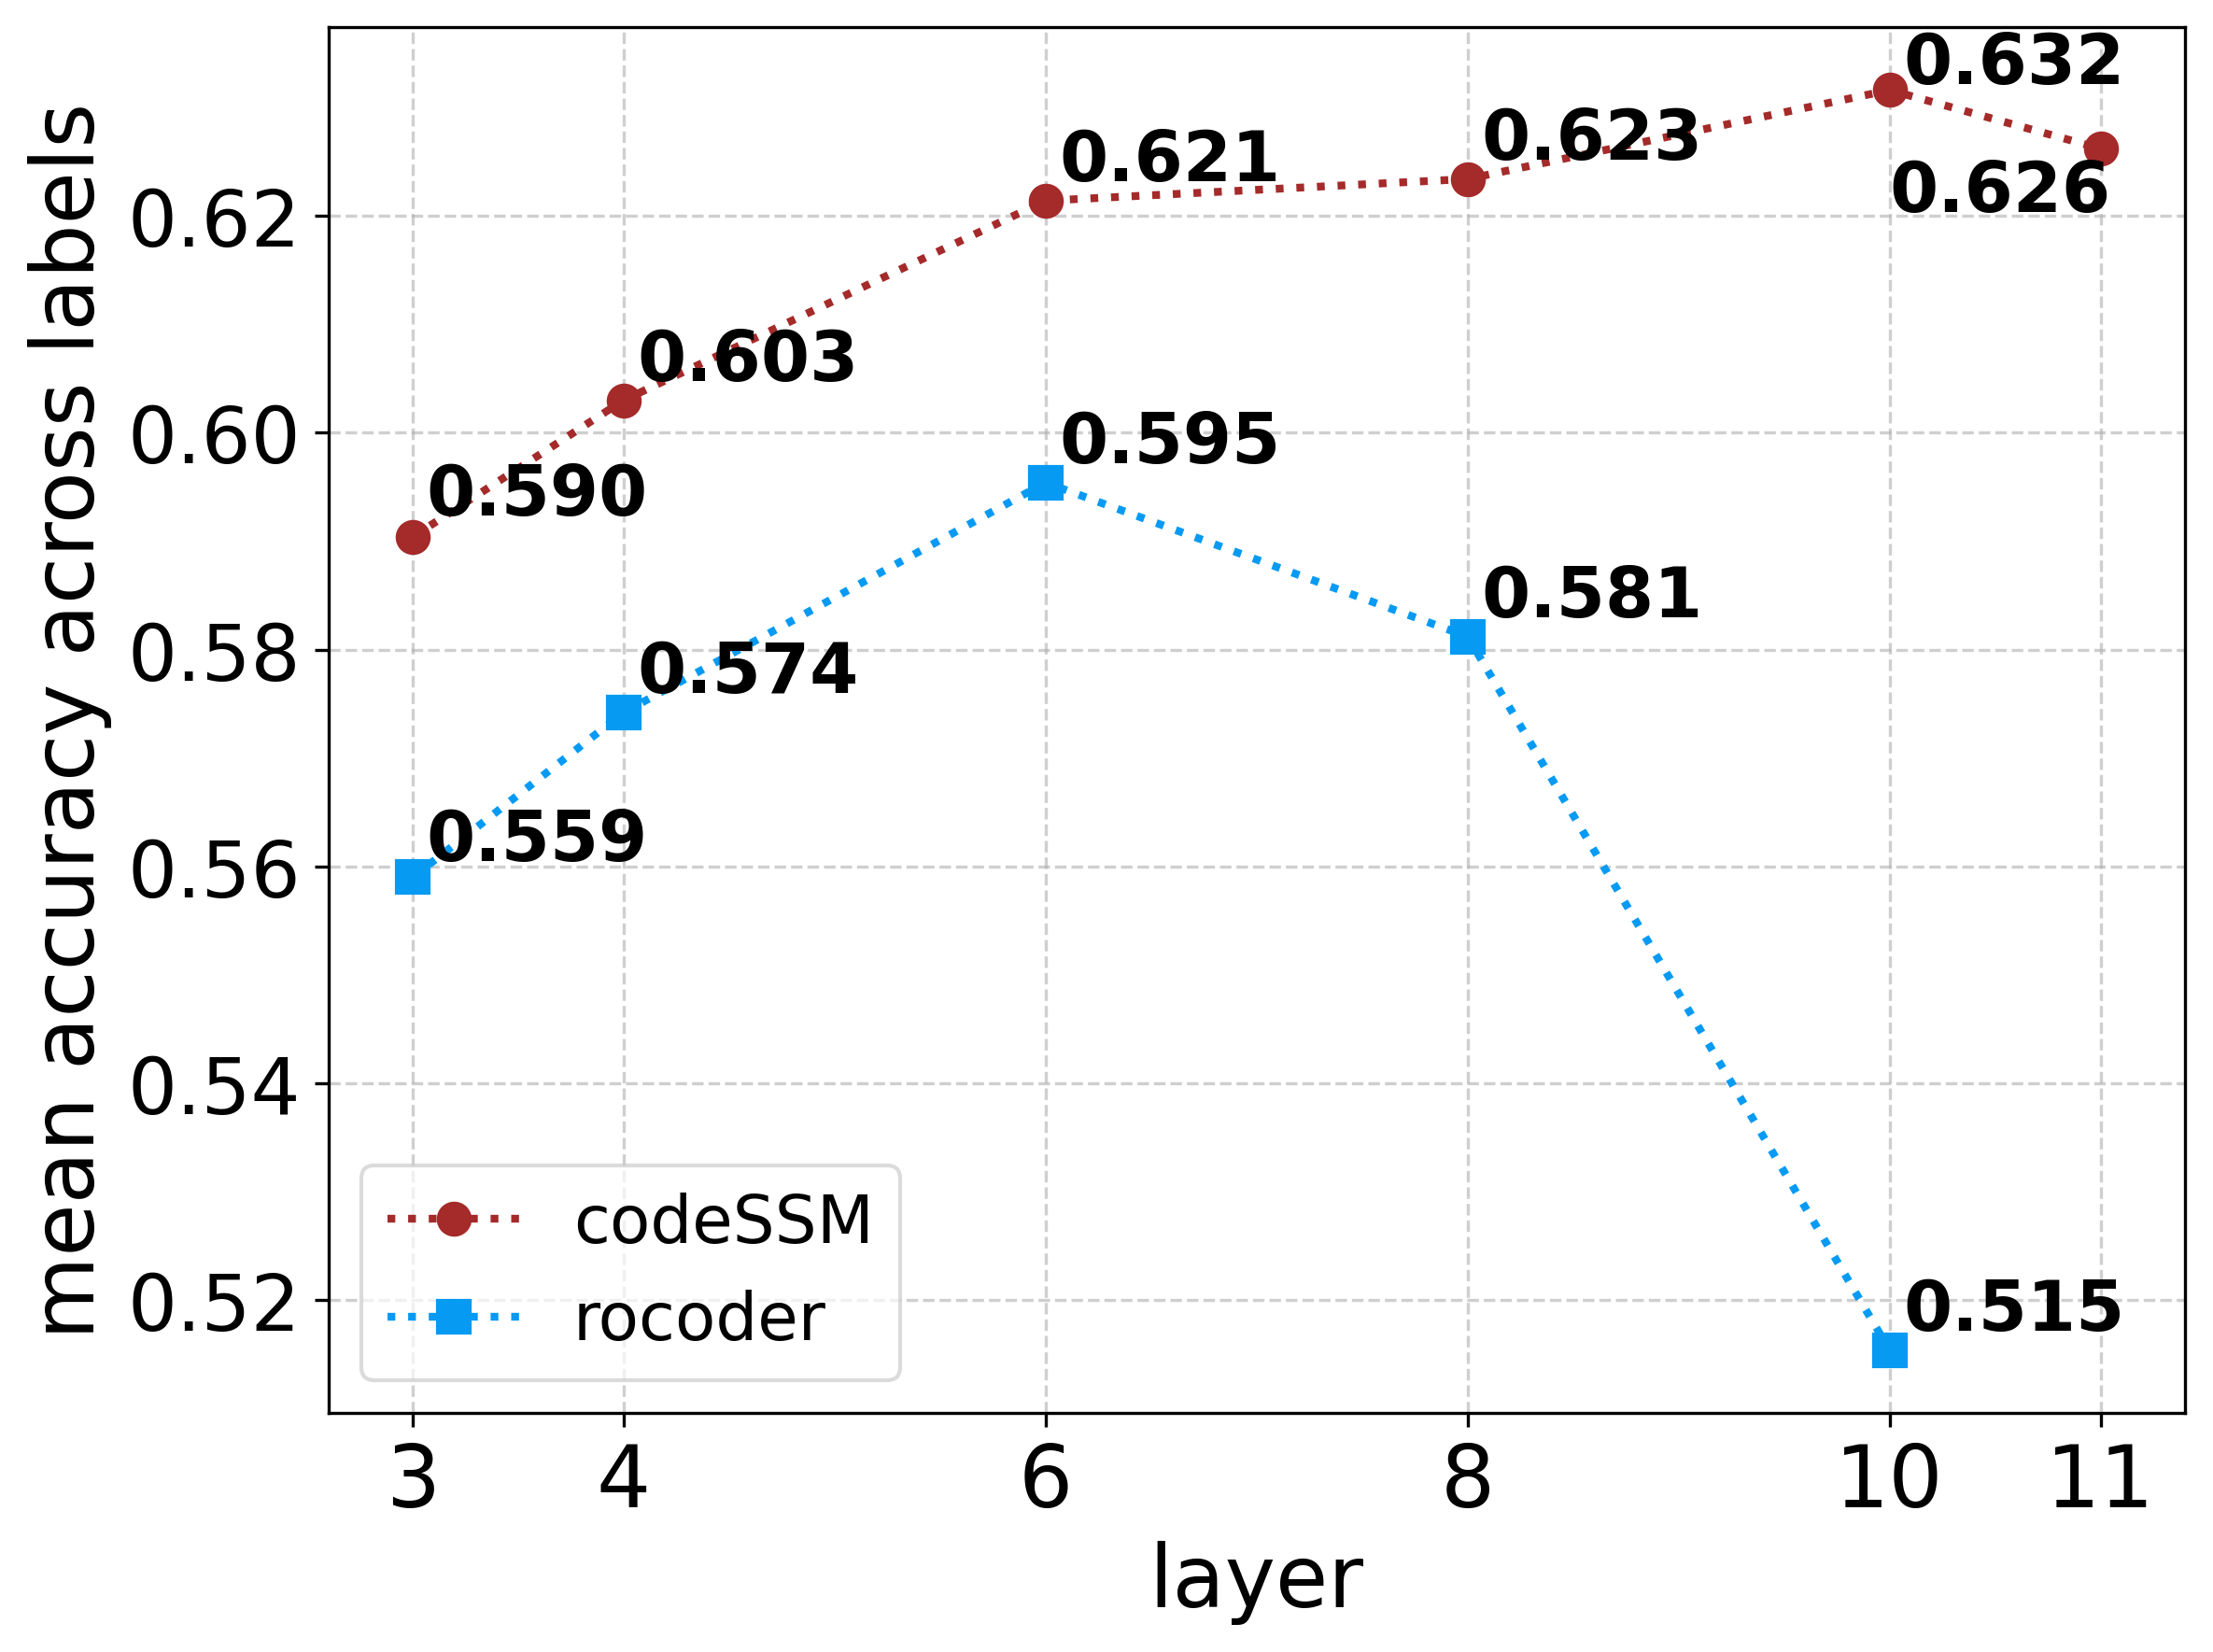

mean accuracy of codeSSM at layer 3 on siblings task : 0.817
mean accuracy of codeSSM at layer 4 on siblings task : 0.818
mean accuracy of codeSSM at layer 6 on siblings task : 0.837
mean accuracy of codeSSM at layer 8 on siblings task : 0.854
mean accuracy of codeSSM at layer 10 on siblings task : 0.847
mean accuracy of codeSSM at layer 11 on siblings task : 0.83
mean accuracy of rocoder at layer 3 on siblings task : 0.755
mean accuracy of rocoder at layer 4 on siblings task : 0.766
mean accuracy of rocoder at layer 6 on siblings task : 0.796
mean accuracy of rocoder at layer 8 on siblings task : 0.789
mean accuracy of rocoder at layer 10 on siblings task : 0.722
mean accuracy of rocoder at layer 11 on siblings task : 0.688


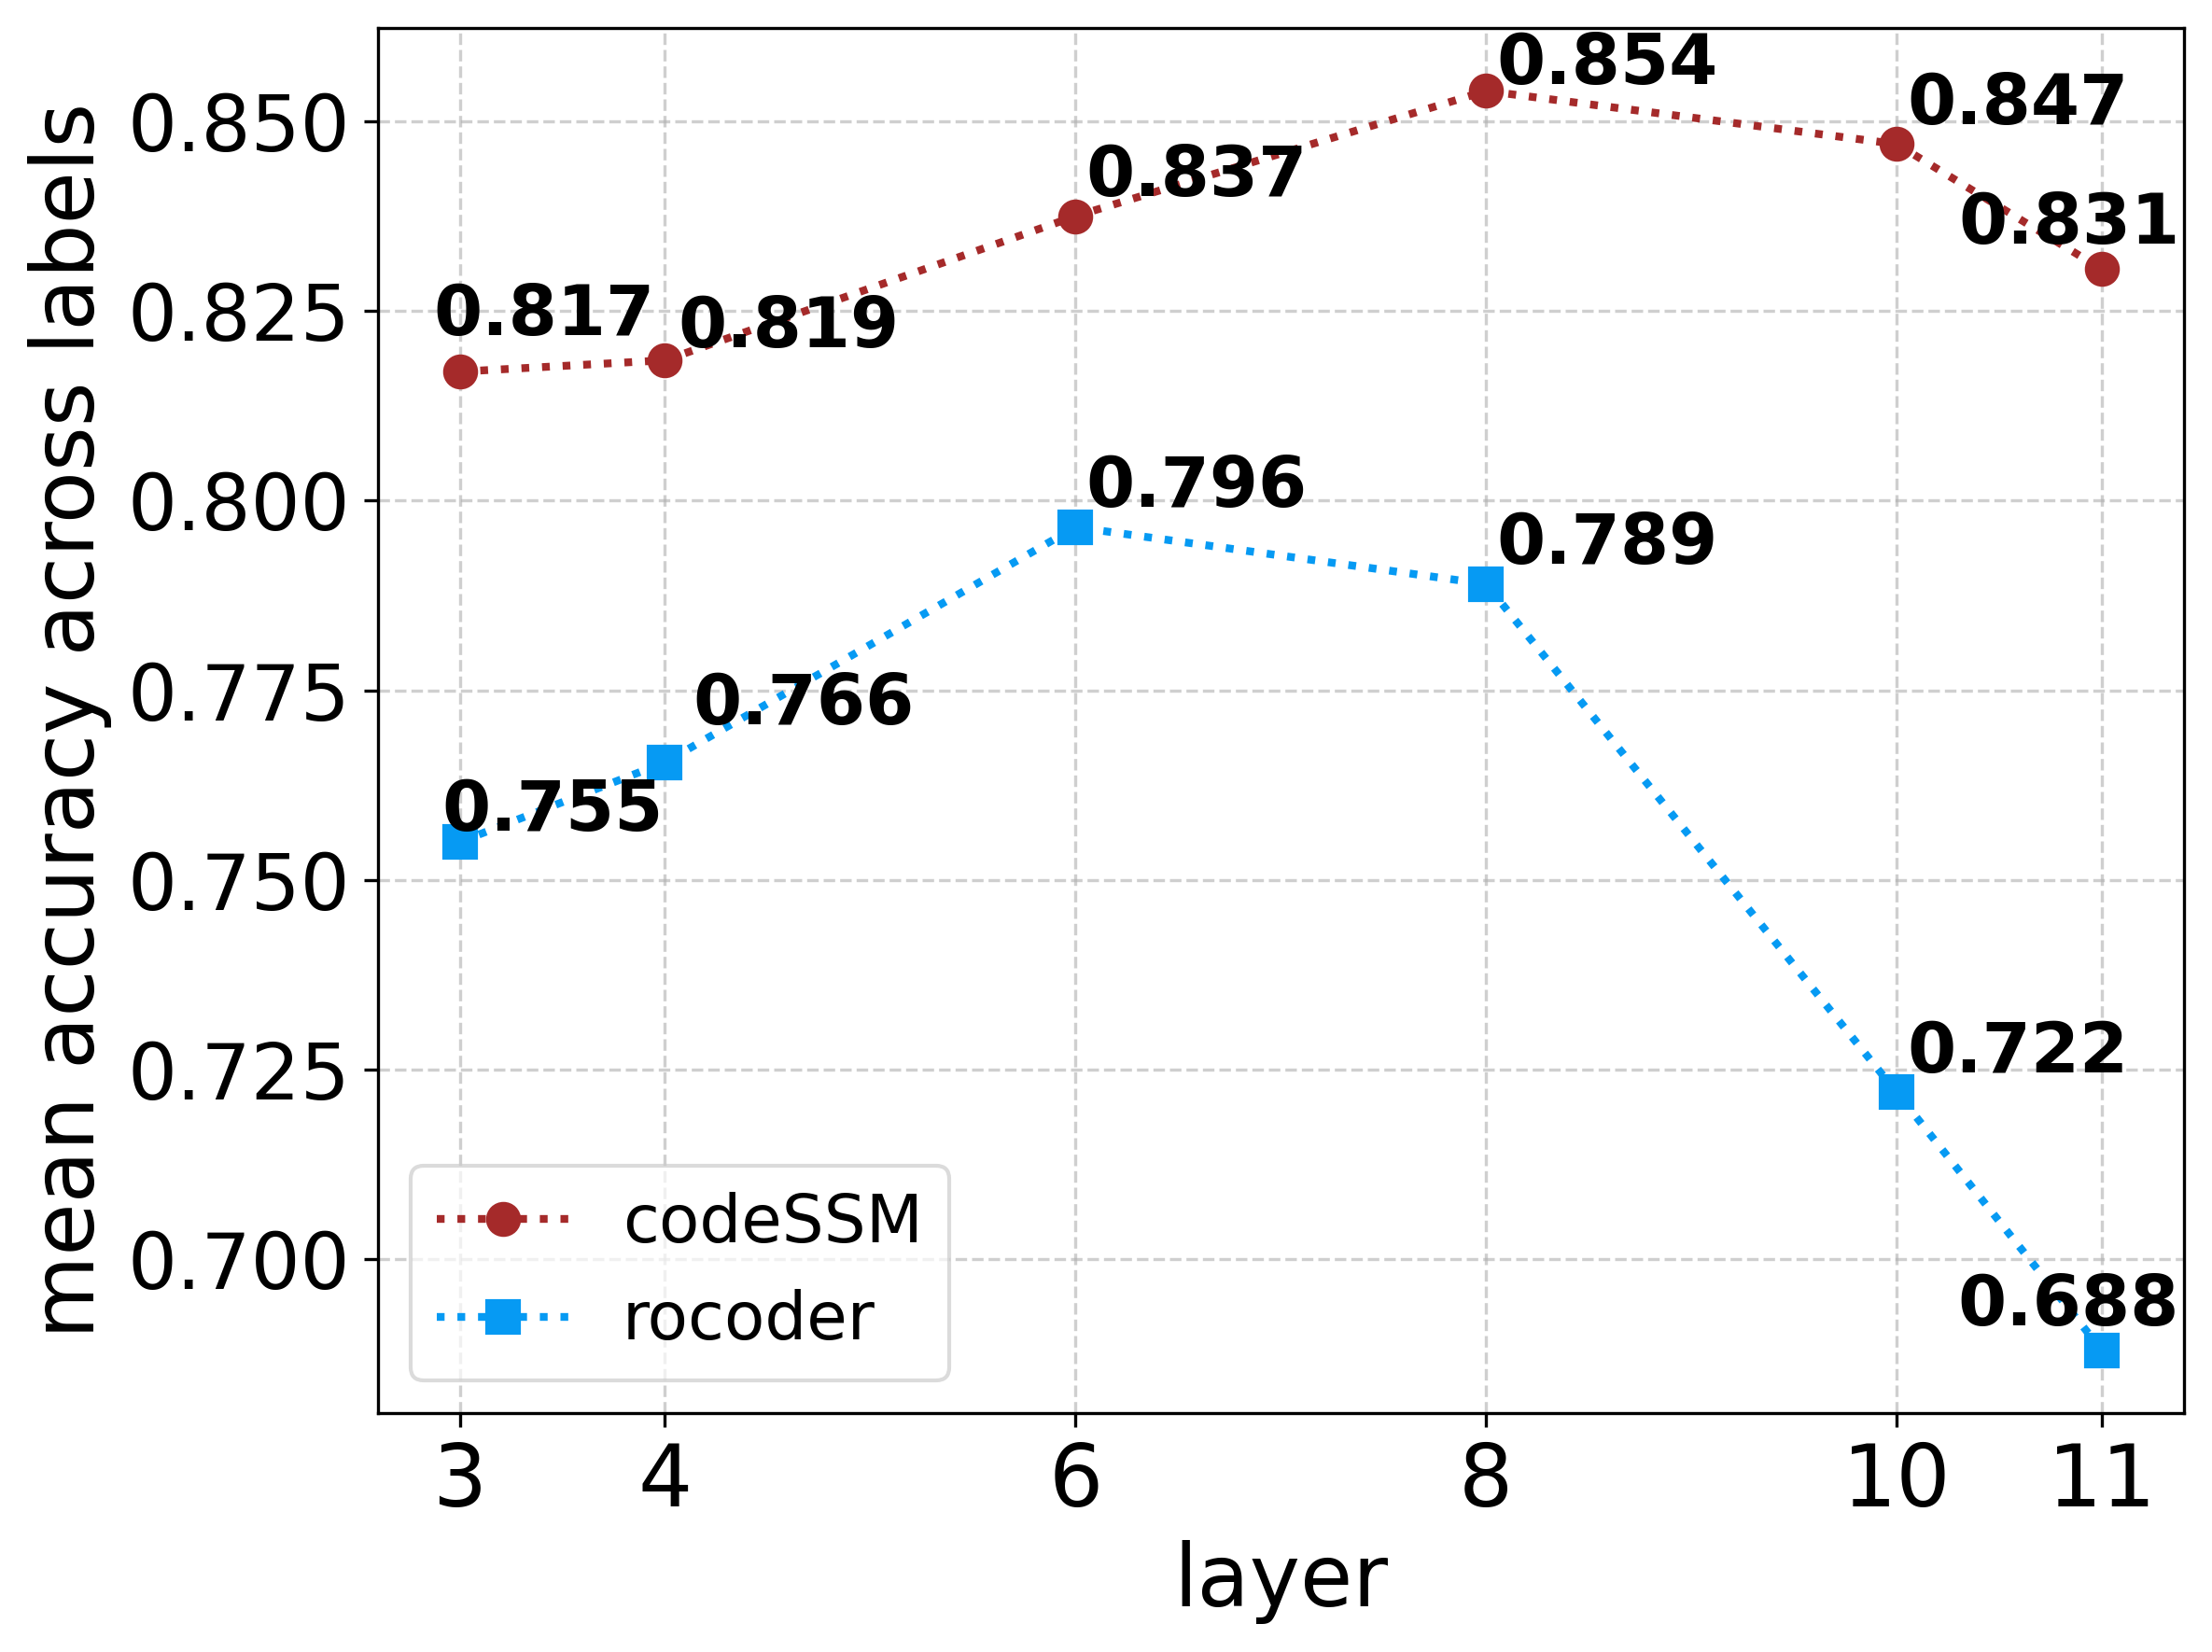

In [ ]:
res_dir = '../DirectProbe/results/'
codessm_rocoder_models = ['codeSSM', 'rocoder']
models_name = 'CodeSSM_and_Rocoder'
colors = ['#a52a2A', '#069AF3']
layer_wise_mean_accuracy_all_tasks(codessm_rocoder_models ,colors, tasks_and_labels,models_name)

### codessm_sqa vs rocoder_sqa

mean accuracy of codessm_sqa at layer 3 on dfg task : 0.78
mean accuracy of codessm_sqa at layer 4 on dfg task : 0.777
mean accuracy of codessm_sqa at layer 6 on dfg task : 0.782
mean accuracy of codessm_sqa at layer 8 on dfg task : 0.792
mean accuracy of codessm_sqa at layer 10 on dfg task : 0.807
mean accuracy of codessm_sqa at layer 11 on dfg task : 0.799
mean accuracy of rocoder_sqa at layer 3 on dfg task : 0.764
mean accuracy of rocoder_sqa at layer 4 on dfg task : 0.78
mean accuracy of rocoder_sqa at layer 6 on dfg task : 0.802
mean accuracy of rocoder_sqa at layer 8 on dfg task : 0.806
mean accuracy of rocoder_sqa at layer 10 on dfg task : 0.768
mean accuracy of rocoder_sqa at layer 11 on dfg task : 0.76


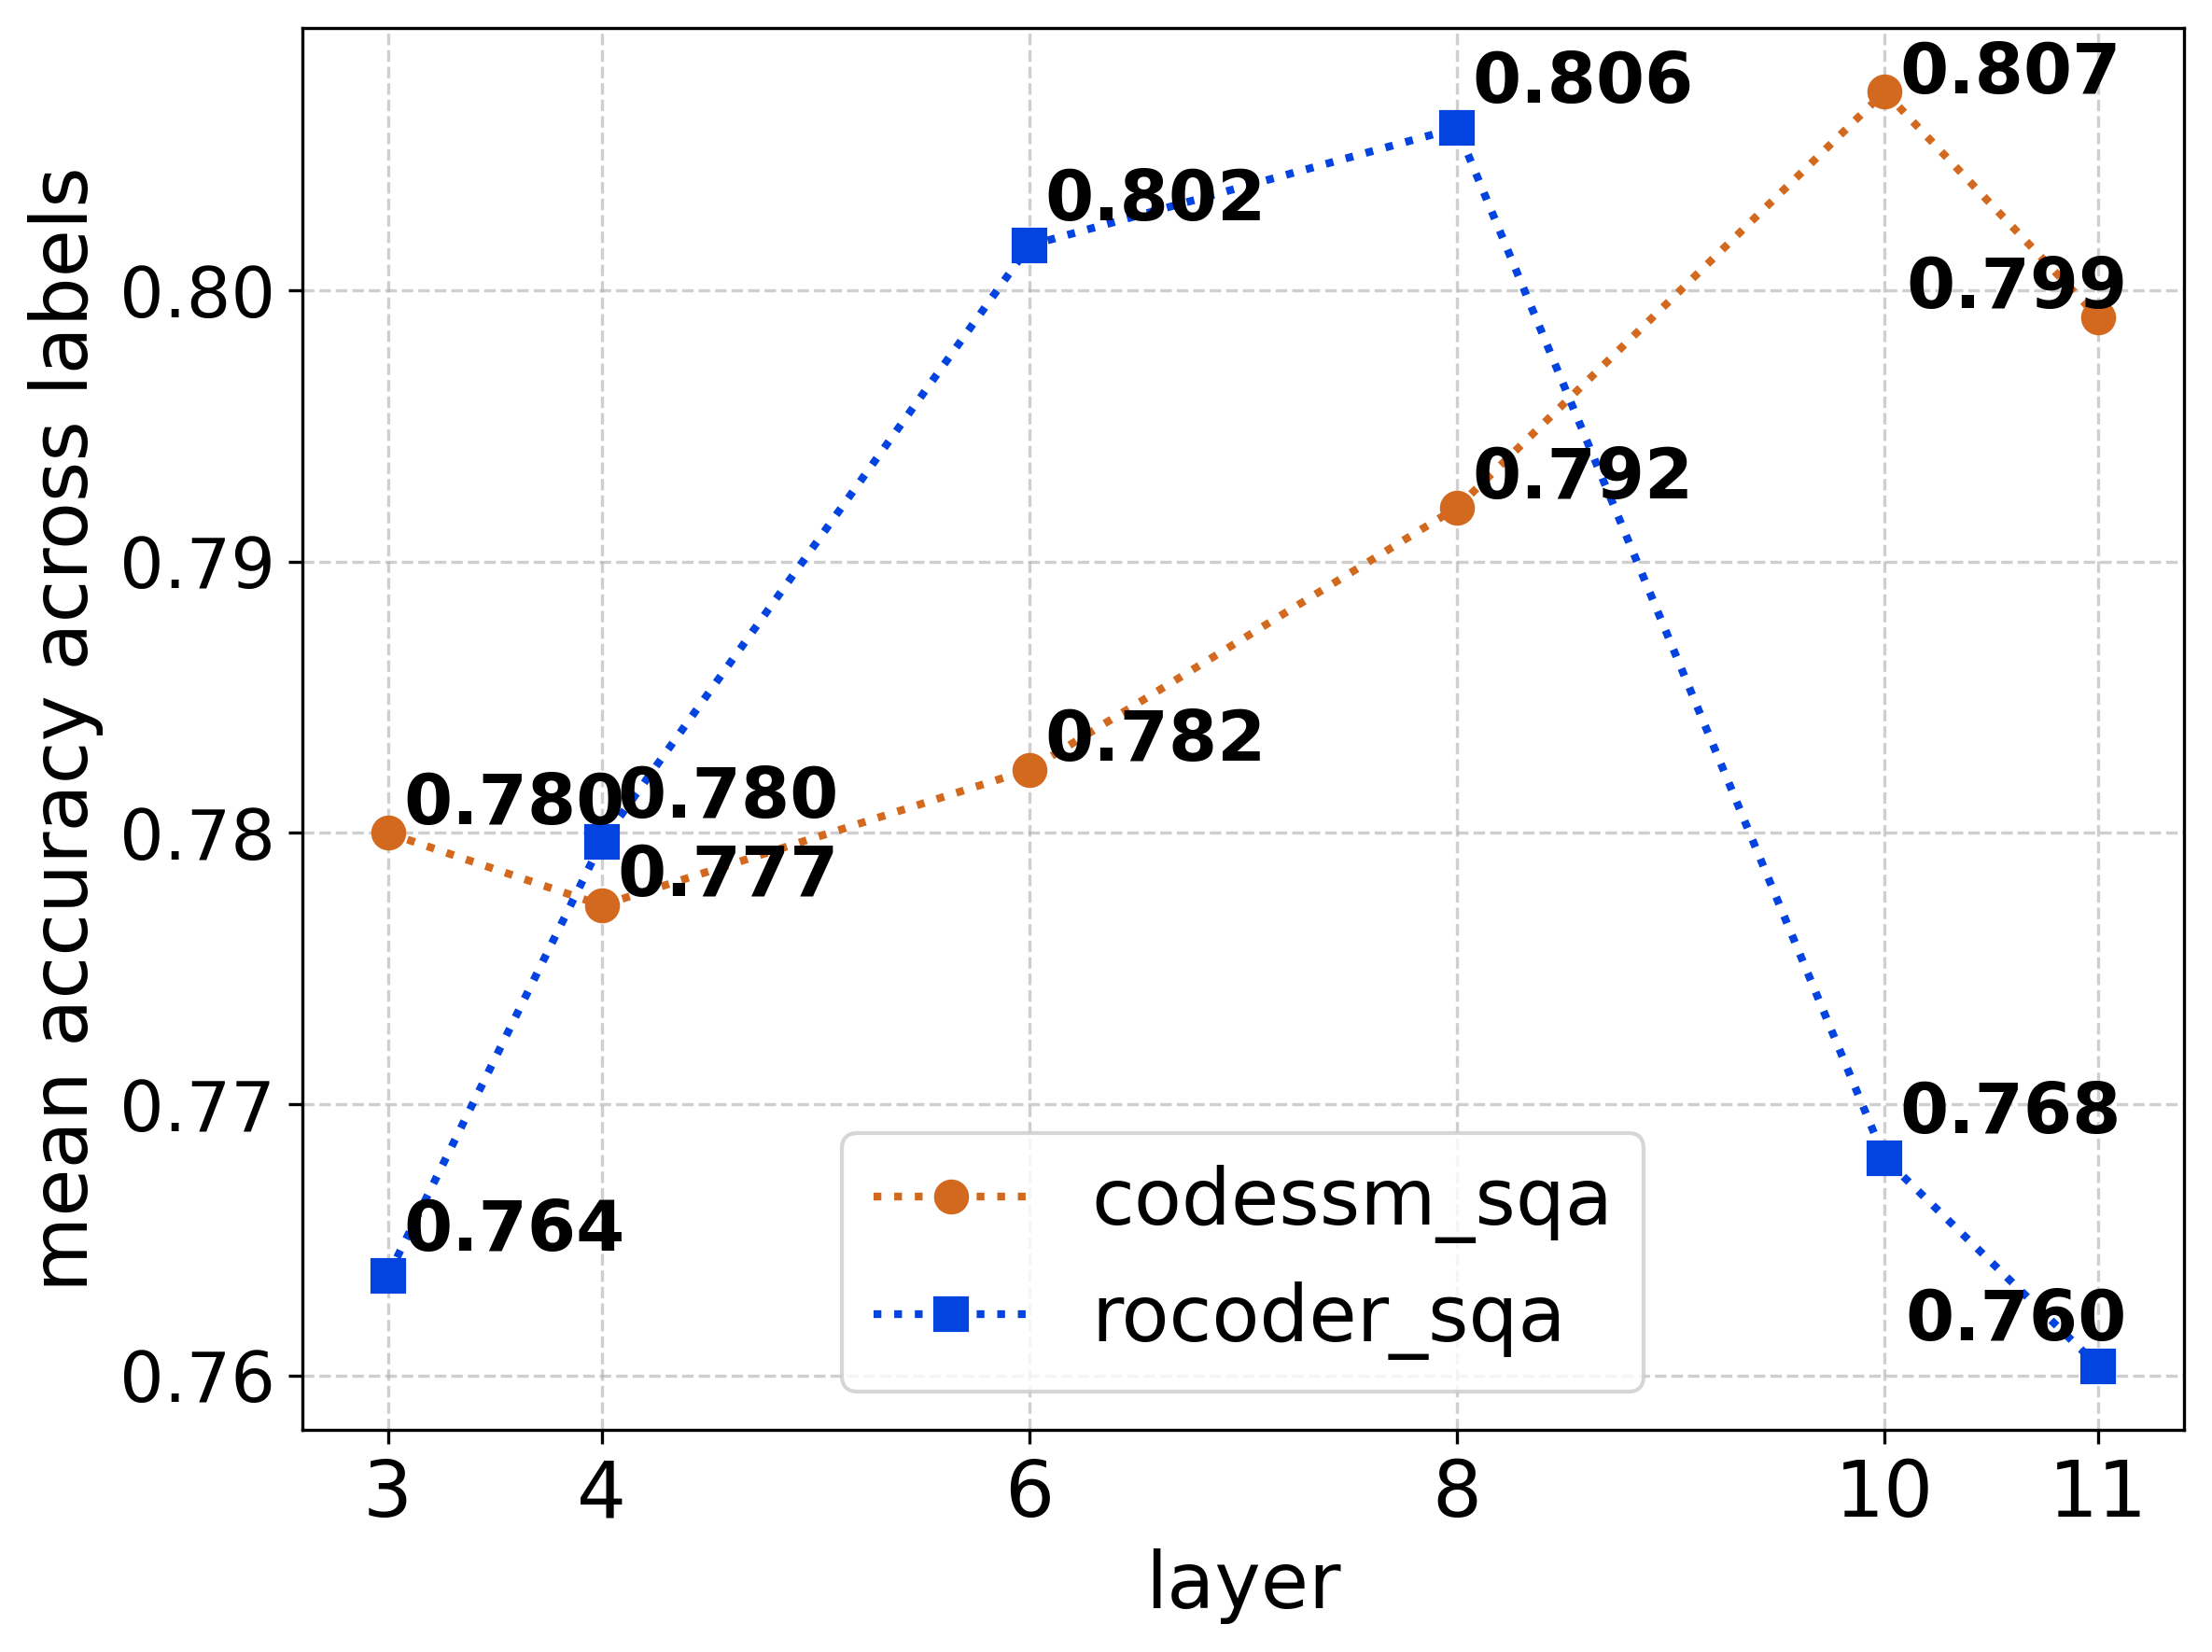

mean accuracy of codessm_sqa at layer 3 on distance task : 0.588
mean accuracy of codessm_sqa at layer 4 on distance task : 0.583
mean accuracy of codessm_sqa at layer 6 on distance task : 0.591
mean accuracy of codessm_sqa at layer 8 on distance task : 0.618
mean accuracy of codessm_sqa at layer 10 on distance task : 0.605
mean accuracy of codessm_sqa at layer 11 on distance task : 0.59
mean accuracy of rocoder_sqa at layer 3 on distance task : 0.573
mean accuracy of rocoder_sqa at layer 4 on distance task : 0.574
mean accuracy of rocoder_sqa at layer 6 on distance task : 0.578
mean accuracy of rocoder_sqa at layer 8 on distance task : 0.547


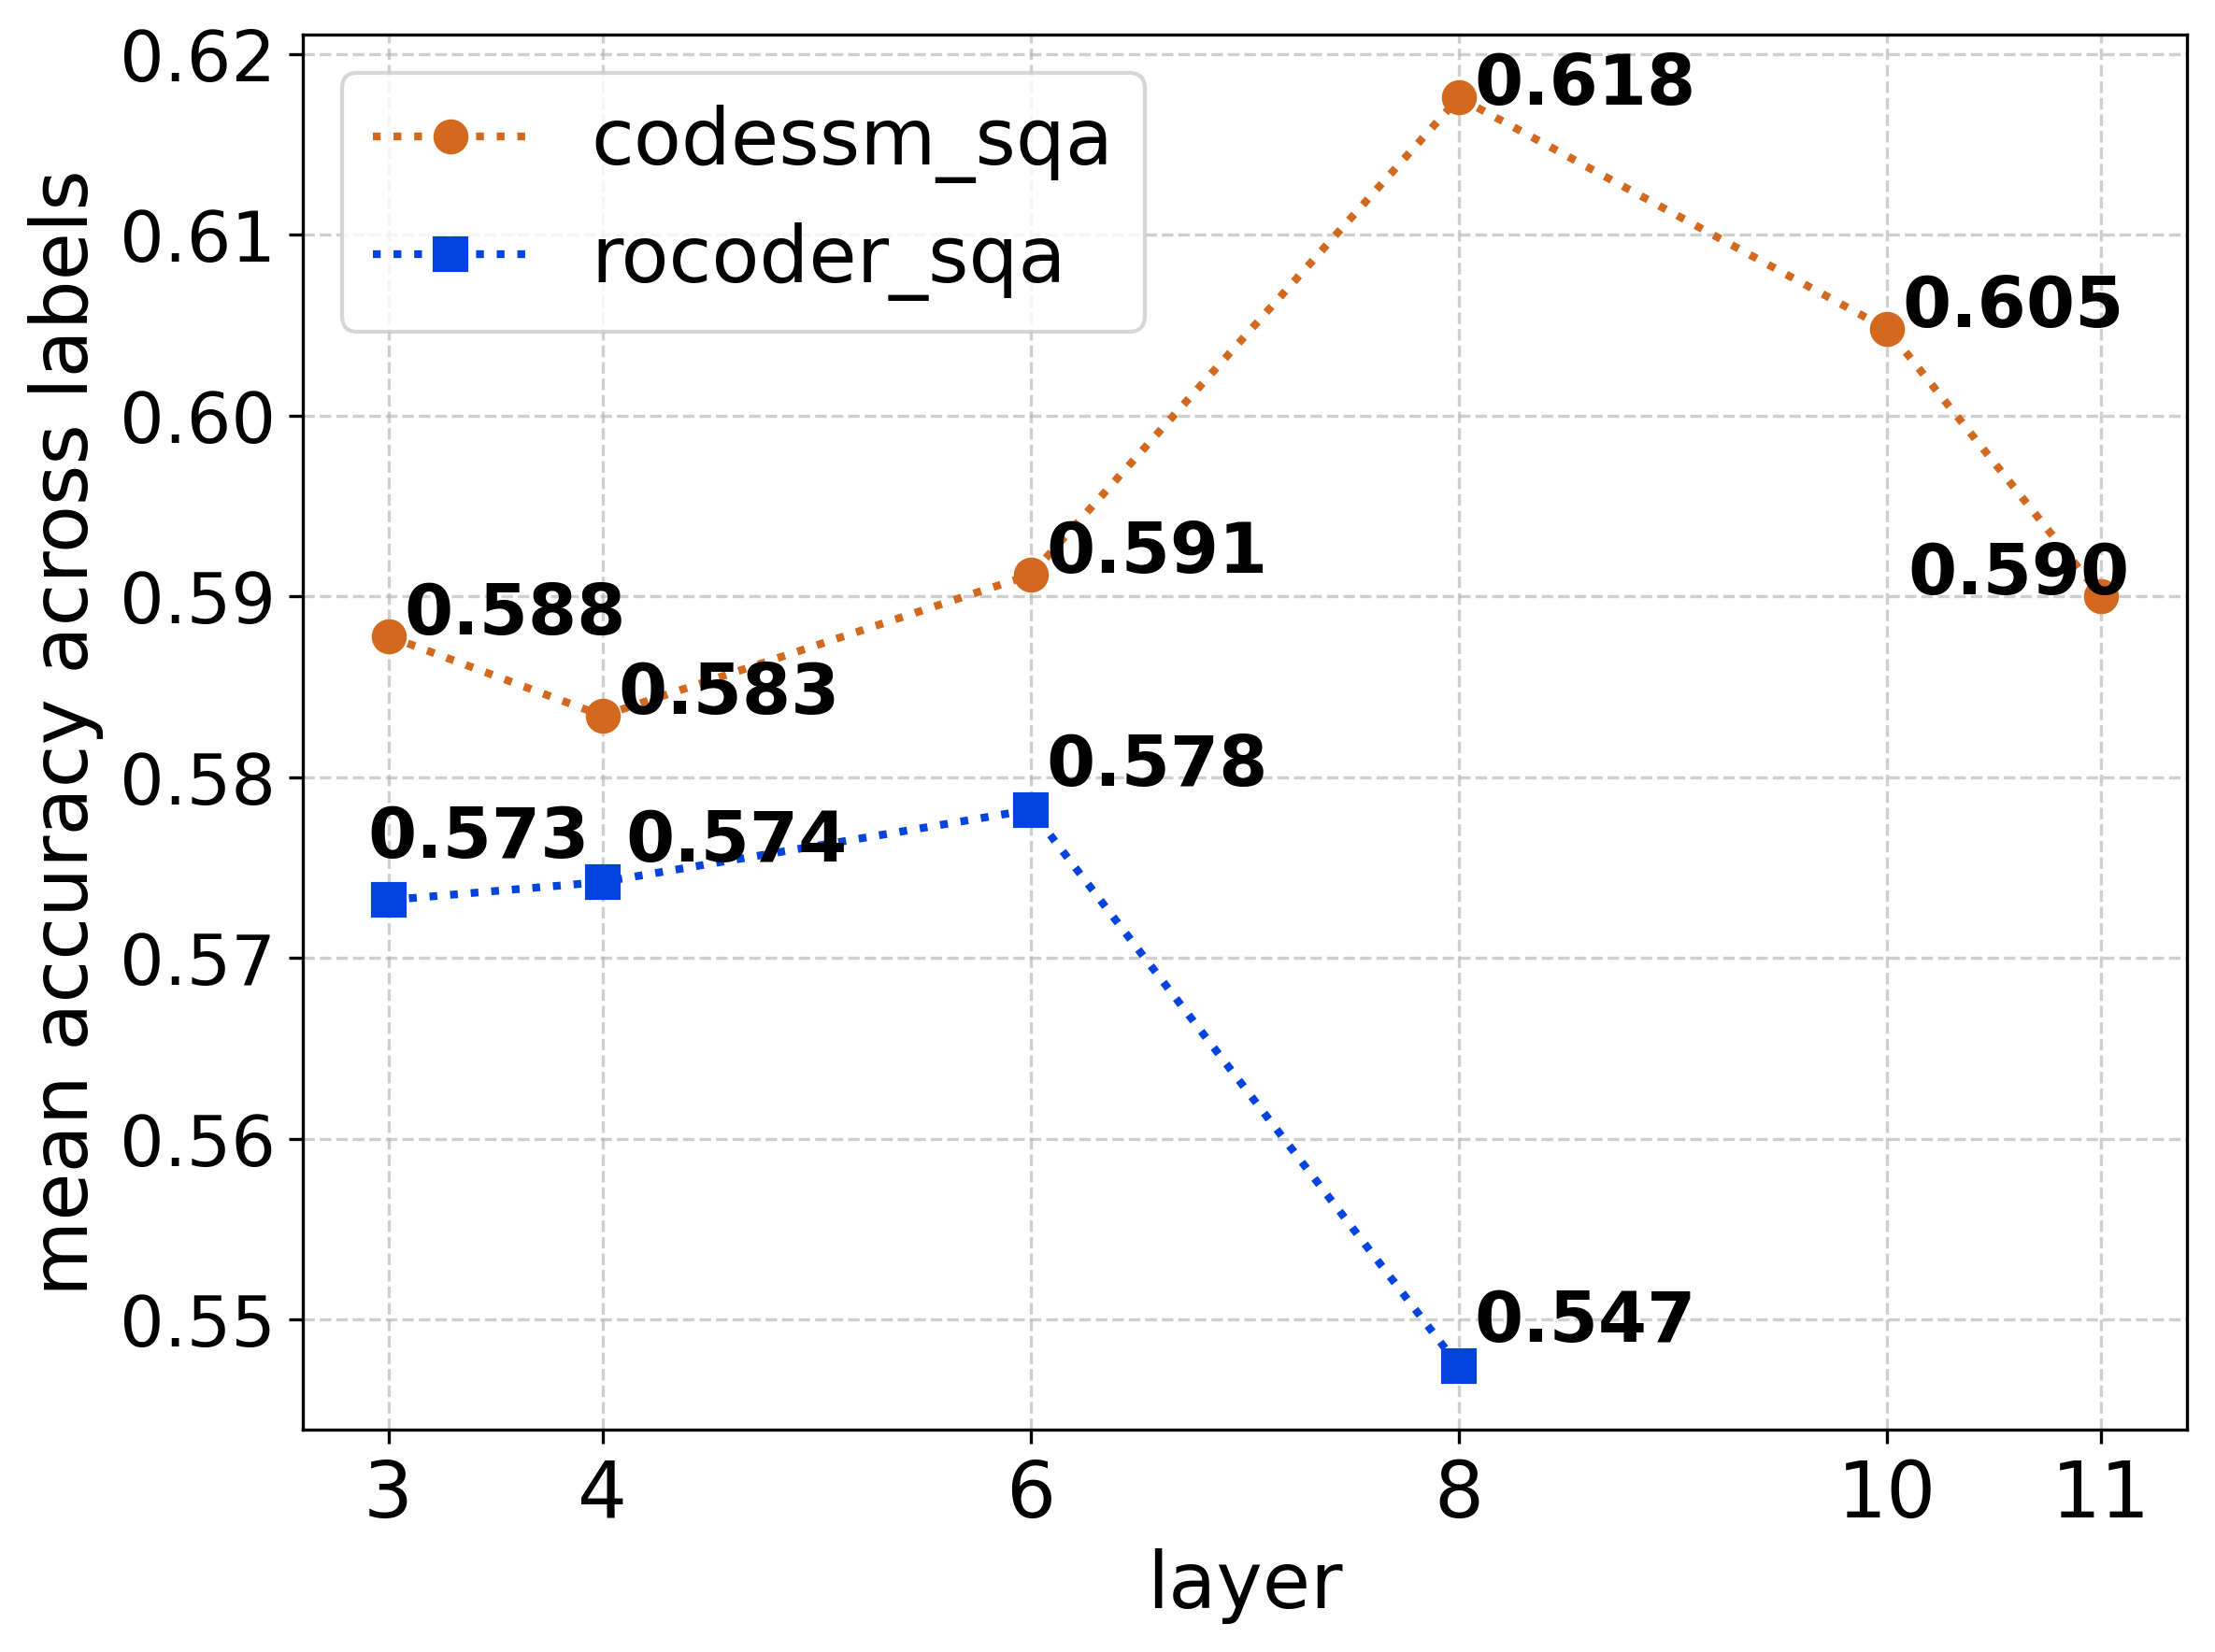

mean accuracy of codessm_sqa at layer 3 on siblings task : 0.817
mean accuracy of codessm_sqa at layer 4 on siblings task : 0.813
mean accuracy of codessm_sqa at layer 6 on siblings task : 0.824
mean accuracy of codessm_sqa at layer 8 on siblings task : 0.828
mean accuracy of codessm_sqa at layer 10 on siblings task : 0.827
mean accuracy of codessm_sqa at layer 11 on siblings task : 0.809
mean accuracy of rocoder_sqa at layer 3 on siblings task : 0.762
mean accuracy of rocoder_sqa at layer 4 on siblings task : 0.774
mean accuracy of rocoder_sqa at layer 6 on siblings task : 0.786
mean accuracy of rocoder_sqa at layer 8 on siblings task : 0.794
mean accuracy of rocoder_sqa at layer 10 on siblings task : 0.72
mean accuracy of rocoder_sqa at layer 11 on siblings task : 0.677


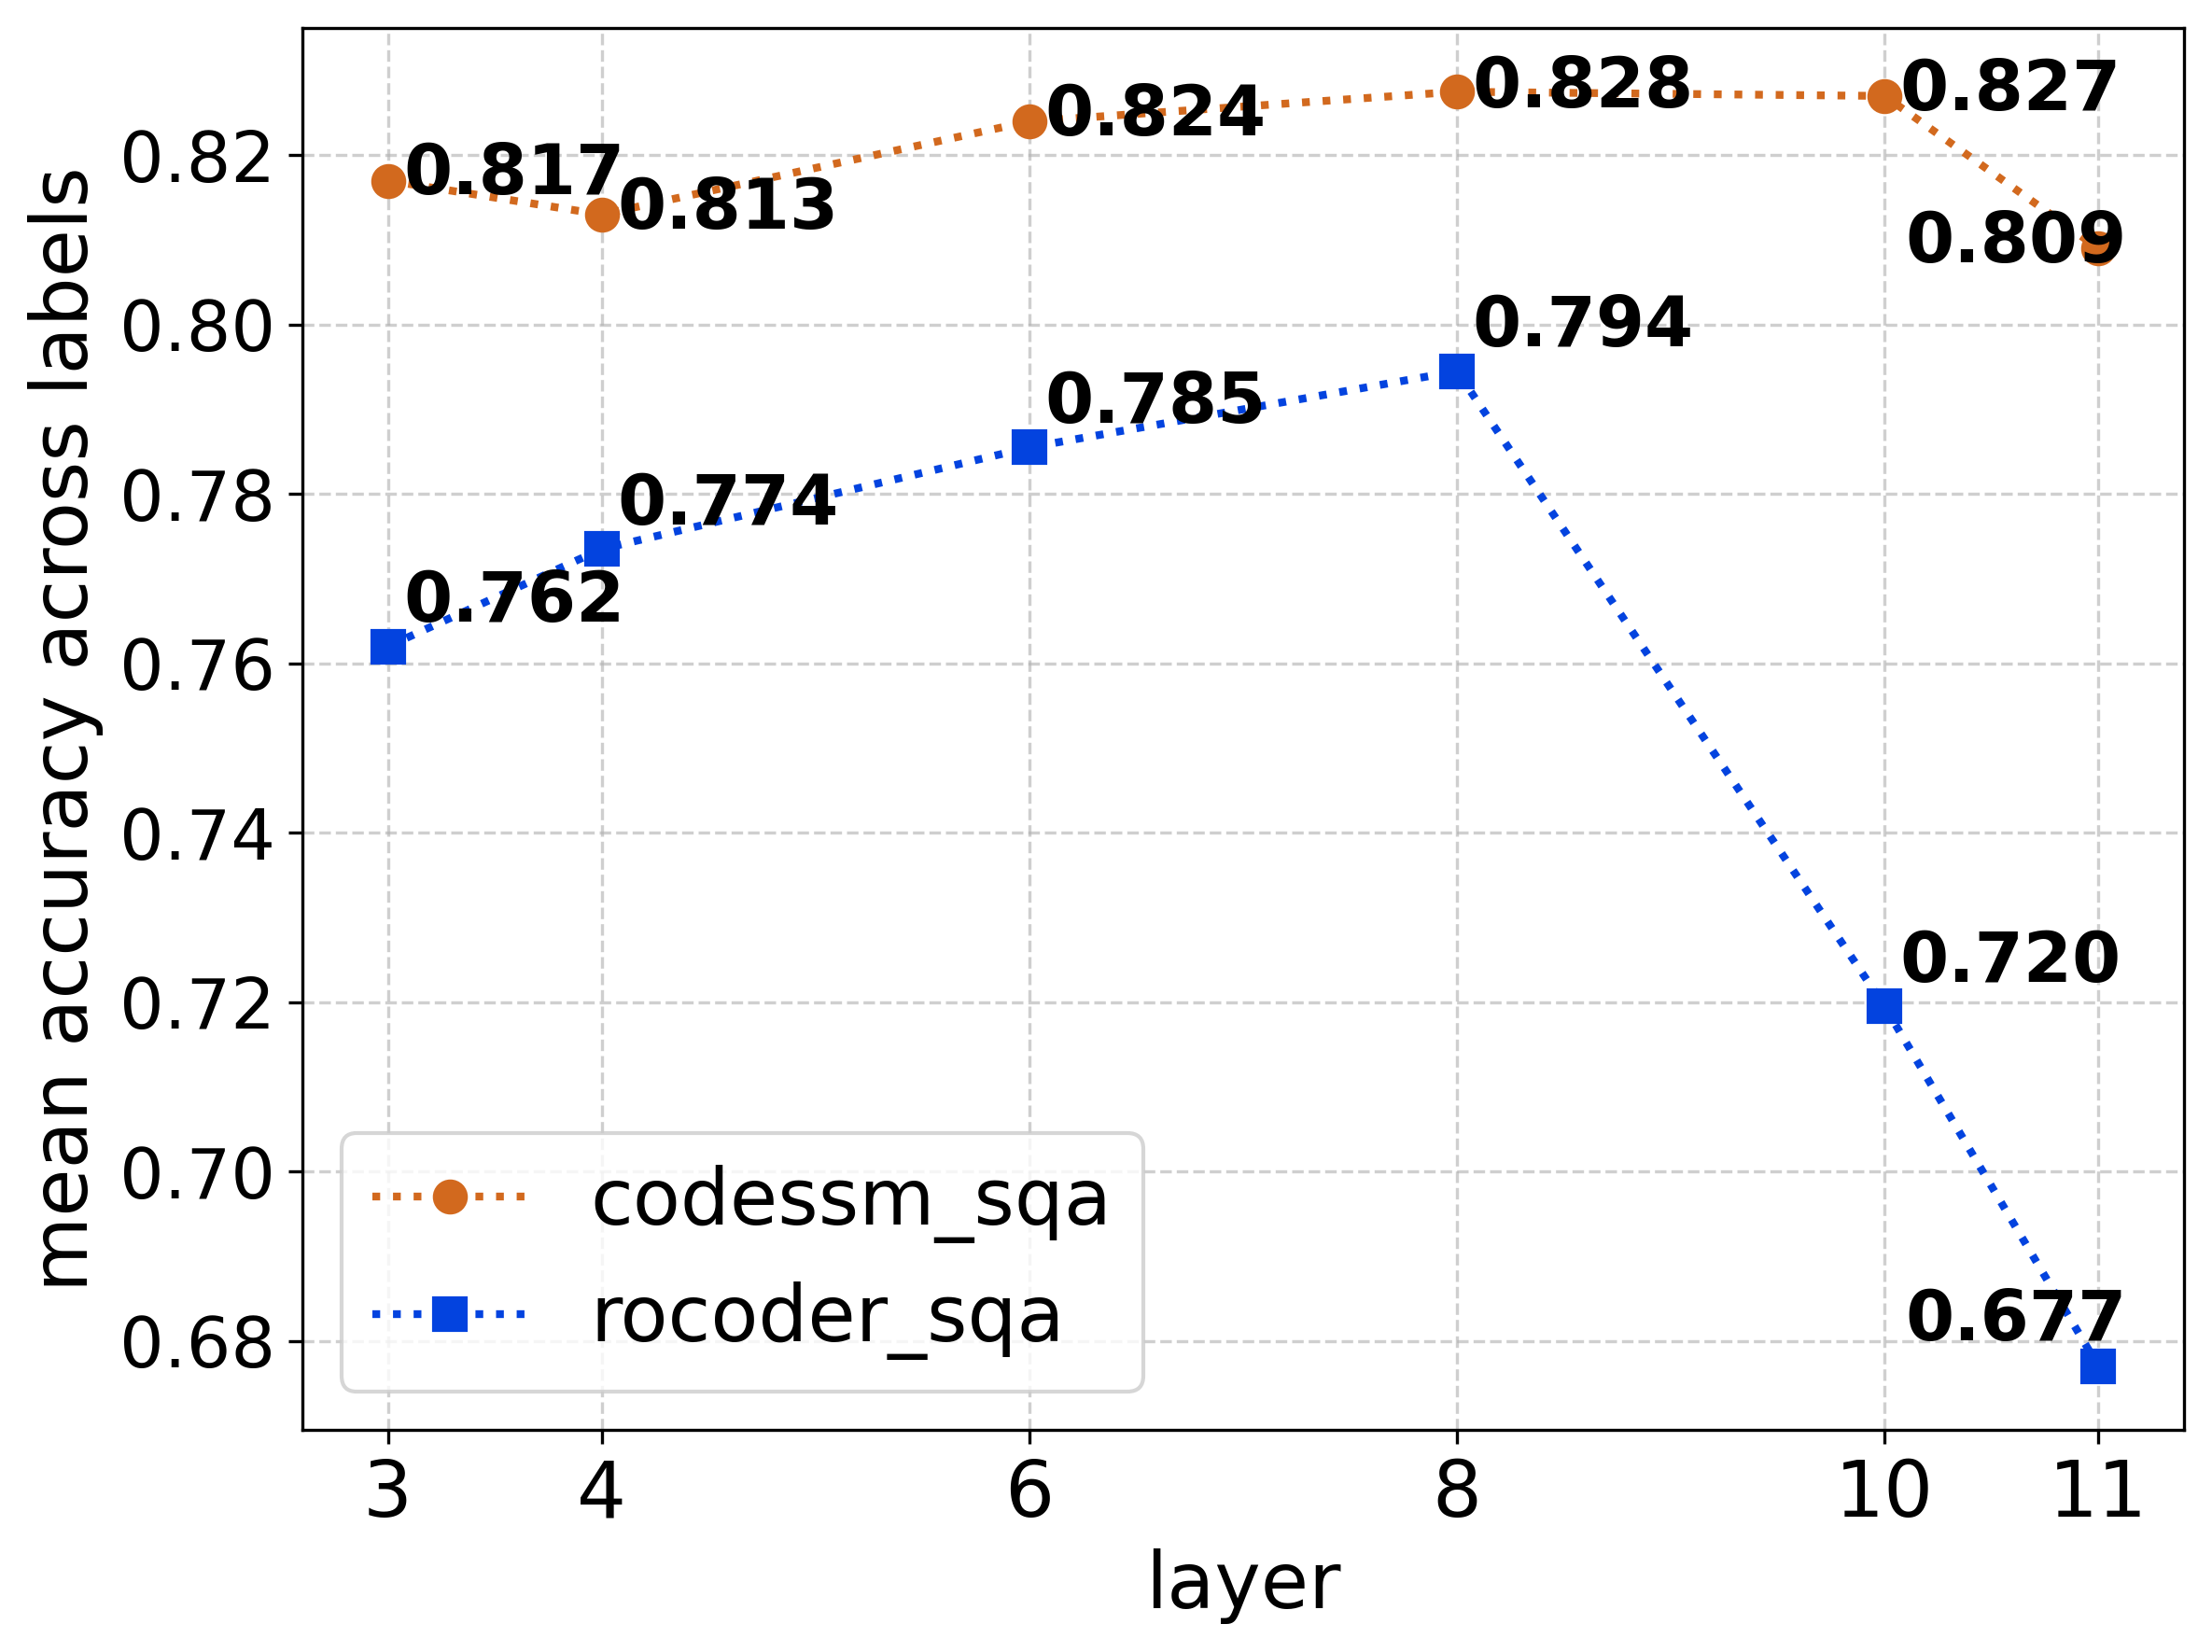

In [ ]:
models = ['codessm_sqa', 'rocoder_sqa']
models_name = 'codessm_sqa_vs_rocoder_sqa'
colors = ['#D2691E', '#0343DF']
layer_wise_mean_accuracy_all_tasks(models ,colors,tasks_and_labels,models_name)

### codessm_typeinf vs rocoder_typeinf

mean accuracy of codessm_typeinf at layer 3 on dfg task : 0.758
mean accuracy of codessm_typeinf at layer 4 on dfg task : 0.756
mean accuracy of codessm_typeinf at layer 6 on dfg task : 0.763
mean accuracy of codessm_typeinf at layer 8 on dfg task : 0.762
mean accuracy of codessm_typeinf at layer 10 on dfg task : 0.78
mean accuracy of codessm_typeinf at layer 11 on dfg task : 0.749
mean accuracy of rocoder_typeinf at layer 3 on dfg task : 0.75
mean accuracy of rocoder_typeinf at layer 4 on dfg task : 0.753
mean accuracy of rocoder_typeinf at layer 6 on dfg task : 0.795
mean accuracy of rocoder_typeinf at layer 8 on dfg task : 0.81
mean accuracy of rocoder_typeinf at layer 10 on dfg task : 0.769
mean accuracy of rocoder_typeinf at layer 11 on dfg task : 0.748


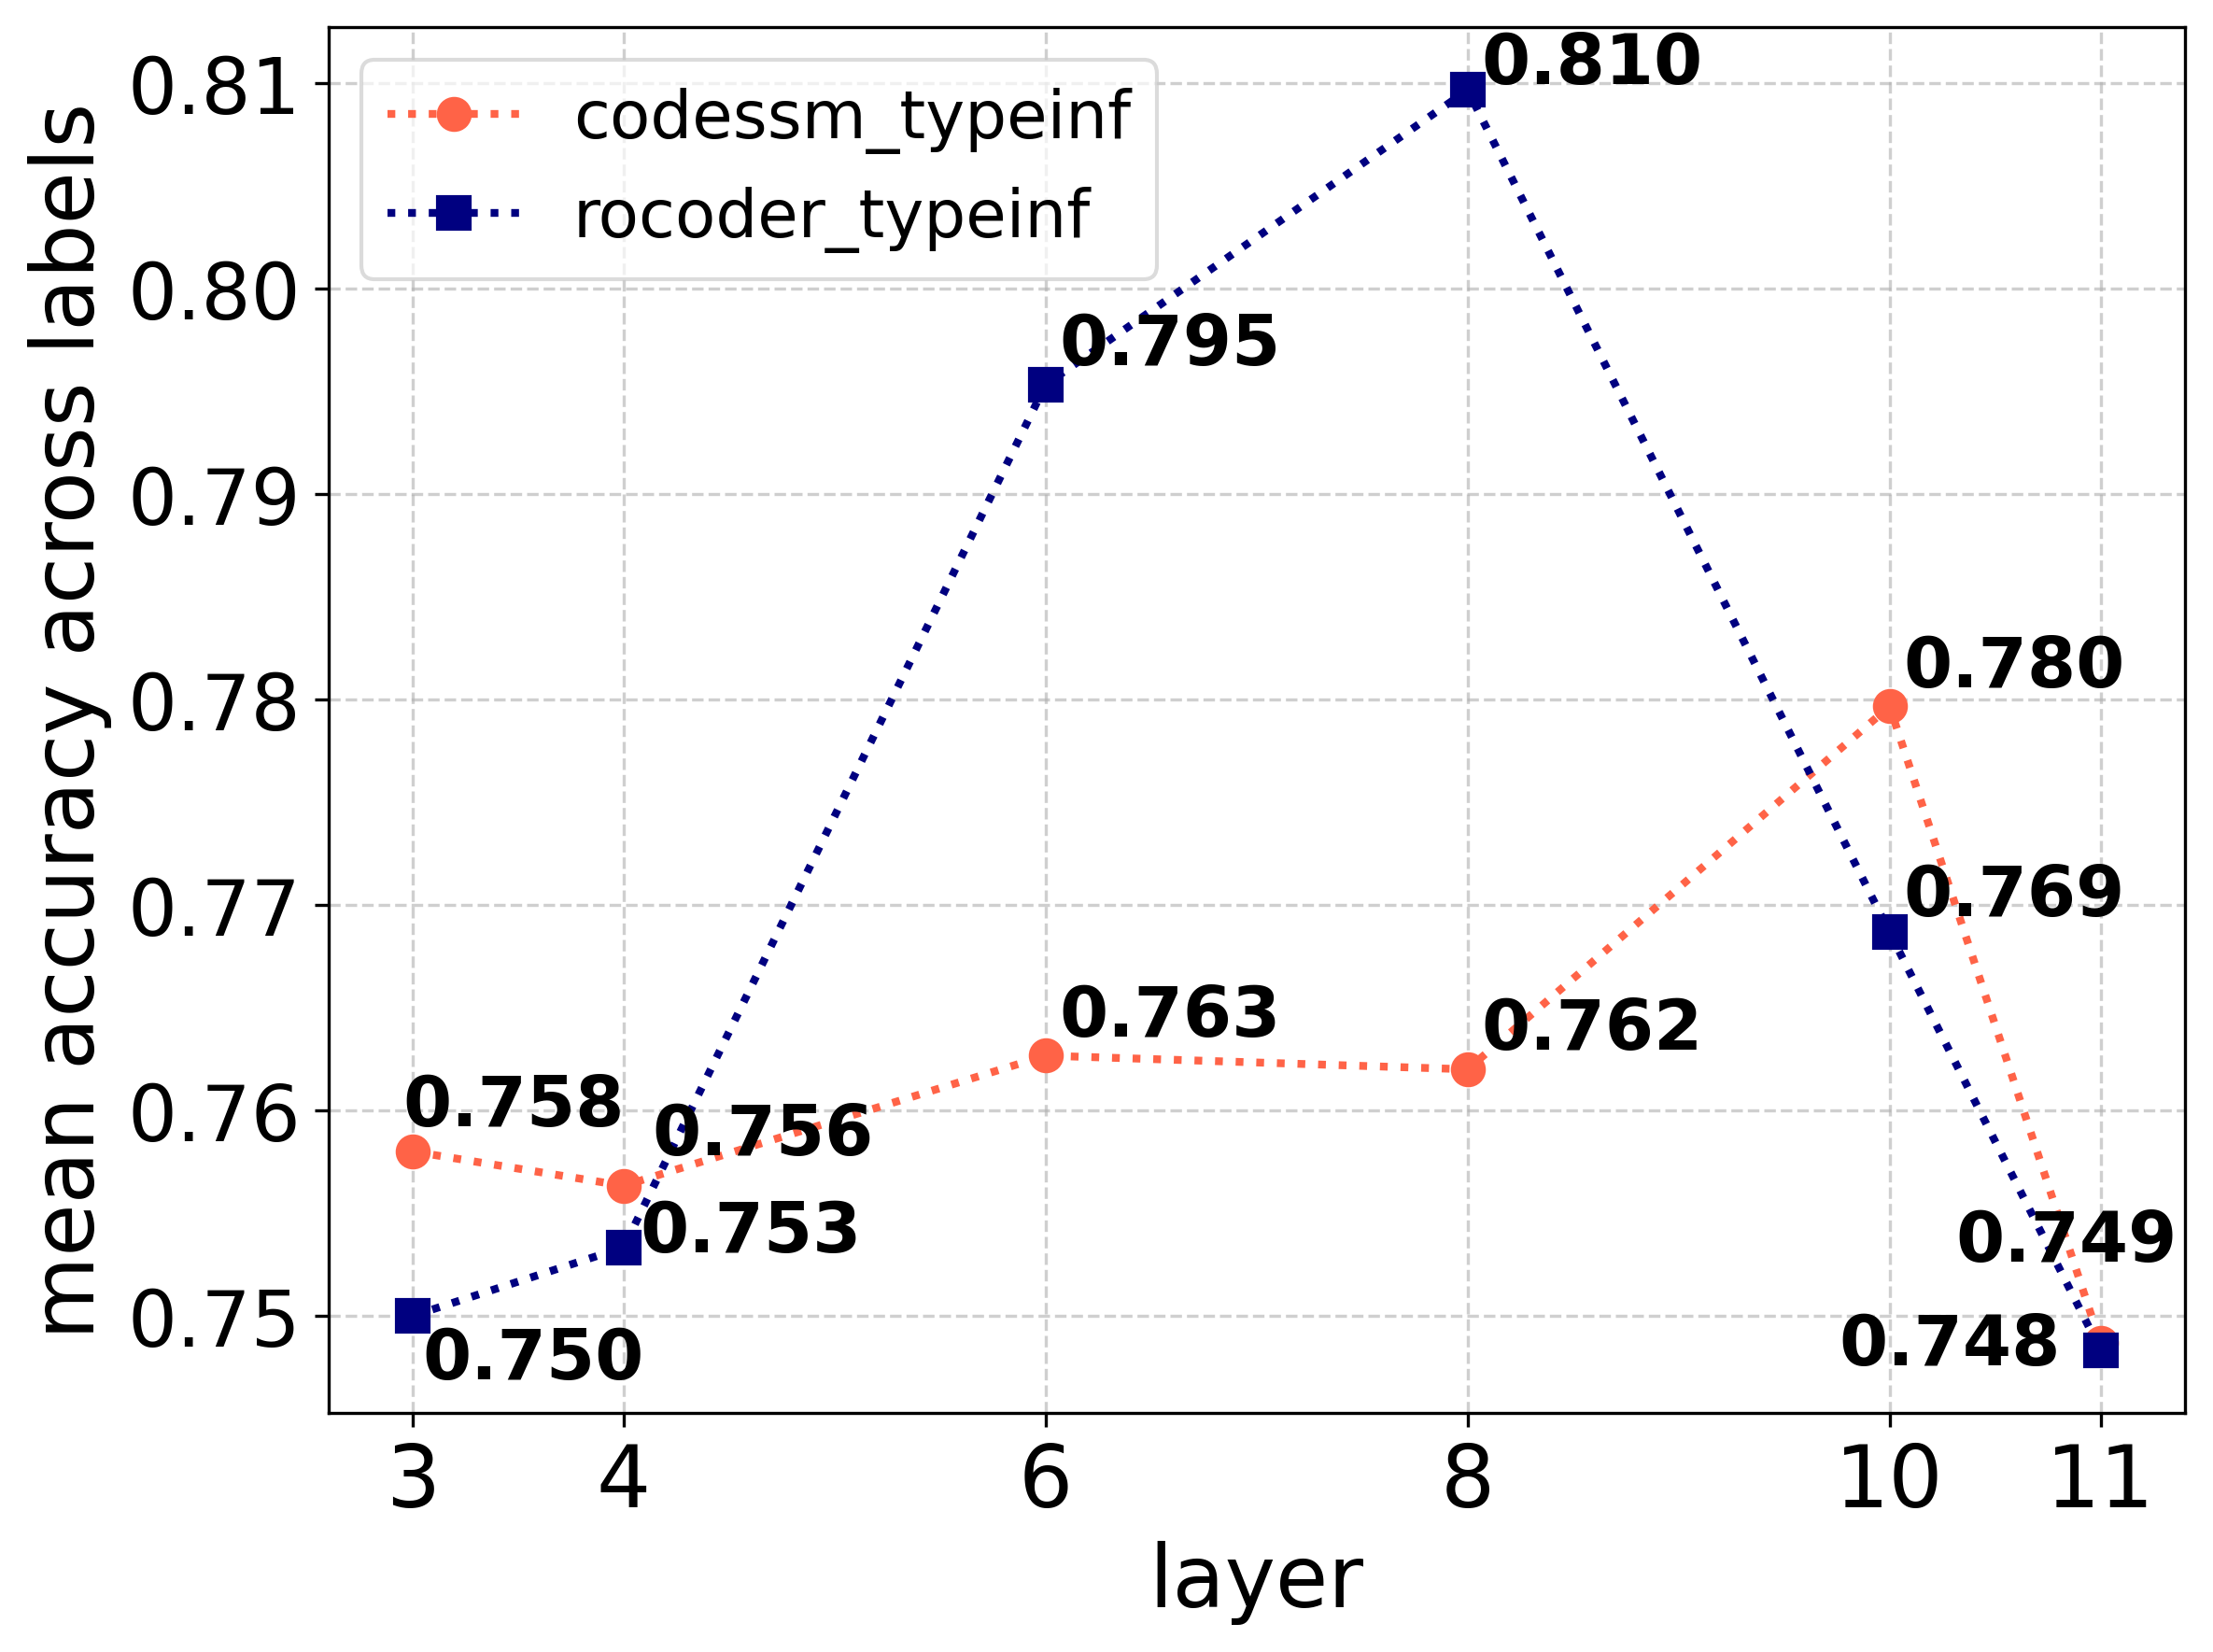

mean accuracy of codessm_typeinf at layer 3 on distance task : 0.55
mean accuracy of codessm_typeinf at layer 4 on distance task : 0.549
mean accuracy of codessm_typeinf at layer 6 on distance task : 0.548
mean accuracy of codessm_typeinf at layer 8 on distance task : 0.548
mean accuracy of codessm_typeinf at layer 10 on distance task : 0.537
mean accuracy of codessm_typeinf at layer 11 on distance task : 0.53
mean accuracy of rocoder_typeinf at layer 3 on distance task : 0.602
mean accuracy of rocoder_typeinf at layer 4 on distance task : 0.612
mean accuracy of rocoder_typeinf at layer 6 on distance task : 0.626
mean accuracy of rocoder_typeinf at layer 8 on distance task : 0.625
mean accuracy of rocoder_typeinf at layer 10 on distance task : 0.534
mean accuracy of rocoder_typeinf at layer 11 on distance task : 0.516


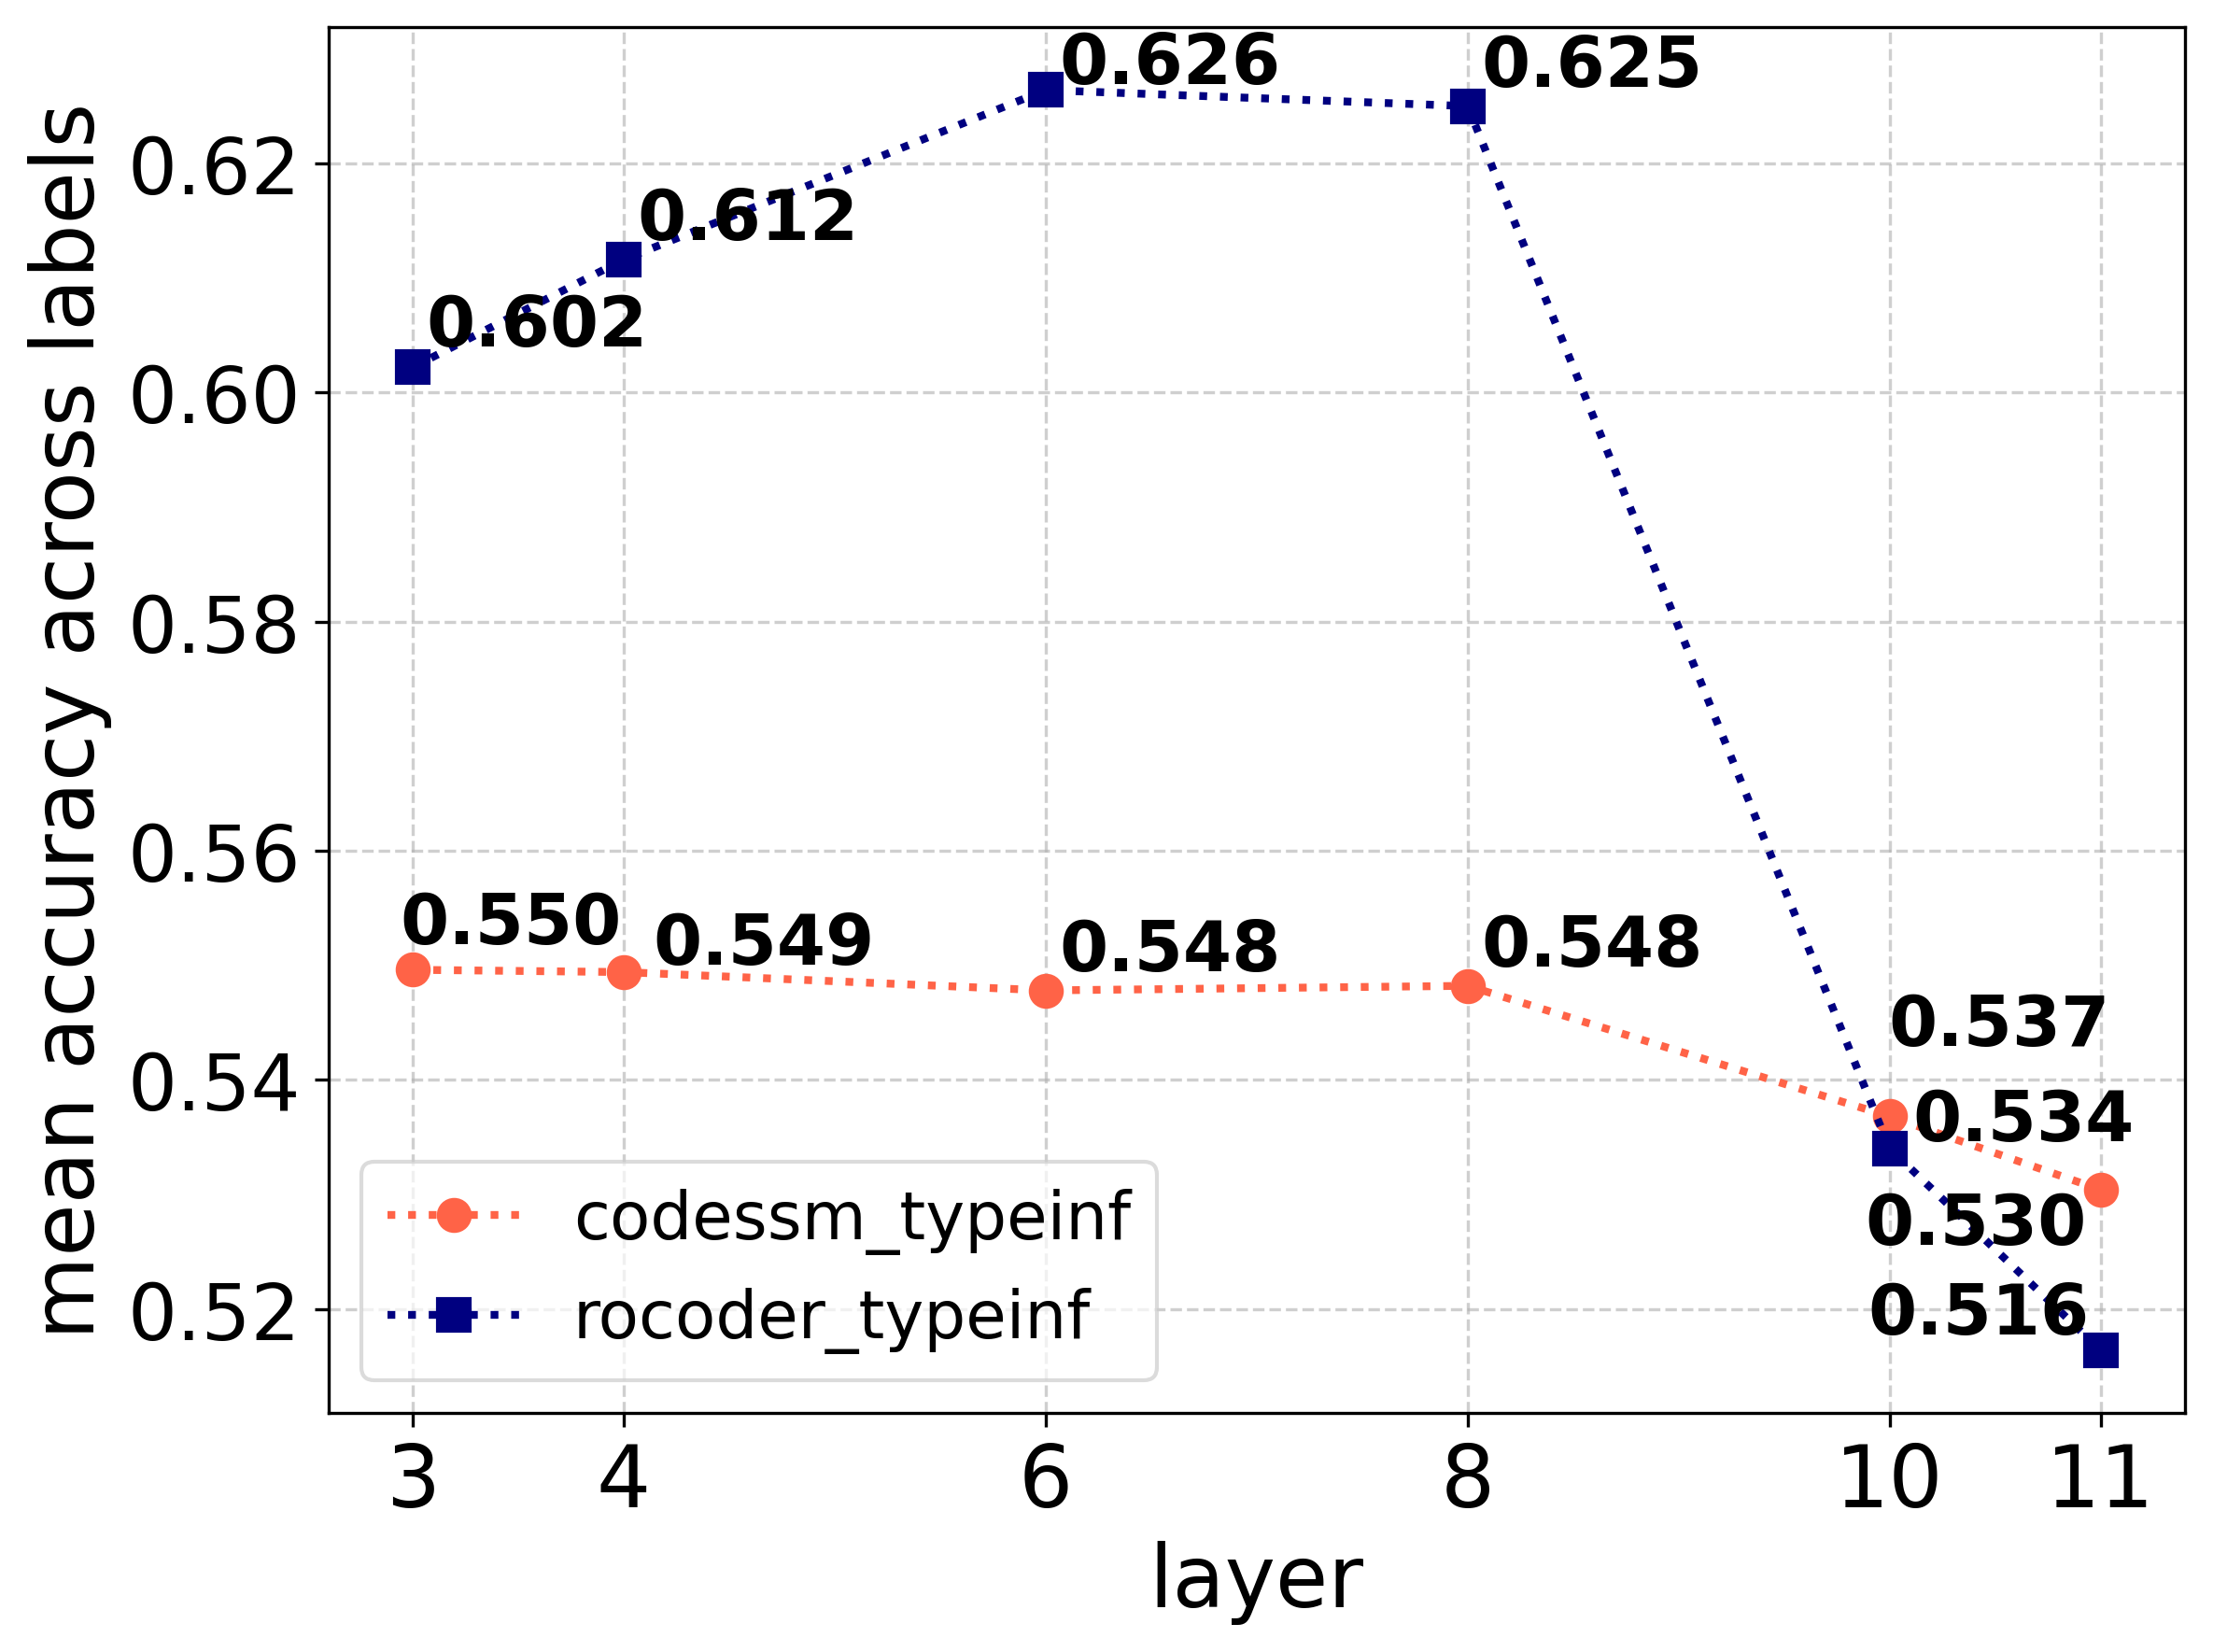

mean accuracy of codessm_typeinf at layer 3 on siblings task : 0.756
mean accuracy of codessm_typeinf at layer 4 on siblings task : 0.764
mean accuracy of codessm_typeinf at layer 6 on siblings task : 0.776
mean accuracy of codessm_typeinf at layer 8 on siblings task : 0.788
mean accuracy of codessm_typeinf at layer 10 on siblings task : 0.76
mean accuracy of codessm_typeinf at layer 11 on siblings task : 0.723
mean accuracy of rocoder_typeinf at layer 3 on siblings task : 0.792
mean accuracy of rocoder_typeinf at layer 4 on siblings task : 0.806
mean accuracy of rocoder_typeinf at layer 6 on siblings task : 0.836
mean accuracy of rocoder_typeinf at layer 8 on siblings task : 0.8
mean accuracy of rocoder_typeinf at layer 10 on siblings task : 0.679
mean accuracy of rocoder_typeinf at layer 11 on siblings task : 0.634


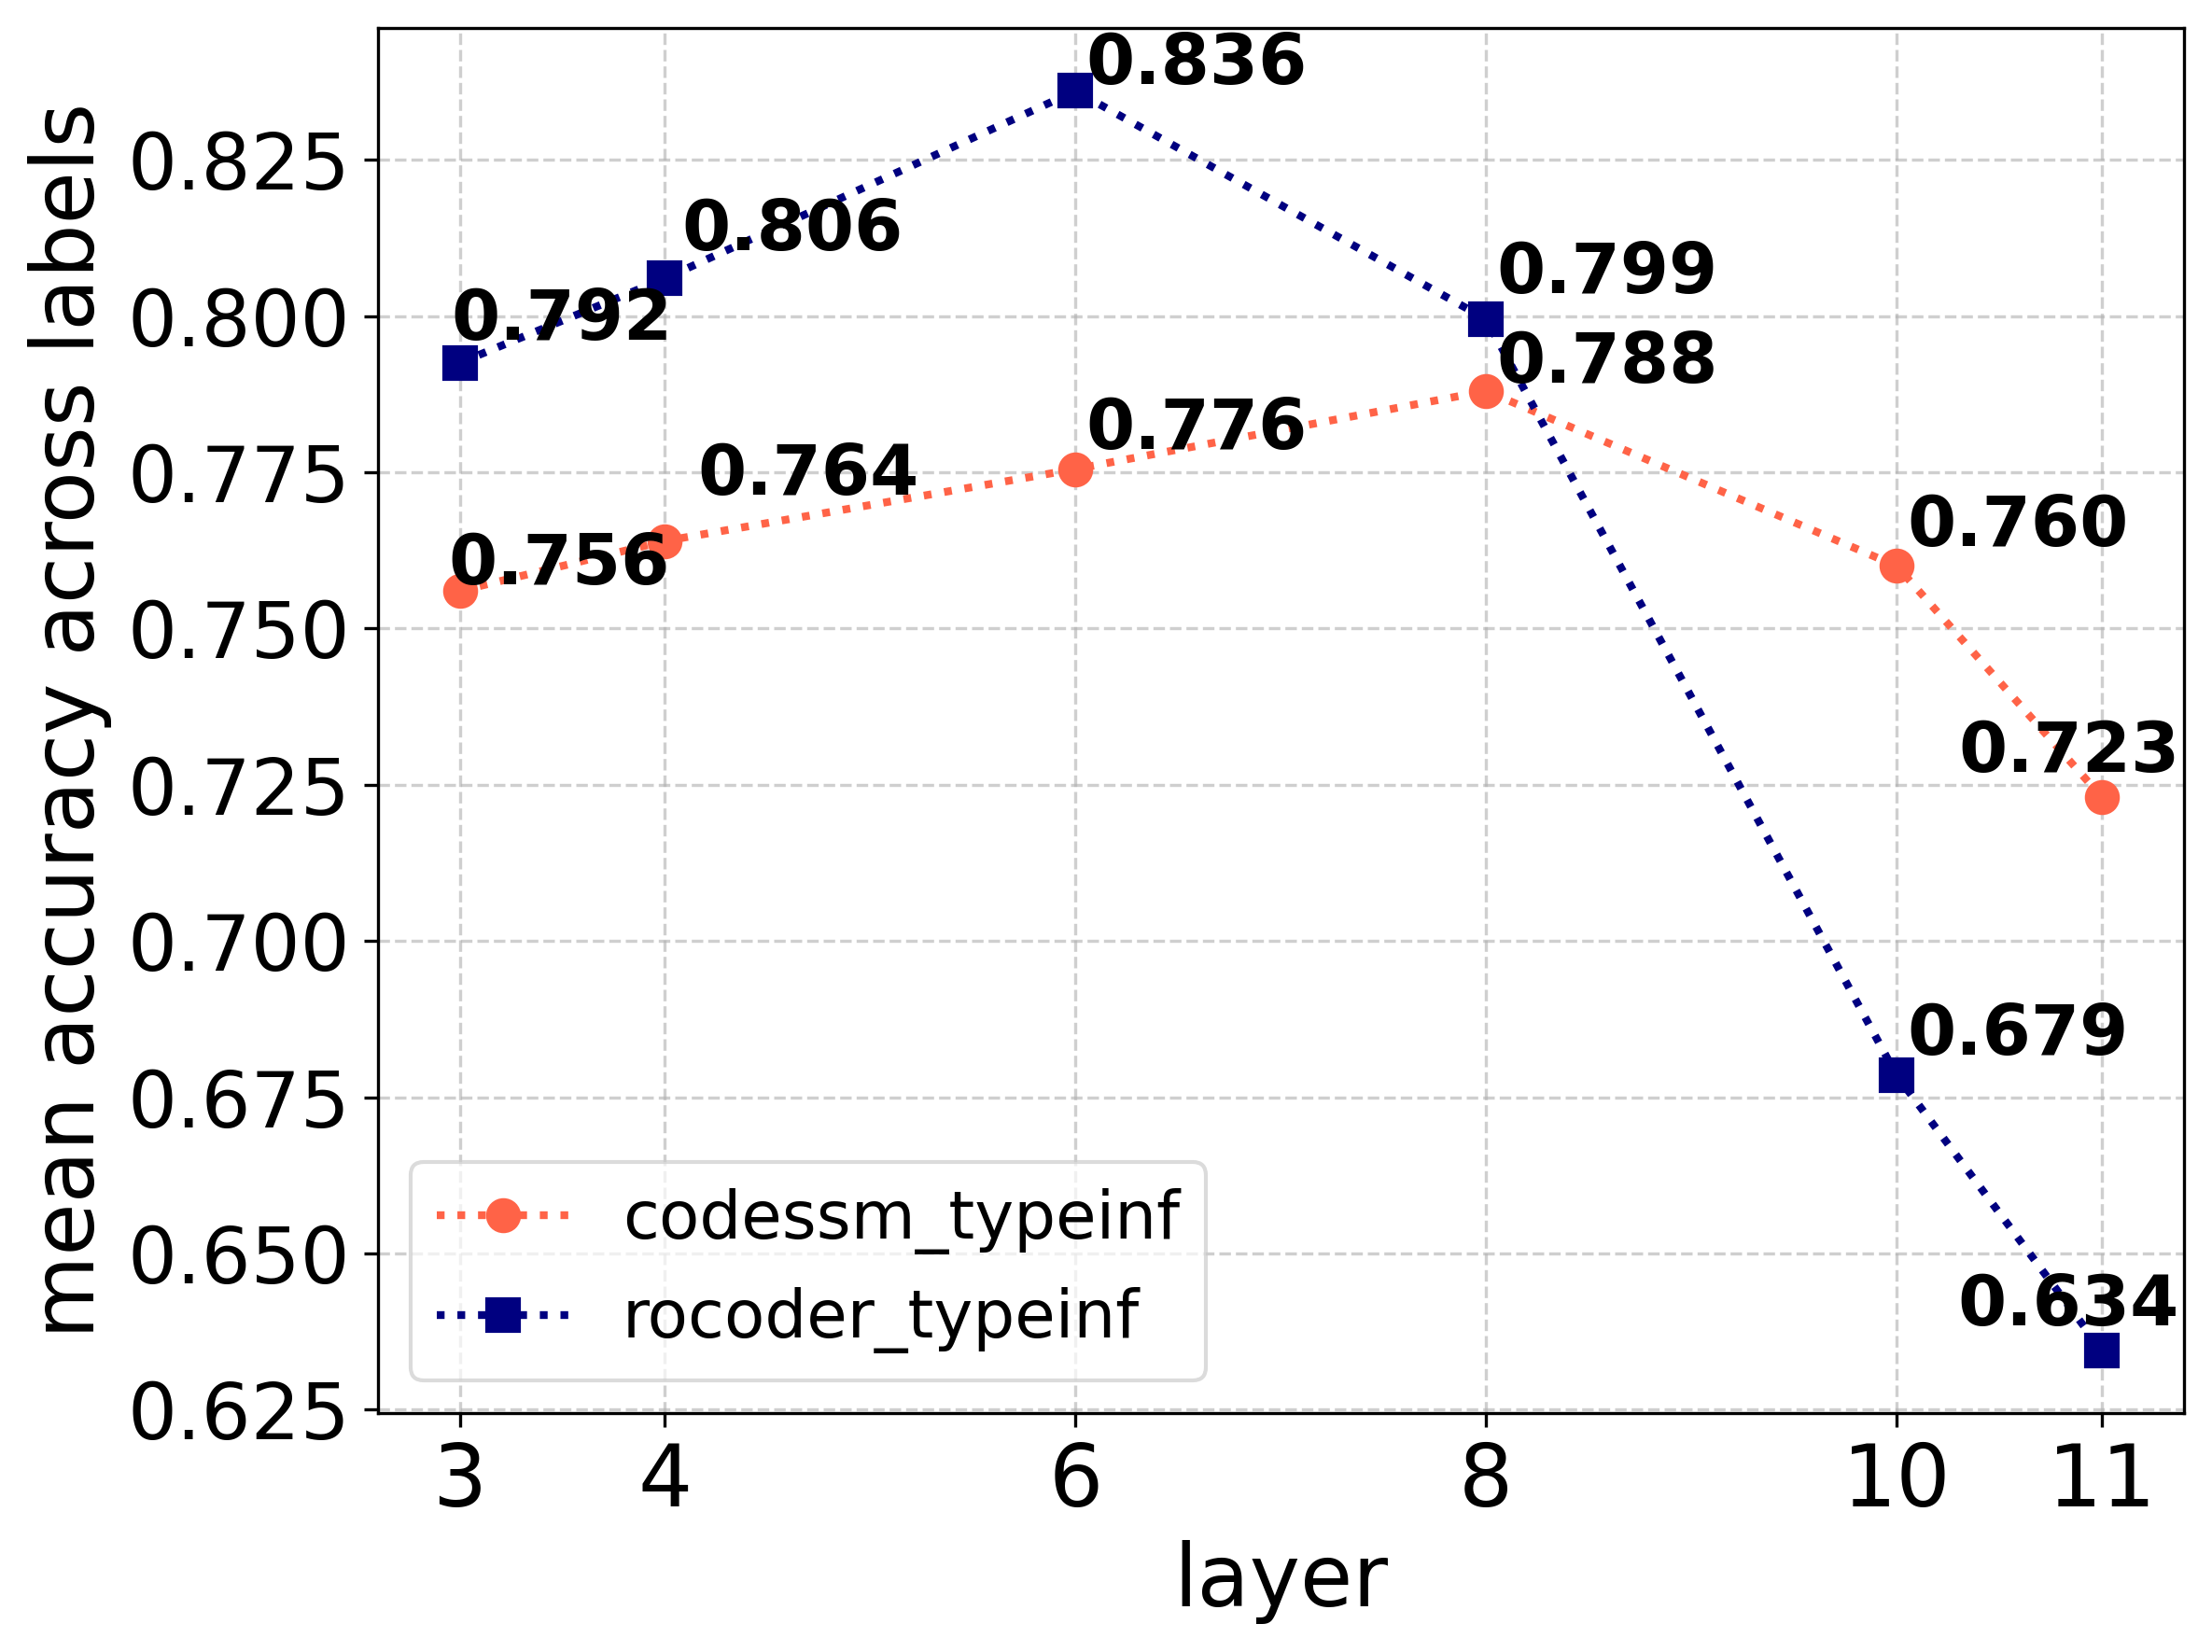

In [ ]:
models = ['codessm_typeinf', 'rocoder_typeinf']
models_name = 'codessm_typeinf_vs_rocoder_typeinf'
colors = ['#FF6347', '#000080']
layer_wise_mean_accuracy_all_tasks(models ,colors, tasks_and_labels,models_name)

### pre-trained codessm vs fine-tuned

mean accuracy of codeSSM at layer 3 on dfg task : 0.802
mean accuracy of codeSSM at layer 4 on dfg task : 0.788
mean accuracy of codeSSM at layer 6 on dfg task : 0.806
mean accuracy of codeSSM at layer 8 on dfg task : 0.824
mean accuracy of codeSSM at layer 10 on dfg task : 0.82
mean accuracy of codeSSM at layer 11 on dfg task : 0.82
mean accuracy of codessm_sqa at layer 3 on dfg task : 0.78
mean accuracy of codessm_sqa at layer 4 on dfg task : 0.777
mean accuracy of codessm_sqa at layer 6 on dfg task : 0.782
mean accuracy of codessm_sqa at layer 8 on dfg task : 0.792
mean accuracy of codessm_sqa at layer 10 on dfg task : 0.807
mean accuracy of codessm_sqa at layer 11 on dfg task : 0.799
mean accuracy of codessm_typeinf at layer 3 on dfg task : 0.758
mean accuracy of codessm_typeinf at layer 4 on dfg task : 0.756
mean accuracy of codessm_typeinf at layer 6 on dfg task : 0.763
mean accuracy of codessm_typeinf at layer 8 on dfg task : 0.762
mean accuracy of codessm_typeinf at layer 10 on

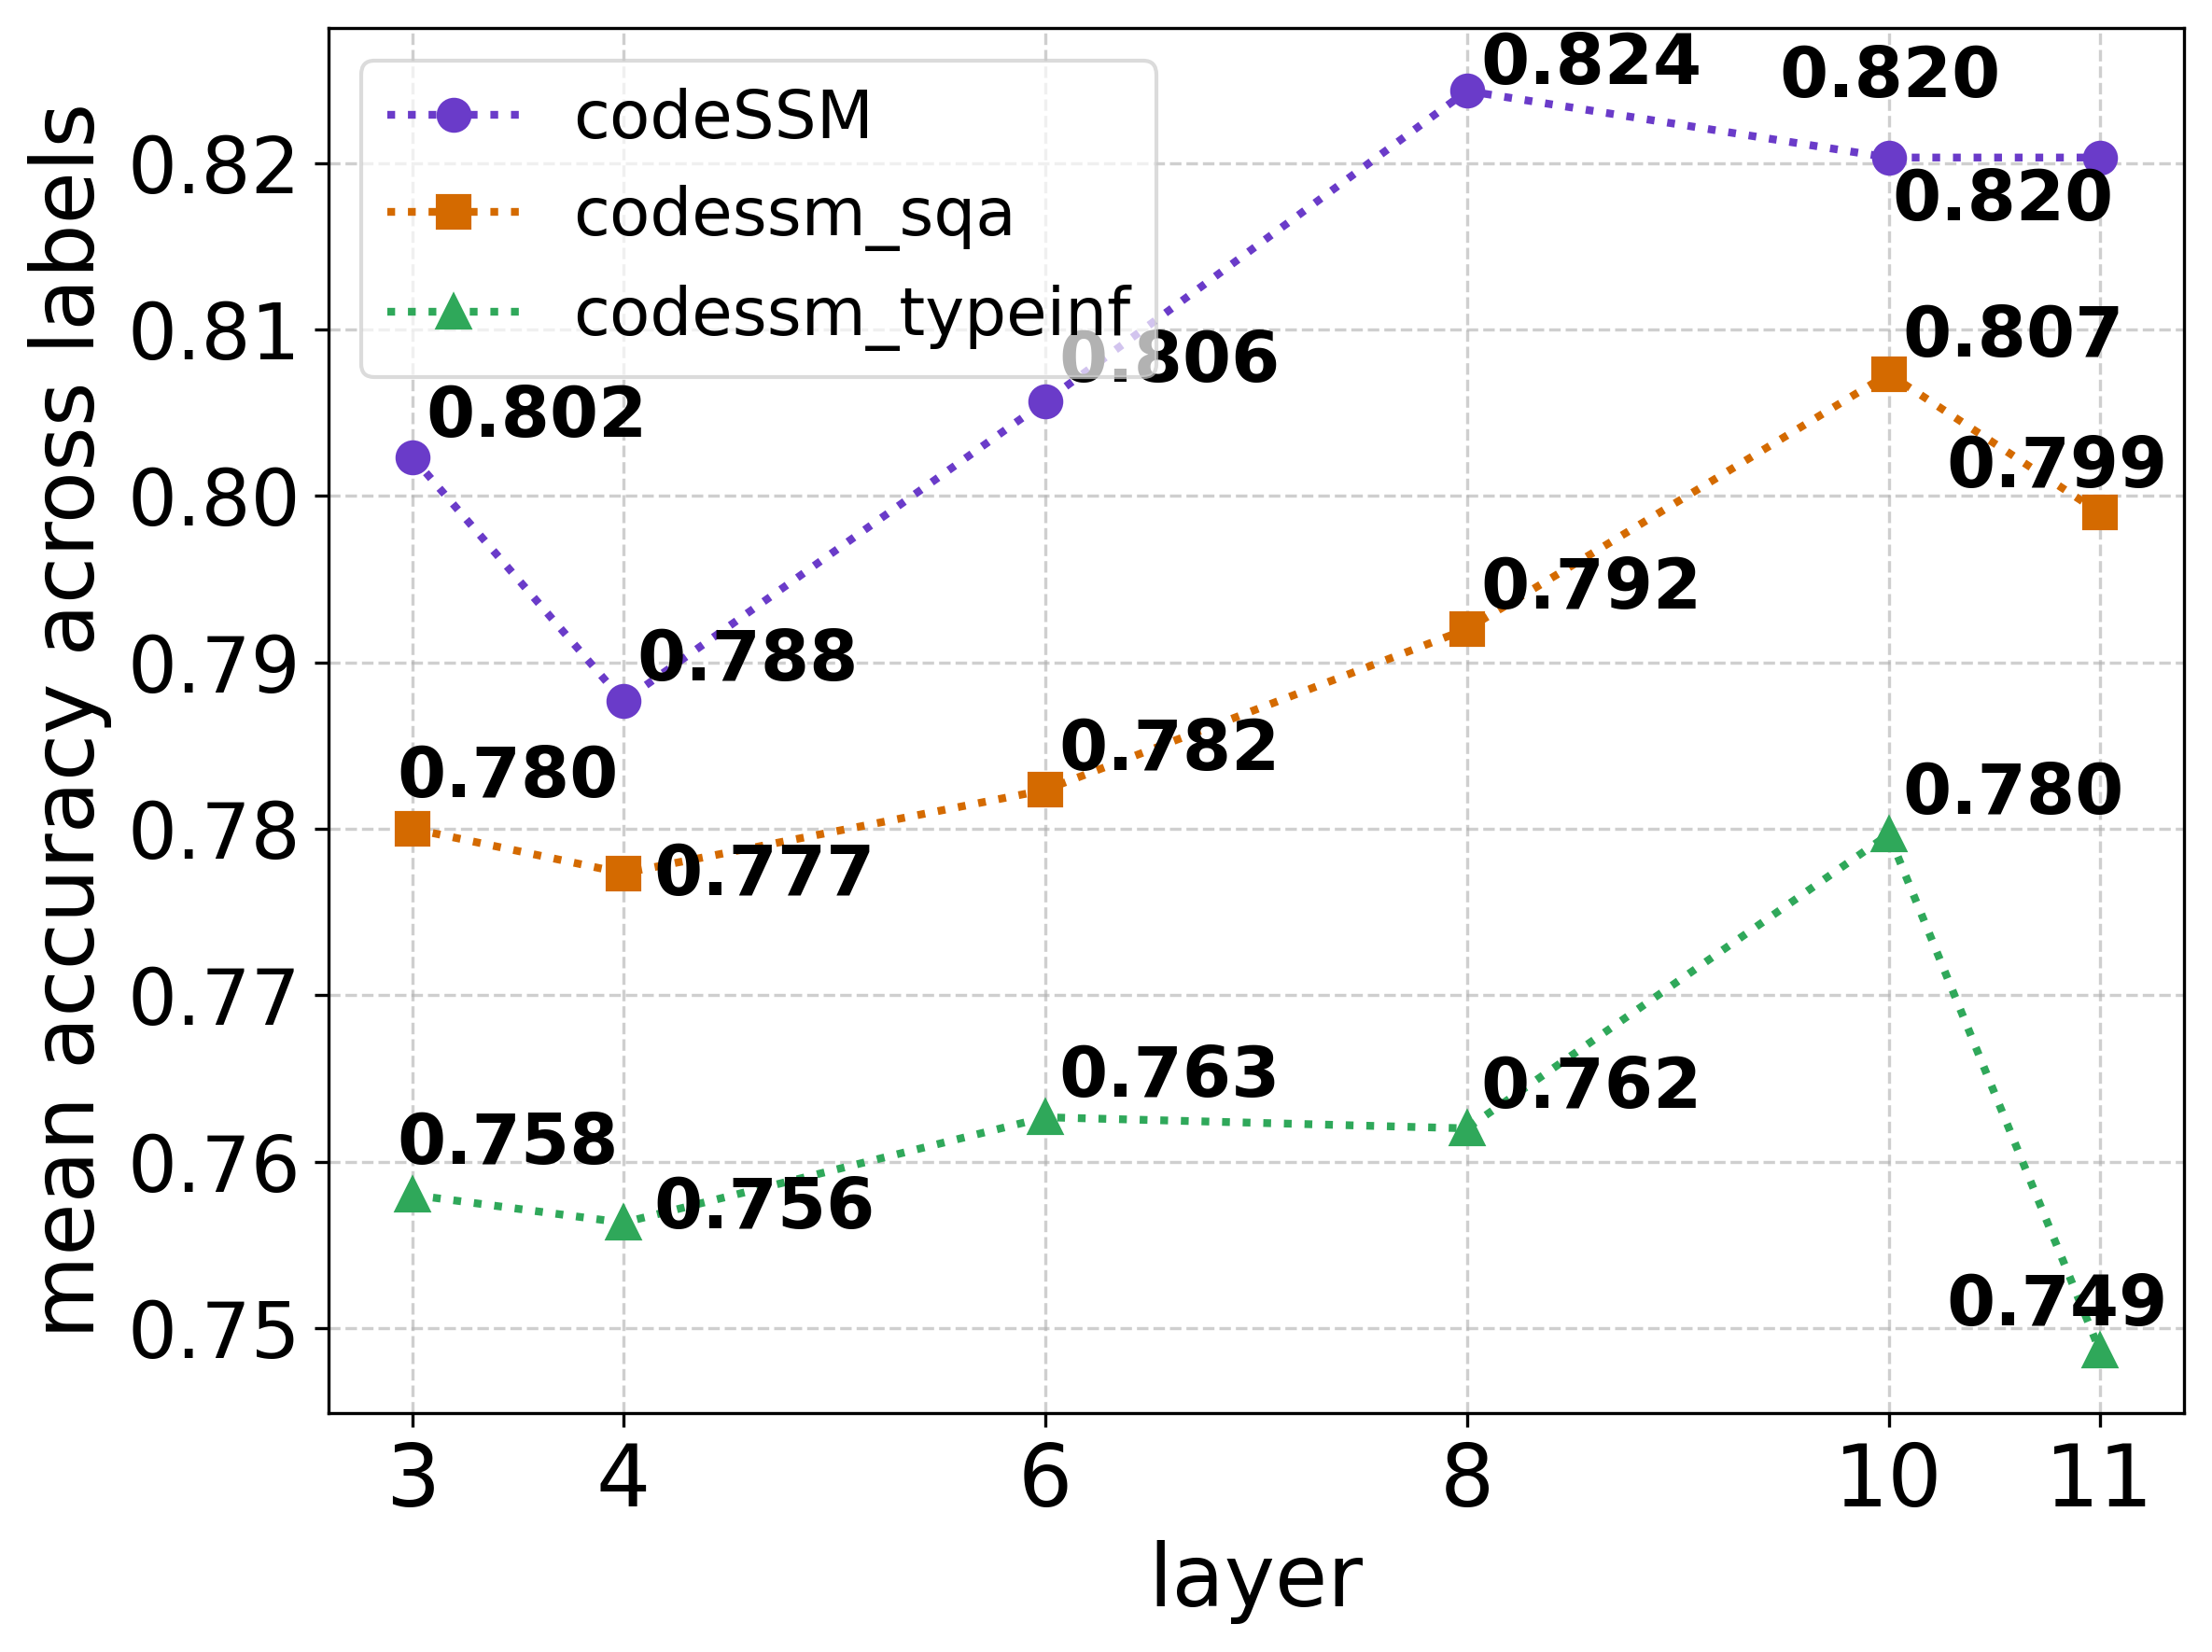

mean accuracy of codeSSM at layer 3 on distance task : 0.59
mean accuracy of codeSSM at layer 4 on distance task : 0.603
mean accuracy of codeSSM at layer 6 on distance task : 0.621
mean accuracy of codeSSM at layer 8 on distance task : 0.623
mean accuracy of codeSSM at layer 10 on distance task : 0.632
mean accuracy of codeSSM at layer 11 on distance task : 0.626
mean accuracy of codessm_sqa at layer 3 on distance task : 0.588
mean accuracy of codessm_sqa at layer 4 on distance task : 0.583
mean accuracy of codessm_sqa at layer 6 on distance task : 0.591
mean accuracy of codessm_sqa at layer 8 on distance task : 0.618
mean accuracy of codessm_sqa at layer 10 on distance task : 0.605
mean accuracy of codessm_sqa at layer 11 on distance task : 0.59
mean accuracy of codessm_typeinf at layer 3 on distance task : 0.55
mean accuracy of codessm_typeinf at layer 4 on distance task : 0.549
mean accuracy of codessm_typeinf at layer 6 on distance task : 0.548
mean accuracy of codessm_typeinf at 

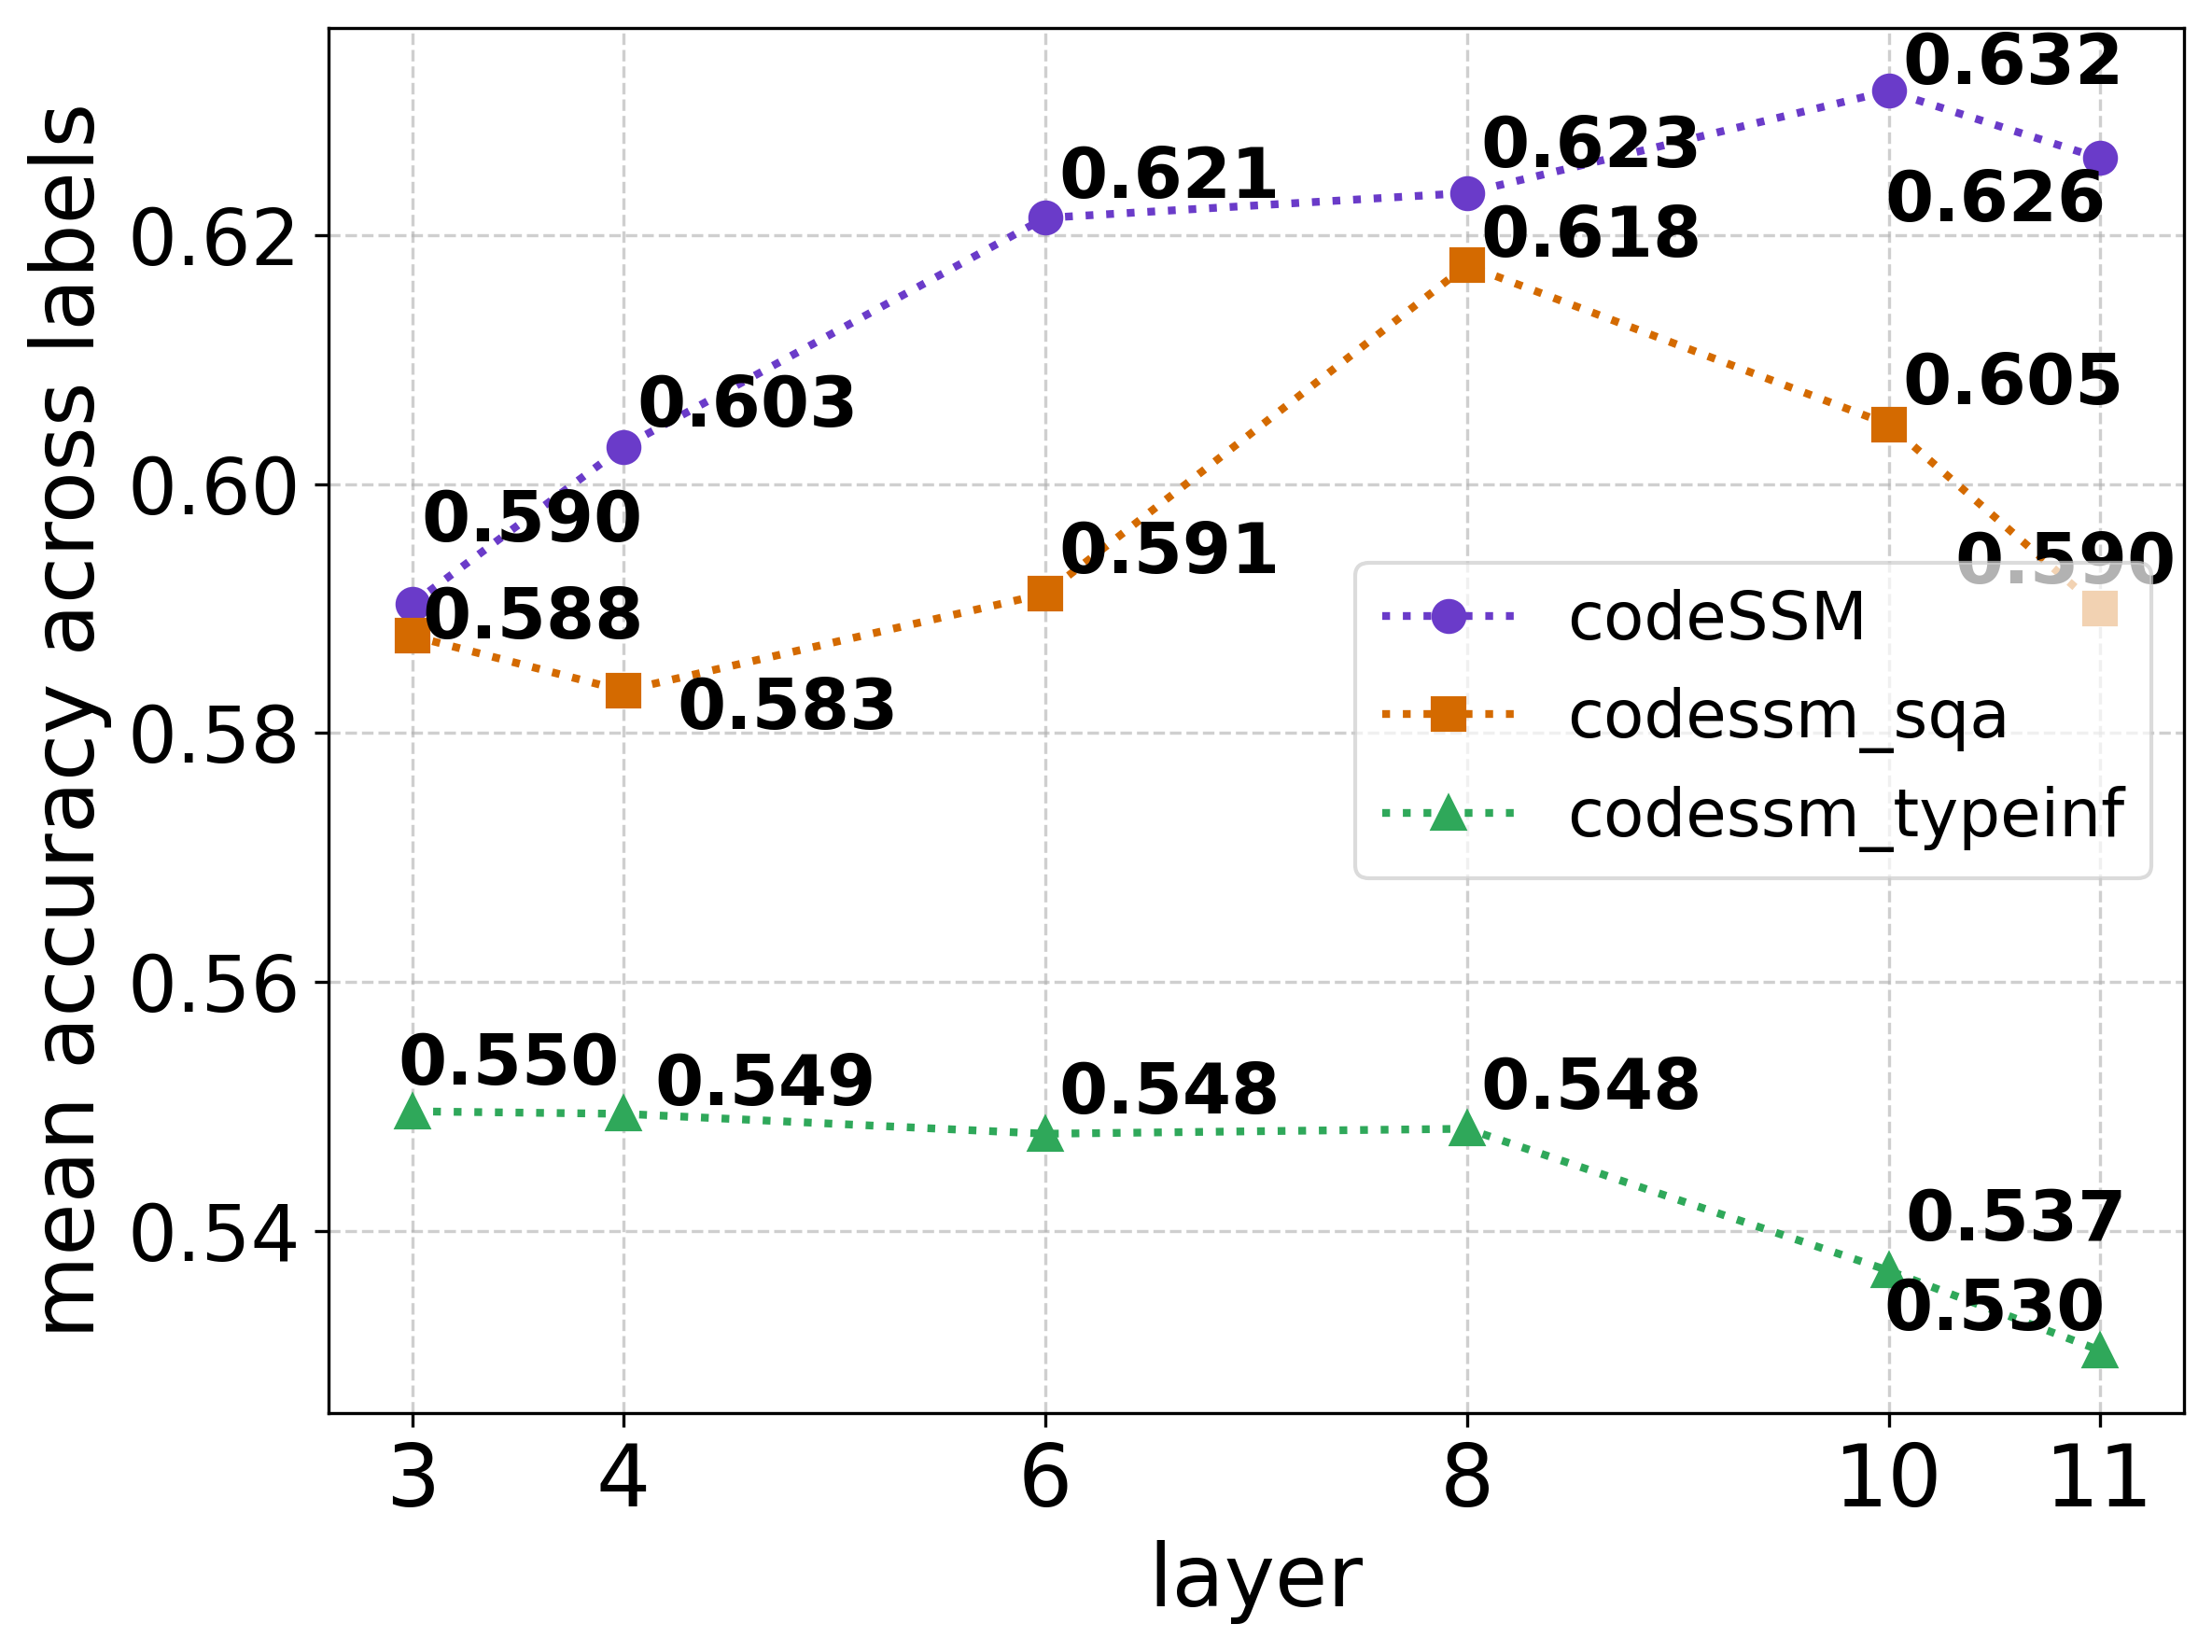

mean accuracy of codeSSM at layer 3 on siblings task : 0.817
mean accuracy of codeSSM at layer 4 on siblings task : 0.818
mean accuracy of codeSSM at layer 6 on siblings task : 0.837
mean accuracy of codeSSM at layer 8 on siblings task : 0.854
mean accuracy of codeSSM at layer 10 on siblings task : 0.847
mean accuracy of codeSSM at layer 11 on siblings task : 0.83
mean accuracy of codessm_sqa at layer 3 on siblings task : 0.817
mean accuracy of codessm_sqa at layer 4 on siblings task : 0.813
mean accuracy of codessm_sqa at layer 6 on siblings task : 0.824
mean accuracy of codessm_sqa at layer 8 on siblings task : 0.828
mean accuracy of codessm_sqa at layer 10 on siblings task : 0.827
mean accuracy of codessm_sqa at layer 11 on siblings task : 0.809
mean accuracy of codessm_typeinf at layer 3 on siblings task : 0.756
mean accuracy of codessm_typeinf at layer 4 on siblings task : 0.764
mean accuracy of codessm_typeinf at layer 6 on siblings task : 0.776
mean accuracy of codessm_typeinf a

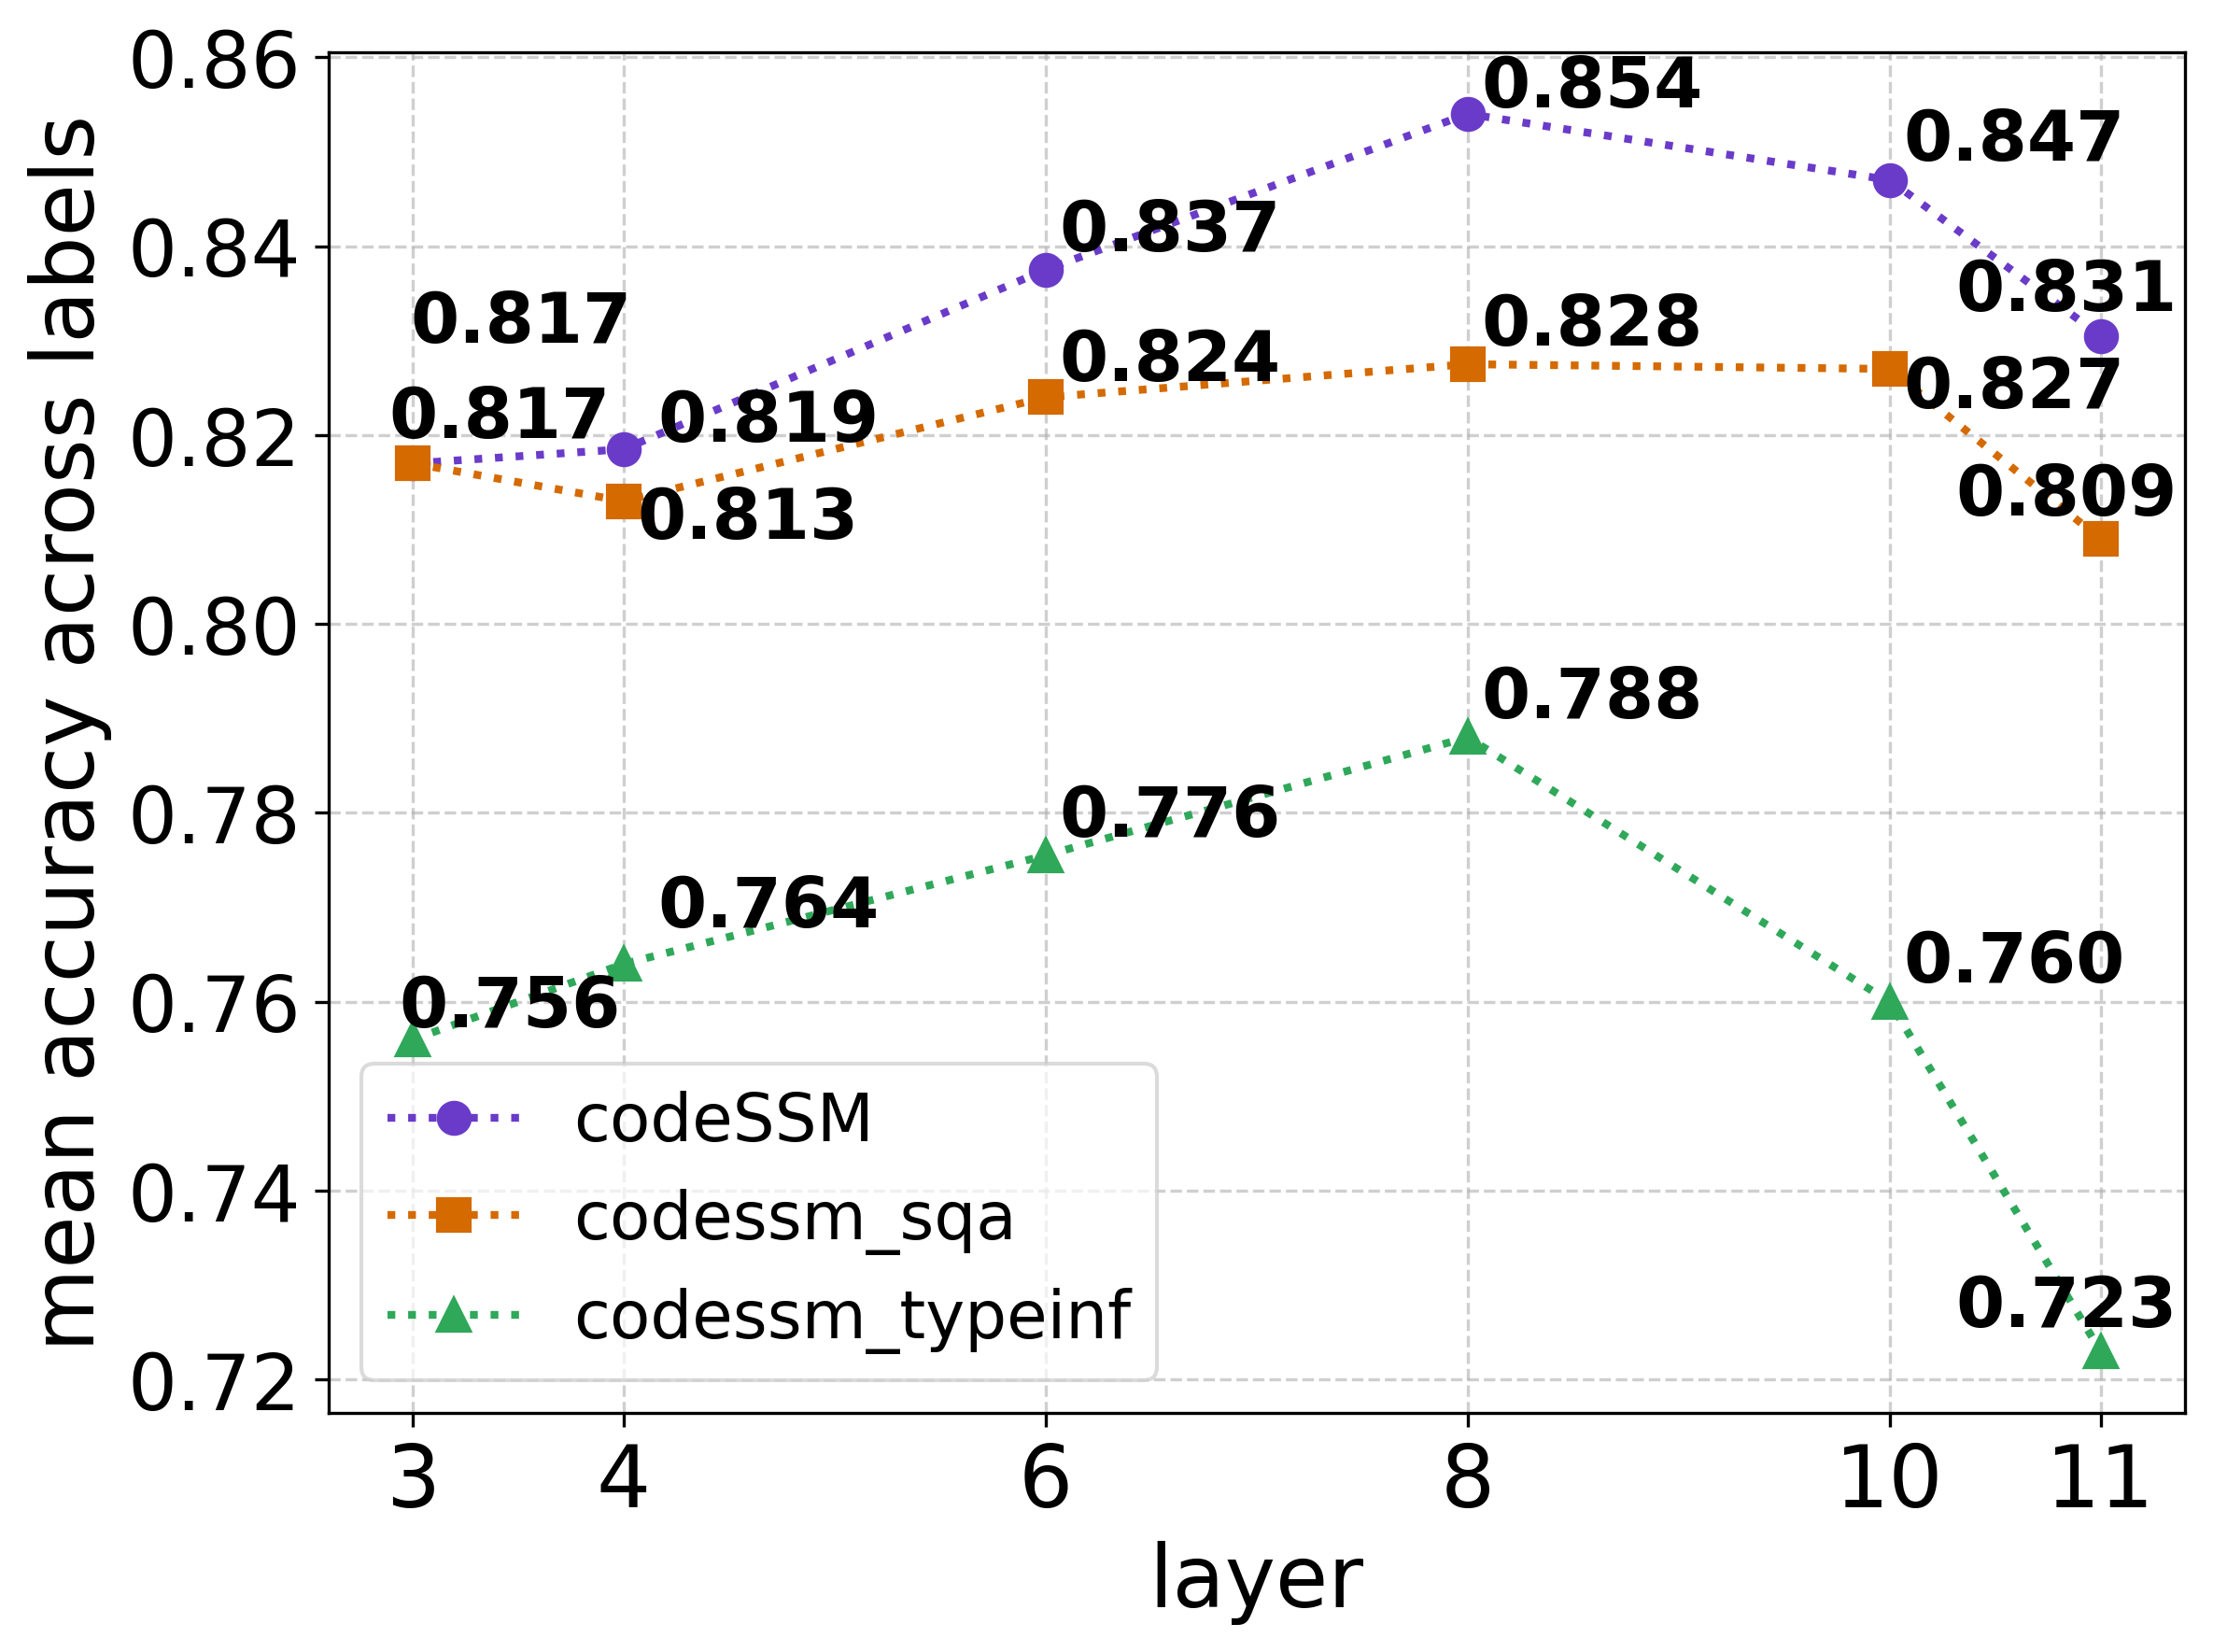

In [ ]:

models_name = 'pretrained_CodeSSM_vs_its_fine-tuned'
models = ['codeSSM', 'codessm_sqa', 'codessm_typeinf']
colors = ["#6A3BC9","#D46A00","#2FA85A"]
layer_wise_mean_accuracy_all_tasks(models ,colors, tasks_and_labels,models_name)

### Rocoder vs fine-tuned

mean accuracy of rocoder at layer 3 on dfg task : 0.775
mean accuracy of rocoder at layer 4 on dfg task : 0.794
mean accuracy of rocoder at layer 6 on dfg task : 0.808
mean accuracy of rocoder at layer 8 on dfg task : 0.818
mean accuracy of rocoder at layer 10 on dfg task : 0.797
mean accuracy of rocoder at layer 11 on dfg task : 0.794
mean accuracy of rocoder_sqa at layer 3 on dfg task : 0.764
mean accuracy of rocoder_sqa at layer 4 on dfg task : 0.78
mean accuracy of rocoder_sqa at layer 6 on dfg task : 0.802
mean accuracy of rocoder_sqa at layer 8 on dfg task : 0.806
mean accuracy of rocoder_sqa at layer 10 on dfg task : 0.768
mean accuracy of rocoder_sqa at layer 11 on dfg task : 0.76
mean accuracy of rocoder_typeinf at layer 3 on dfg task : 0.75
mean accuracy of rocoder_typeinf at layer 4 on dfg task : 0.753
mean accuracy of rocoder_typeinf at layer 6 on dfg task : 0.795
mean accuracy of rocoder_typeinf at layer 8 on dfg task : 0.81
mean accuracy of rocoder_typeinf at layer 10 on 

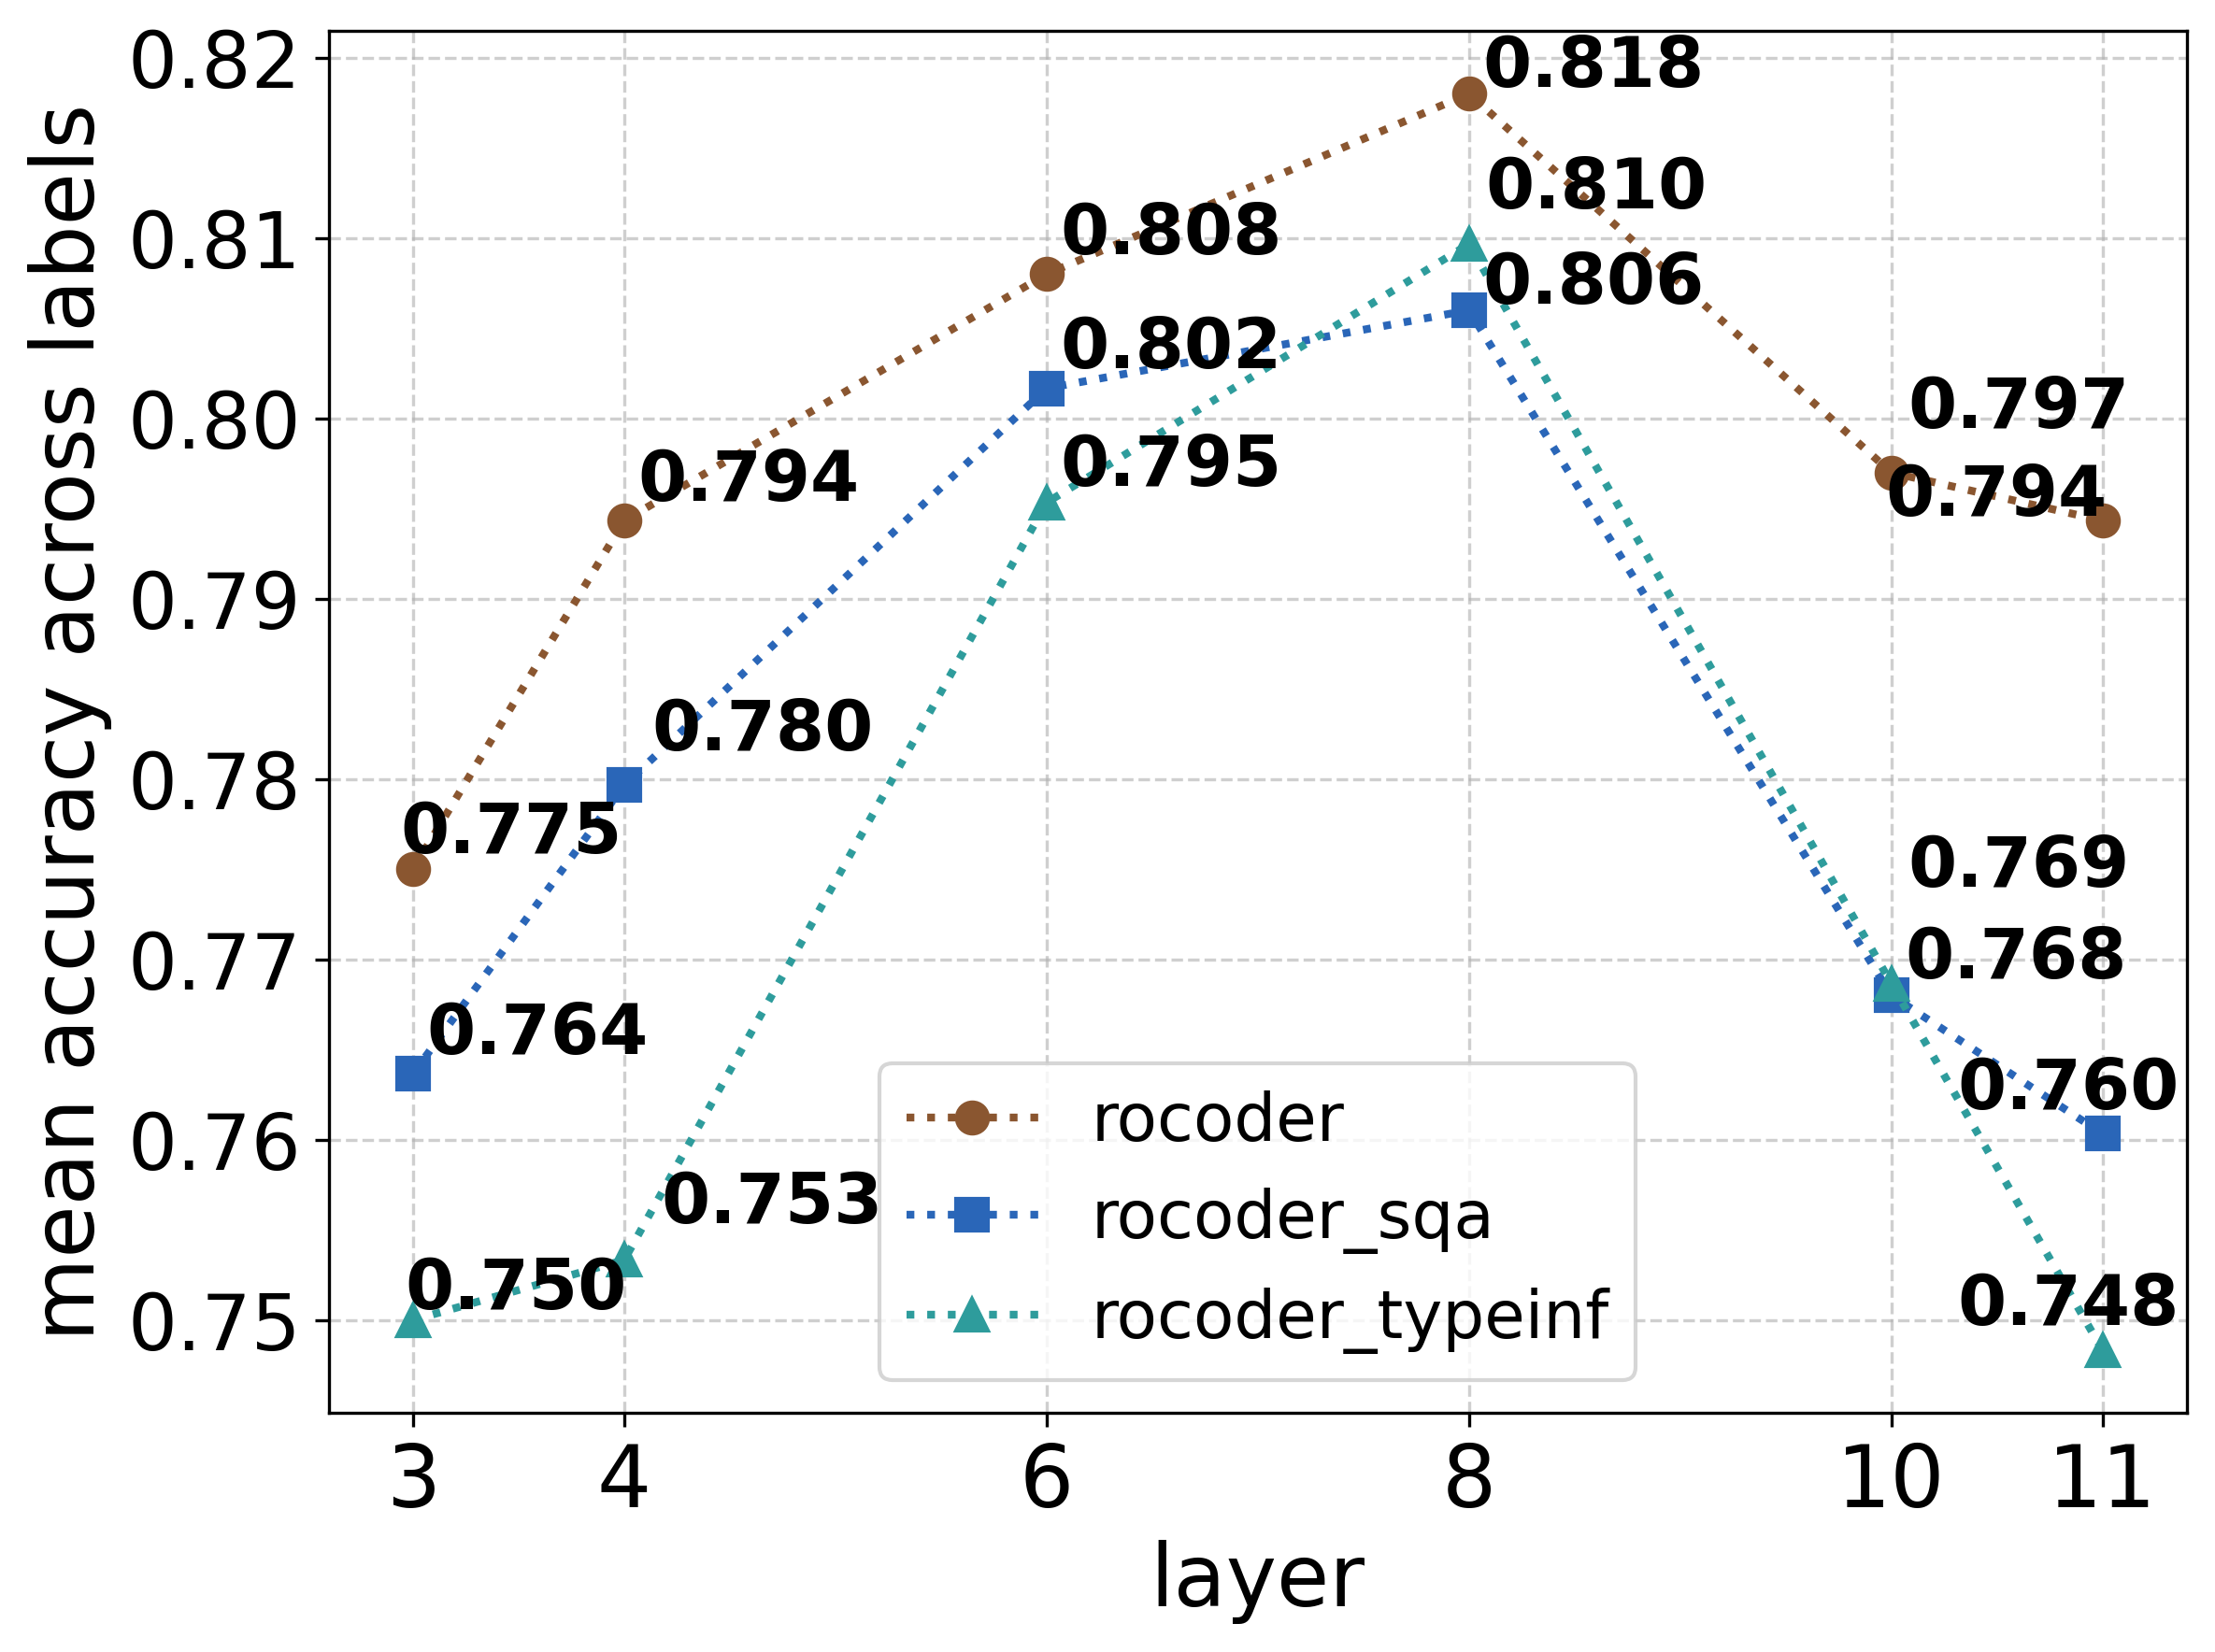

mean accuracy of rocoder at layer 3 on distance task : 0.559
mean accuracy of rocoder at layer 4 on distance task : 0.574
mean accuracy of rocoder at layer 6 on distance task : 0.595
mean accuracy of rocoder at layer 8 on distance task : 0.581
mean accuracy of rocoder at layer 10 on distance task : 0.515
mean accuracy of rocoder_sqa at layer 3 on distance task : 0.573
mean accuracy of rocoder_sqa at layer 4 on distance task : 0.574
mean accuracy of rocoder_sqa at layer 6 on distance task : 0.578
mean accuracy of rocoder_sqa at layer 8 on distance task : 0.547
mean accuracy of rocoder_typeinf at layer 3 on distance task : 0.602
mean accuracy of rocoder_typeinf at layer 4 on distance task : 0.612
mean accuracy of rocoder_typeinf at layer 6 on distance task : 0.626
mean accuracy of rocoder_typeinf at layer 8 on distance task : 0.625
mean accuracy of rocoder_typeinf at layer 10 on distance task : 0.534
mean accuracy of rocoder_typeinf at layer 11 on distance task : 0.516
1 [0.99865883 0.28

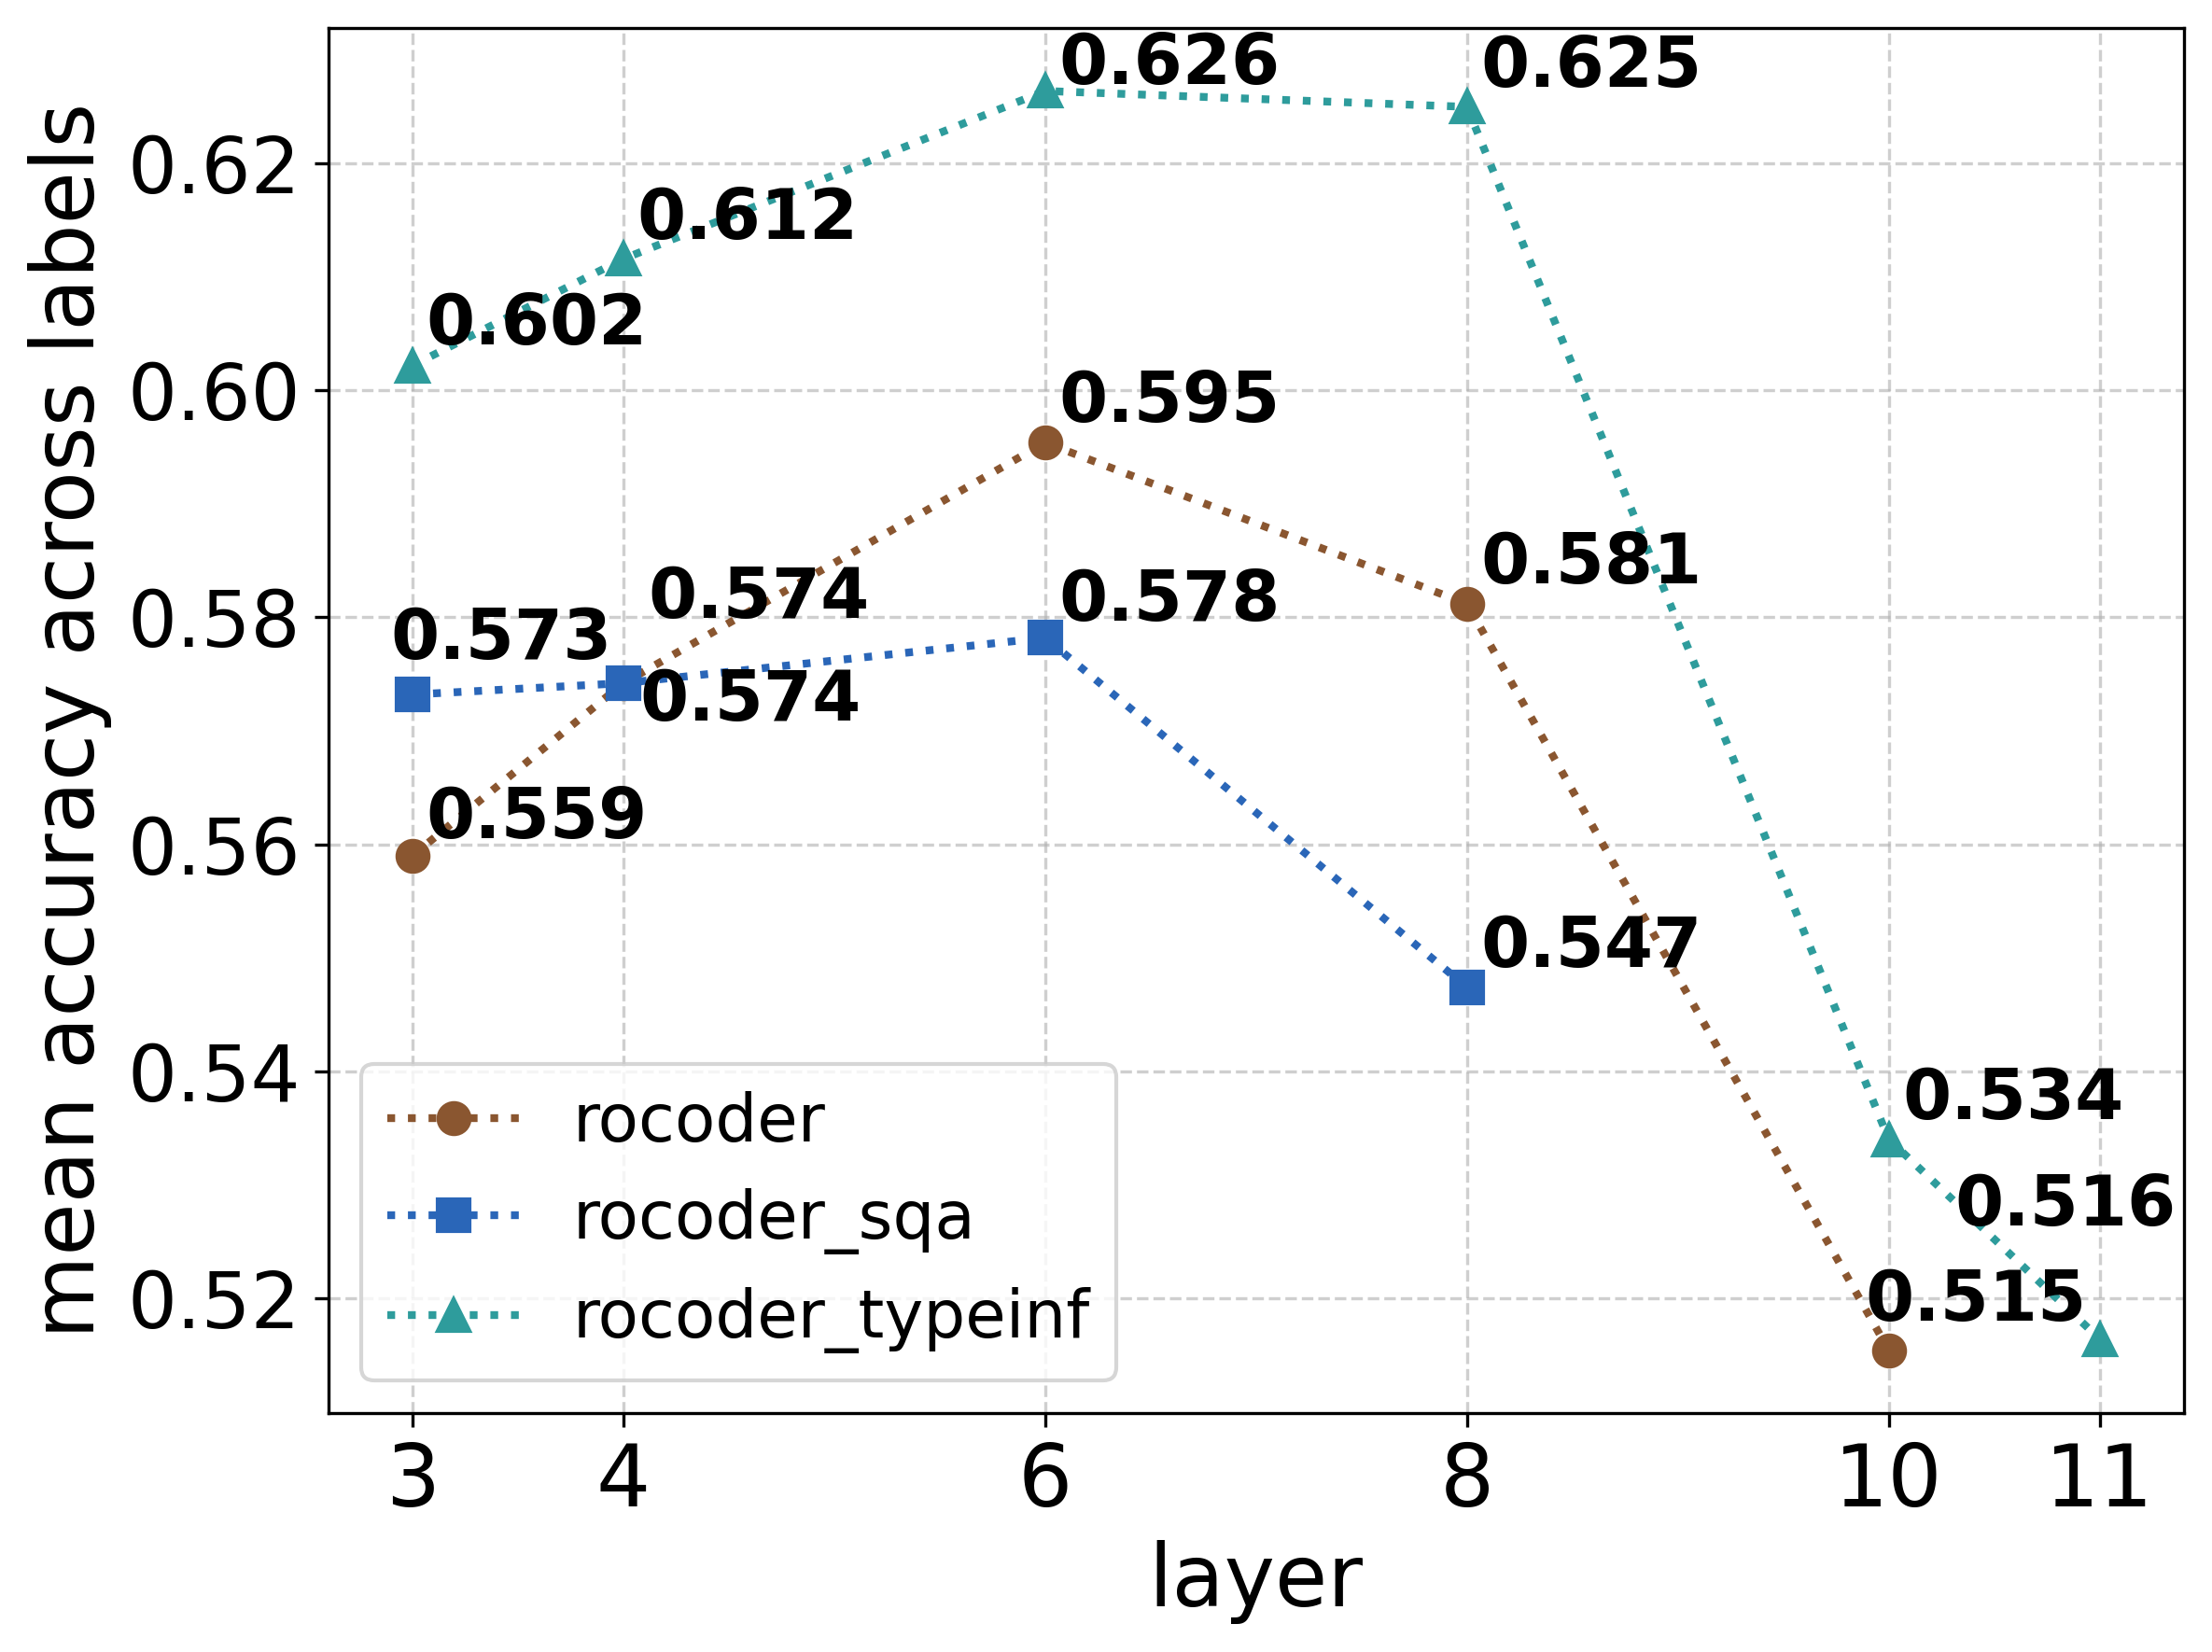

mean accuracy of rocoder at layer 3 on siblings task : 0.755
mean accuracy of rocoder at layer 4 on siblings task : 0.766
mean accuracy of rocoder at layer 6 on siblings task : 0.796
mean accuracy of rocoder at layer 8 on siblings task : 0.789
mean accuracy of rocoder at layer 10 on siblings task : 0.722
mean accuracy of rocoder at layer 11 on siblings task : 0.688
mean accuracy of rocoder_sqa at layer 3 on siblings task : 0.762
mean accuracy of rocoder_sqa at layer 4 on siblings task : 0.774
mean accuracy of rocoder_sqa at layer 6 on siblings task : 0.786
mean accuracy of rocoder_sqa at layer 8 on siblings task : 0.794
mean accuracy of rocoder_sqa at layer 10 on siblings task : 0.72
mean accuracy of rocoder_sqa at layer 11 on siblings task : 0.677
mean accuracy of rocoder_typeinf at layer 3 on siblings task : 0.792
mean accuracy of rocoder_typeinf at layer 4 on siblings task : 0.806
mean accuracy of rocoder_typeinf at layer 6 on siblings task : 0.836
mean accuracy of rocoder_typeinf a

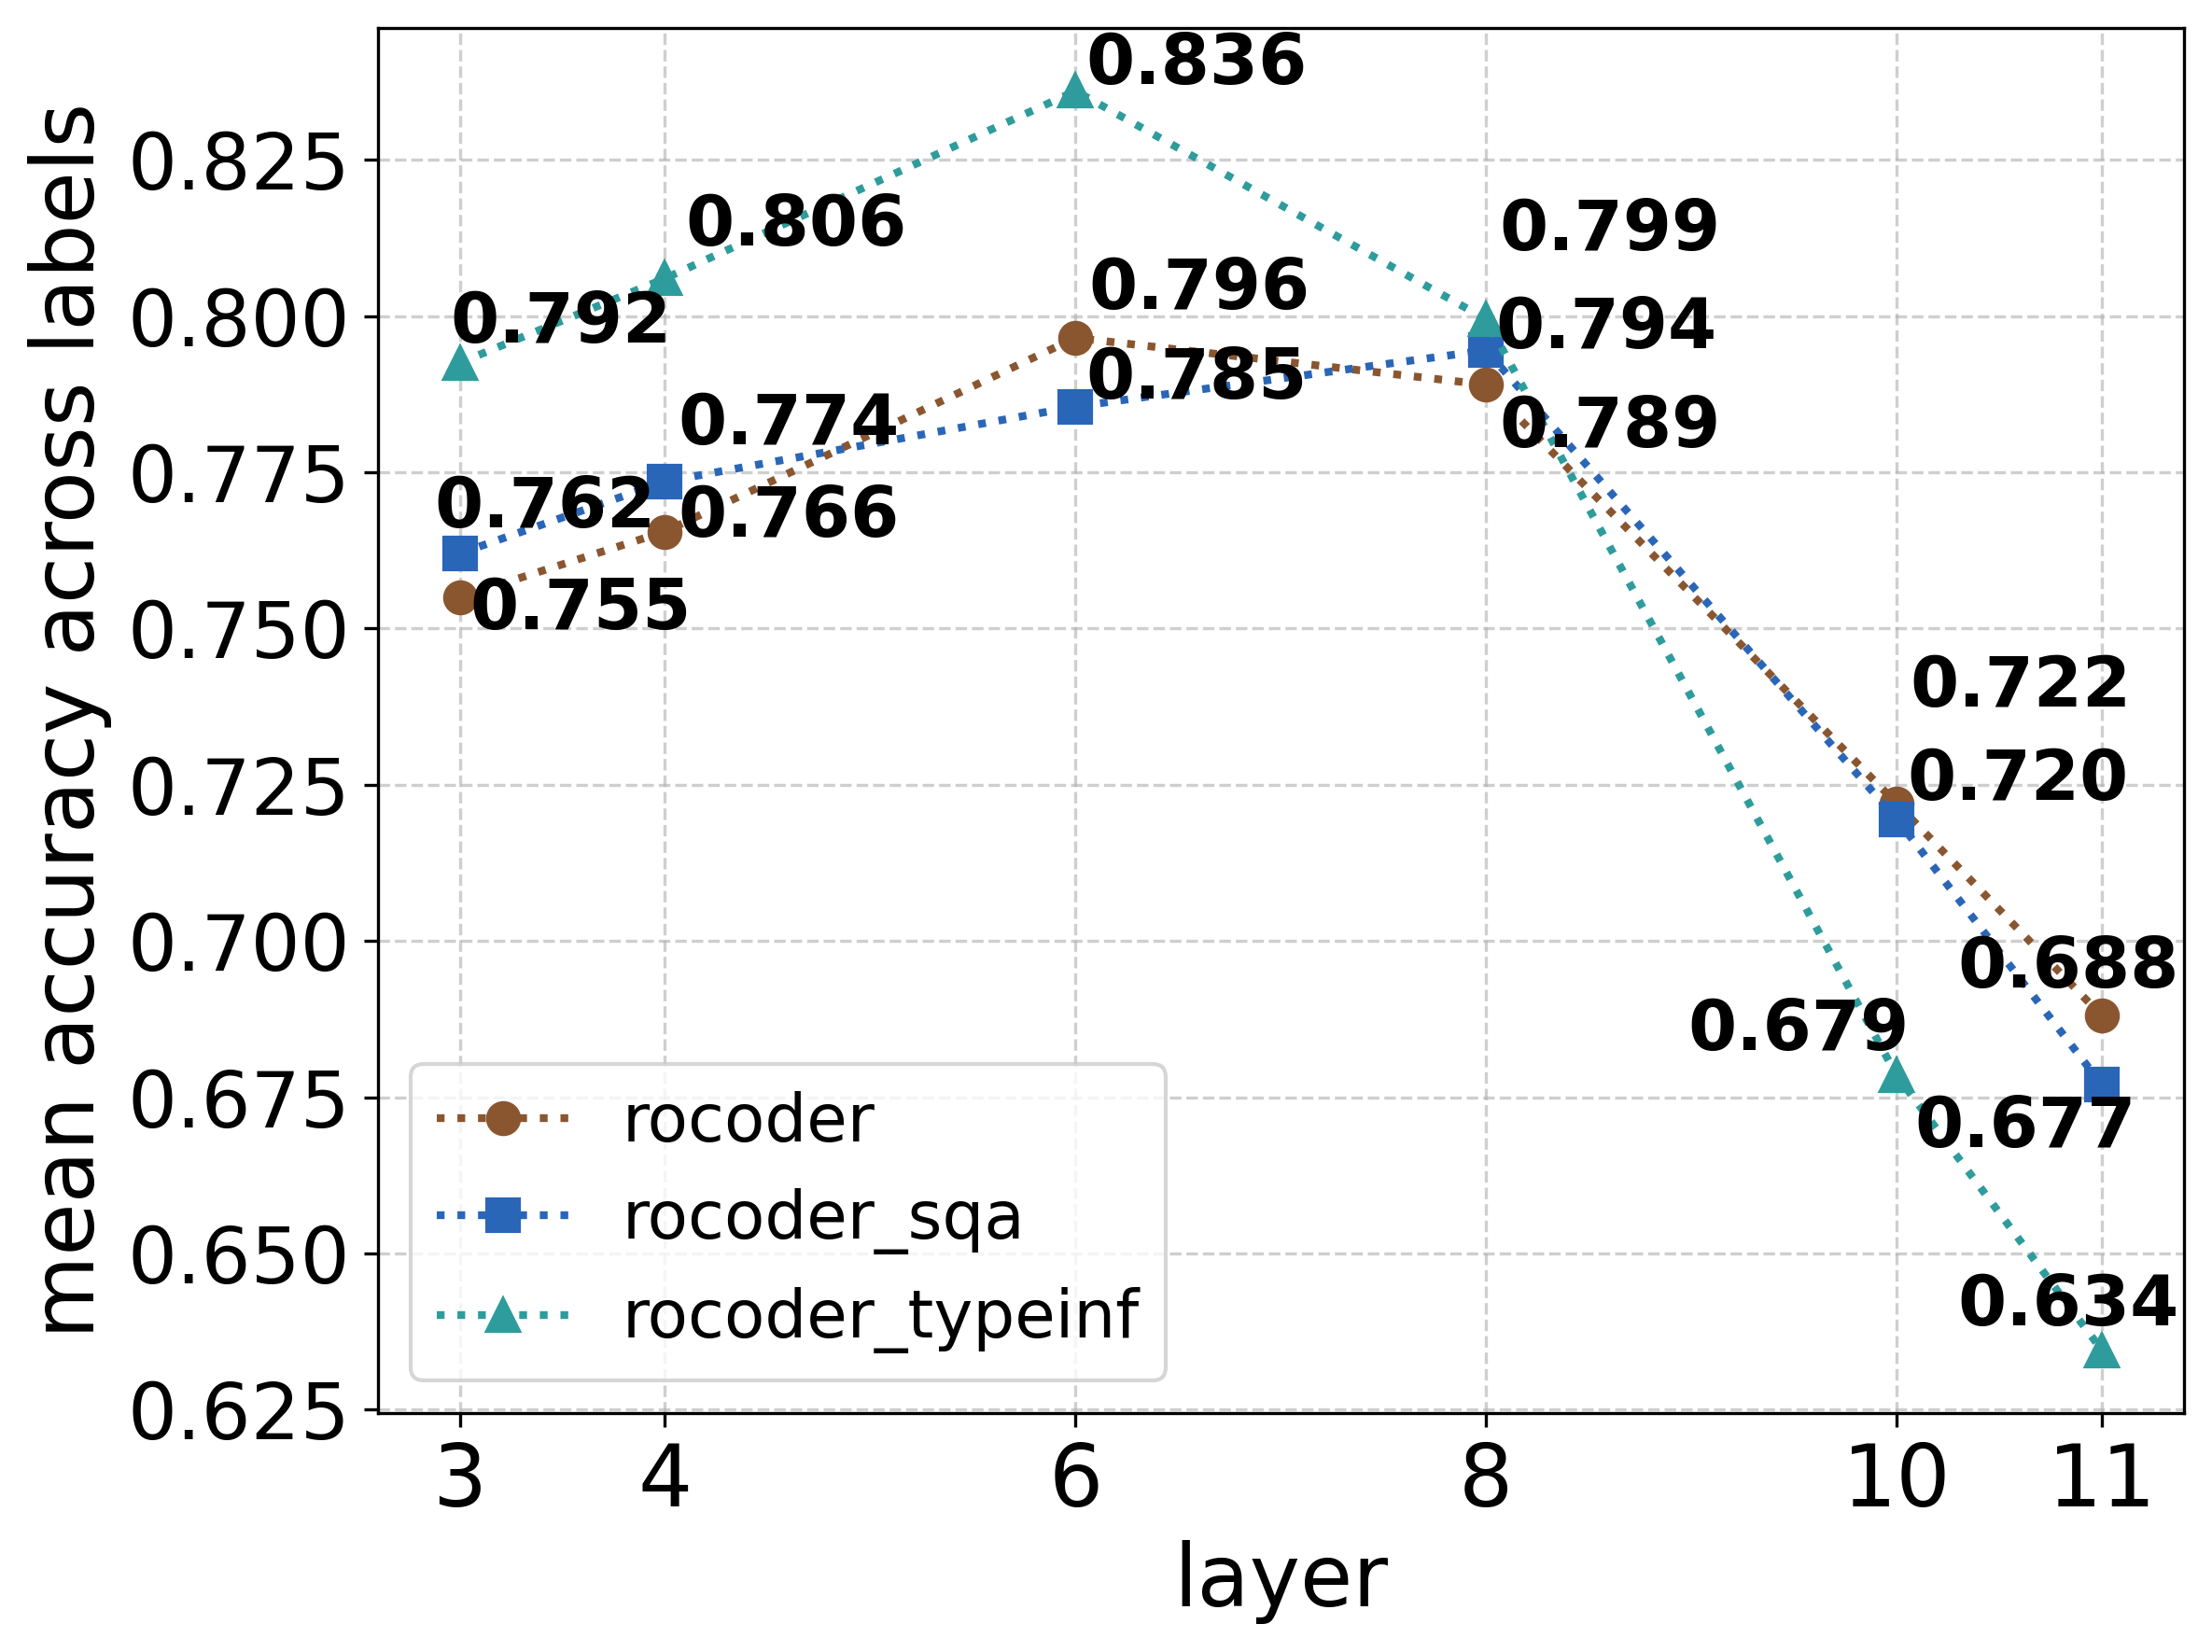

In [ ]:
models_name = 'pretrained_Rocoder_vs_its_fine-tuned'
models = ['rocoder','rocoder_sqa','rocoder_typeinf']
colors = [ "#8A5630", "#2A66B8","#2E9C9C"]
layer_wise_mean_accuracy_all_tasks(models, colors,tasks_and_labels,models_name)

#distance_accuracy - column diagram


In [ ]:
def get_distance_accuracy(modelname,layer):
  dis_label= ['2.0','3.0','4.0','5.0','6.0']
  res_dir = '../DirectProbe/results/'
  predict_path = os.path.join(res_dir, 'distance', modelname, str(layer), 'prediction.txt')

  accuracy = [0 for _ in dis_label]
  for i, distance in enumerate(dis_label):
    correct = 0
    total = 0
    with open(predict_path) as f:
        for line in f:
            predictions = line.rstrip('\n').split('\t')
            label, pred = predictions[0], predictions[1].split(',')[0]
            if predictions[0] == distance:
                total +=1
                index_of_hyph = pred.index('-')
                predicted_label = pred[index_of_hyph+1:]
                if label == predicted_label:
                  correct +=1
    acc =(round(correct/total, 3))
    accuracy[i] = acc

  return accuracy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_distance(model1, model2,color1,color2,layers):

  for layer in layers:
    plt.figure(figsize=(8, 6), dpi=300)
    x_label =  ['2.0','3.0','4.0','5.0','6.0']
    y_model1 = get_distance_accuracy(model1,layer)
    y_model2 = get_distance_accuracy(model2,layer)

    width = 0.35
    x_pos = np.arange(len(x_label))


    bars1 = plt.bar(x_pos - width/2, y_model1, width, label=f'{model1}',color=color1)
    bars2 = plt.bar(x_pos + width/2, y_model2, width, label=f'{model2}',color=color2)
    texts = []
    for i in range(len(x_label)):
      text = plt.text(x_pos[i] - width/2 -0.08, y_model1[i],
              f'{y_model1[i]:.2f}',
              ha='center', va='bottom', fontsize=18)

    for i in range(len(x_label)):
      text = plt.text(x_pos[i] + width/2 +0.07,  y_model2[i],
             f'{y_model2[i]:.2f}',
             ha='center', va='bottom', fontsize=18)

    for i in x_pos:
        diff = y_model1[i] - y_model2[i]

        y_pos = max(y_model1[i], y_model2[i]) + 0.09
        text = plt.text(i, y_pos, f'{diff:+.2f}',
                ha='center', va='bottom', fontsize=18,
                color='red' if diff < 0 else 'green',
                fontweight='bold')

    plt.yticks(np.arange(0, 1.1, 0.2),fontsize=22)


    plt.xlabel('distance',fontsize=22)
    plt.ylabel('mean accuracy across layers',fontsize=22)
    title = f'Accuracy_{model1}_and_{model2}_distance_task_at_{layer}_layer'
    print(title)
    plt.xticks(x_pos, x_label,fontsize=22)
    plt.legend(fontsize=20)
    plt.grid(axis='y', alpha=0.3)
    plt.savefig(f"./plots_for_paper/update/{title}.pdf", dpi=300)

    plt.show()

Accuracy_codeSSM_and_rocoder_distance_task_at_6_layer


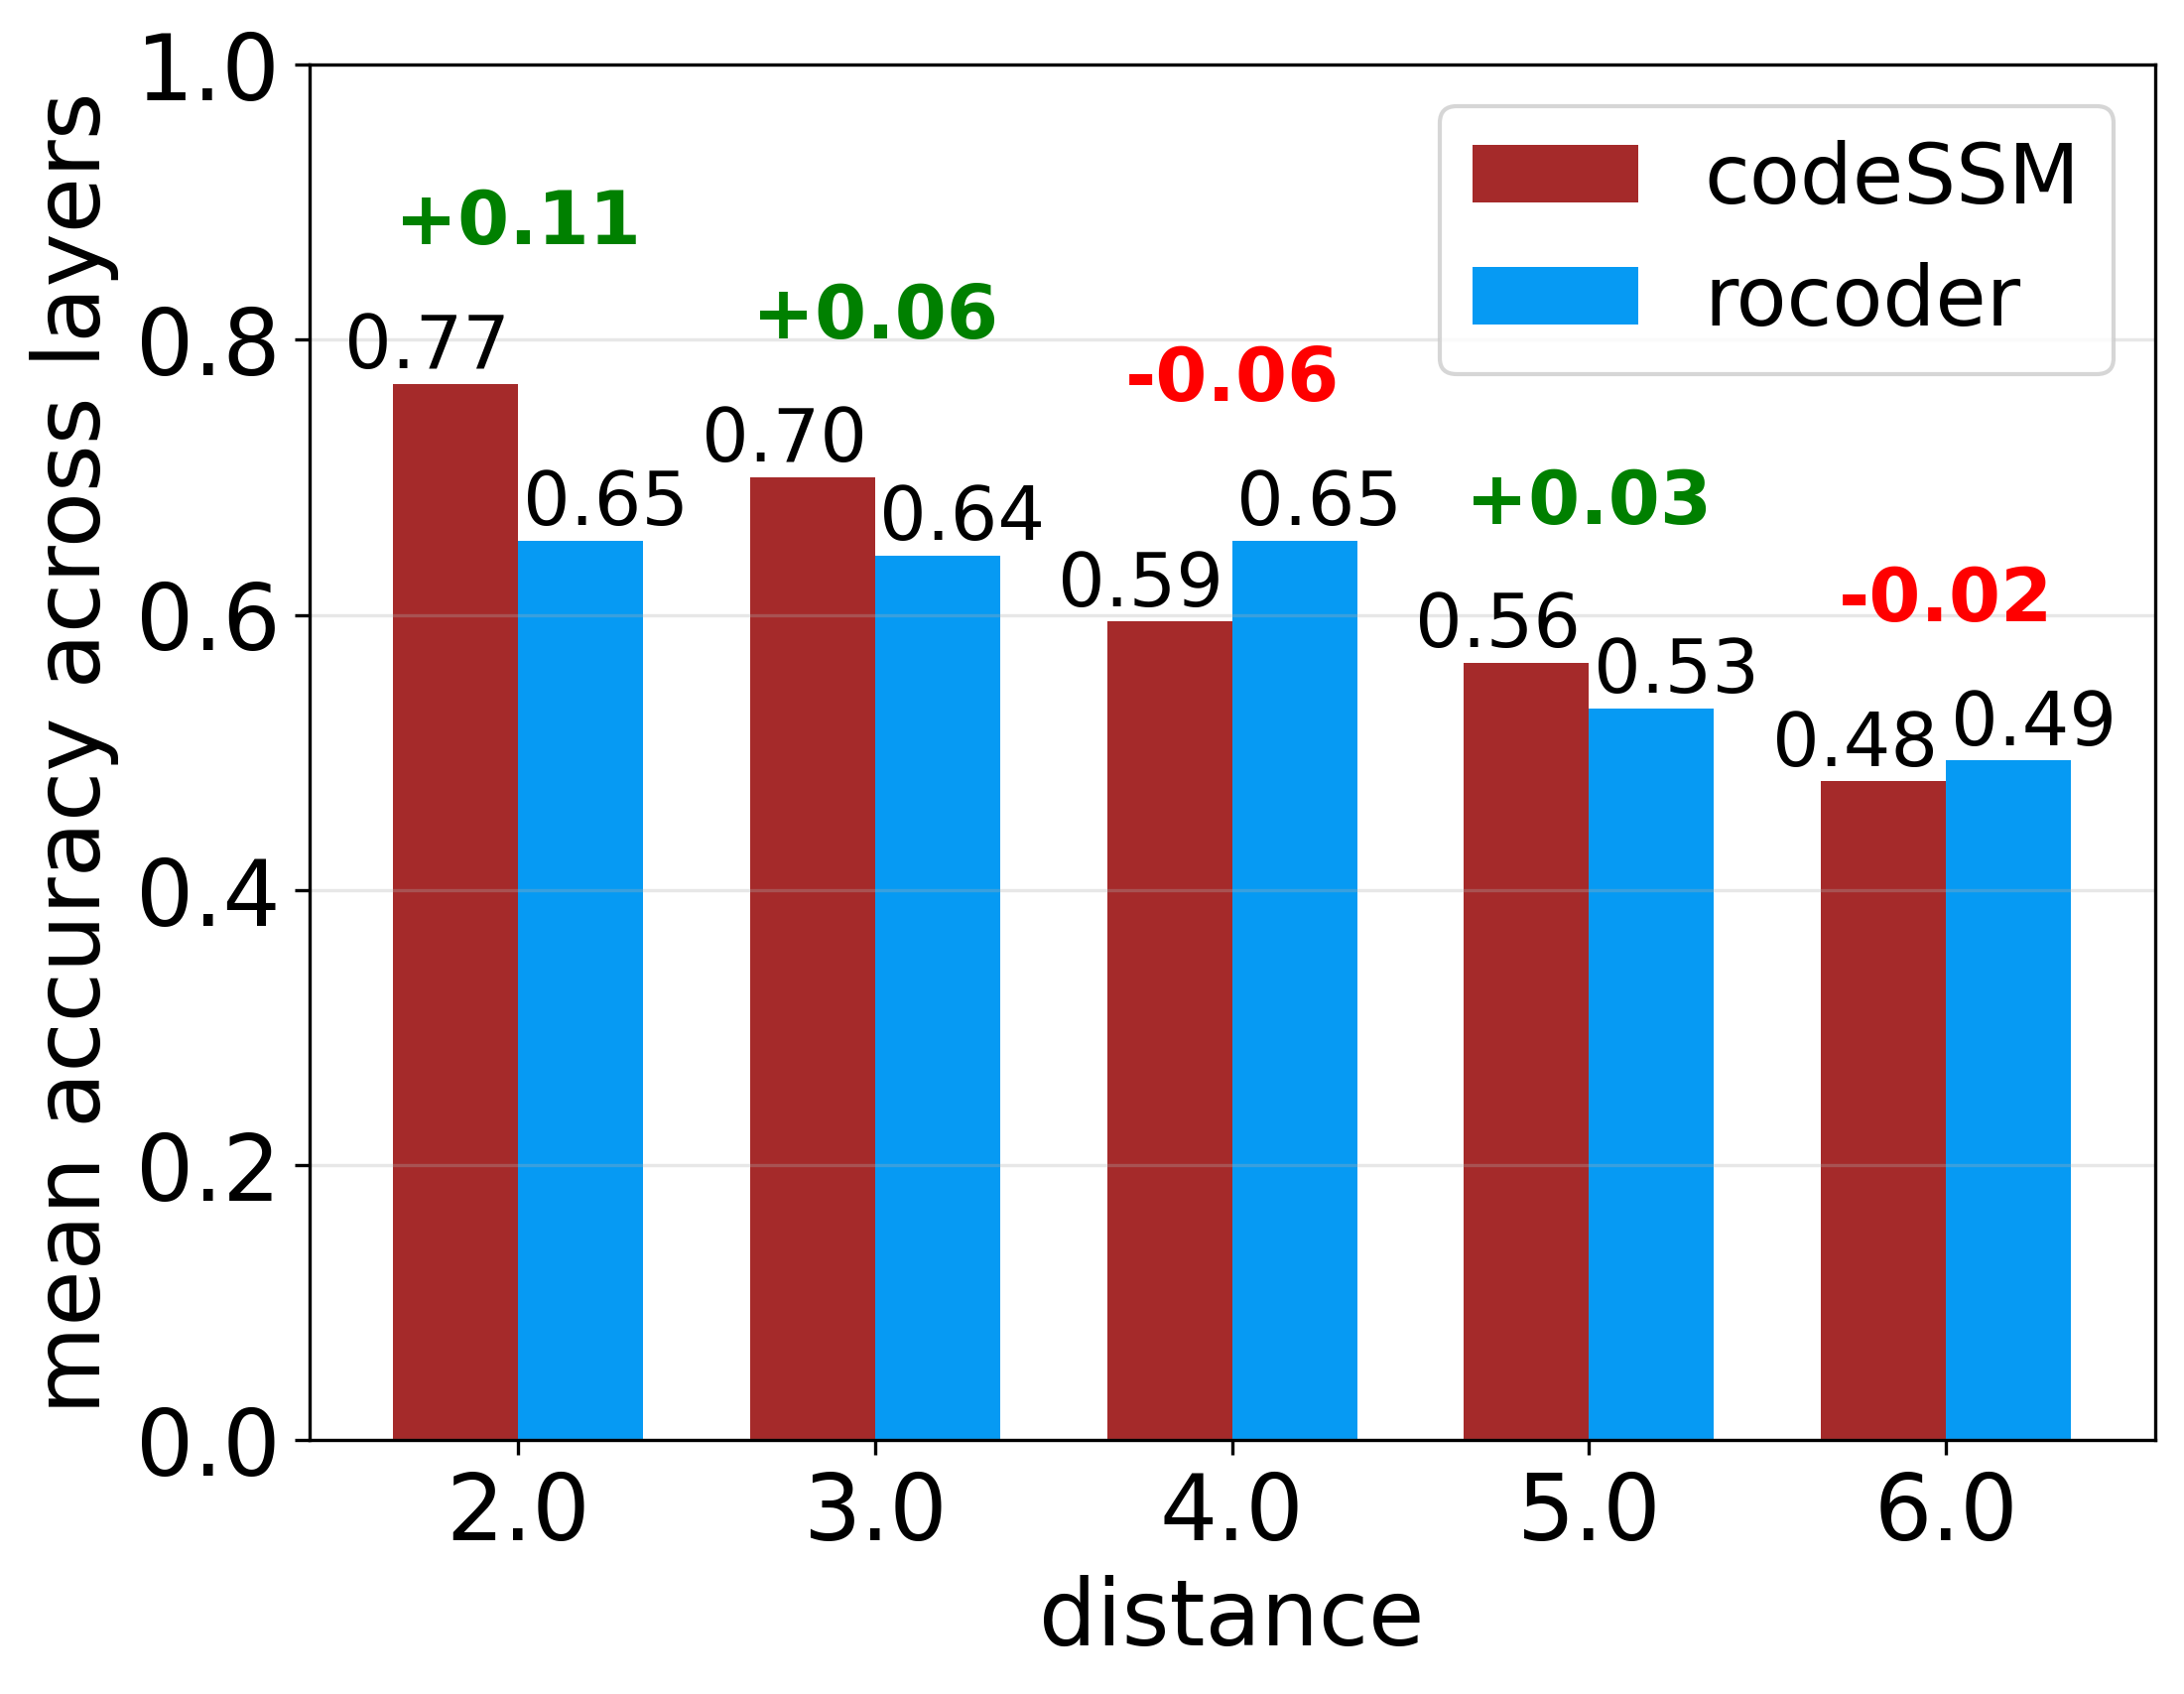

Accuracy_codeSSM_and_rocoder_distance_task_at_8_layer


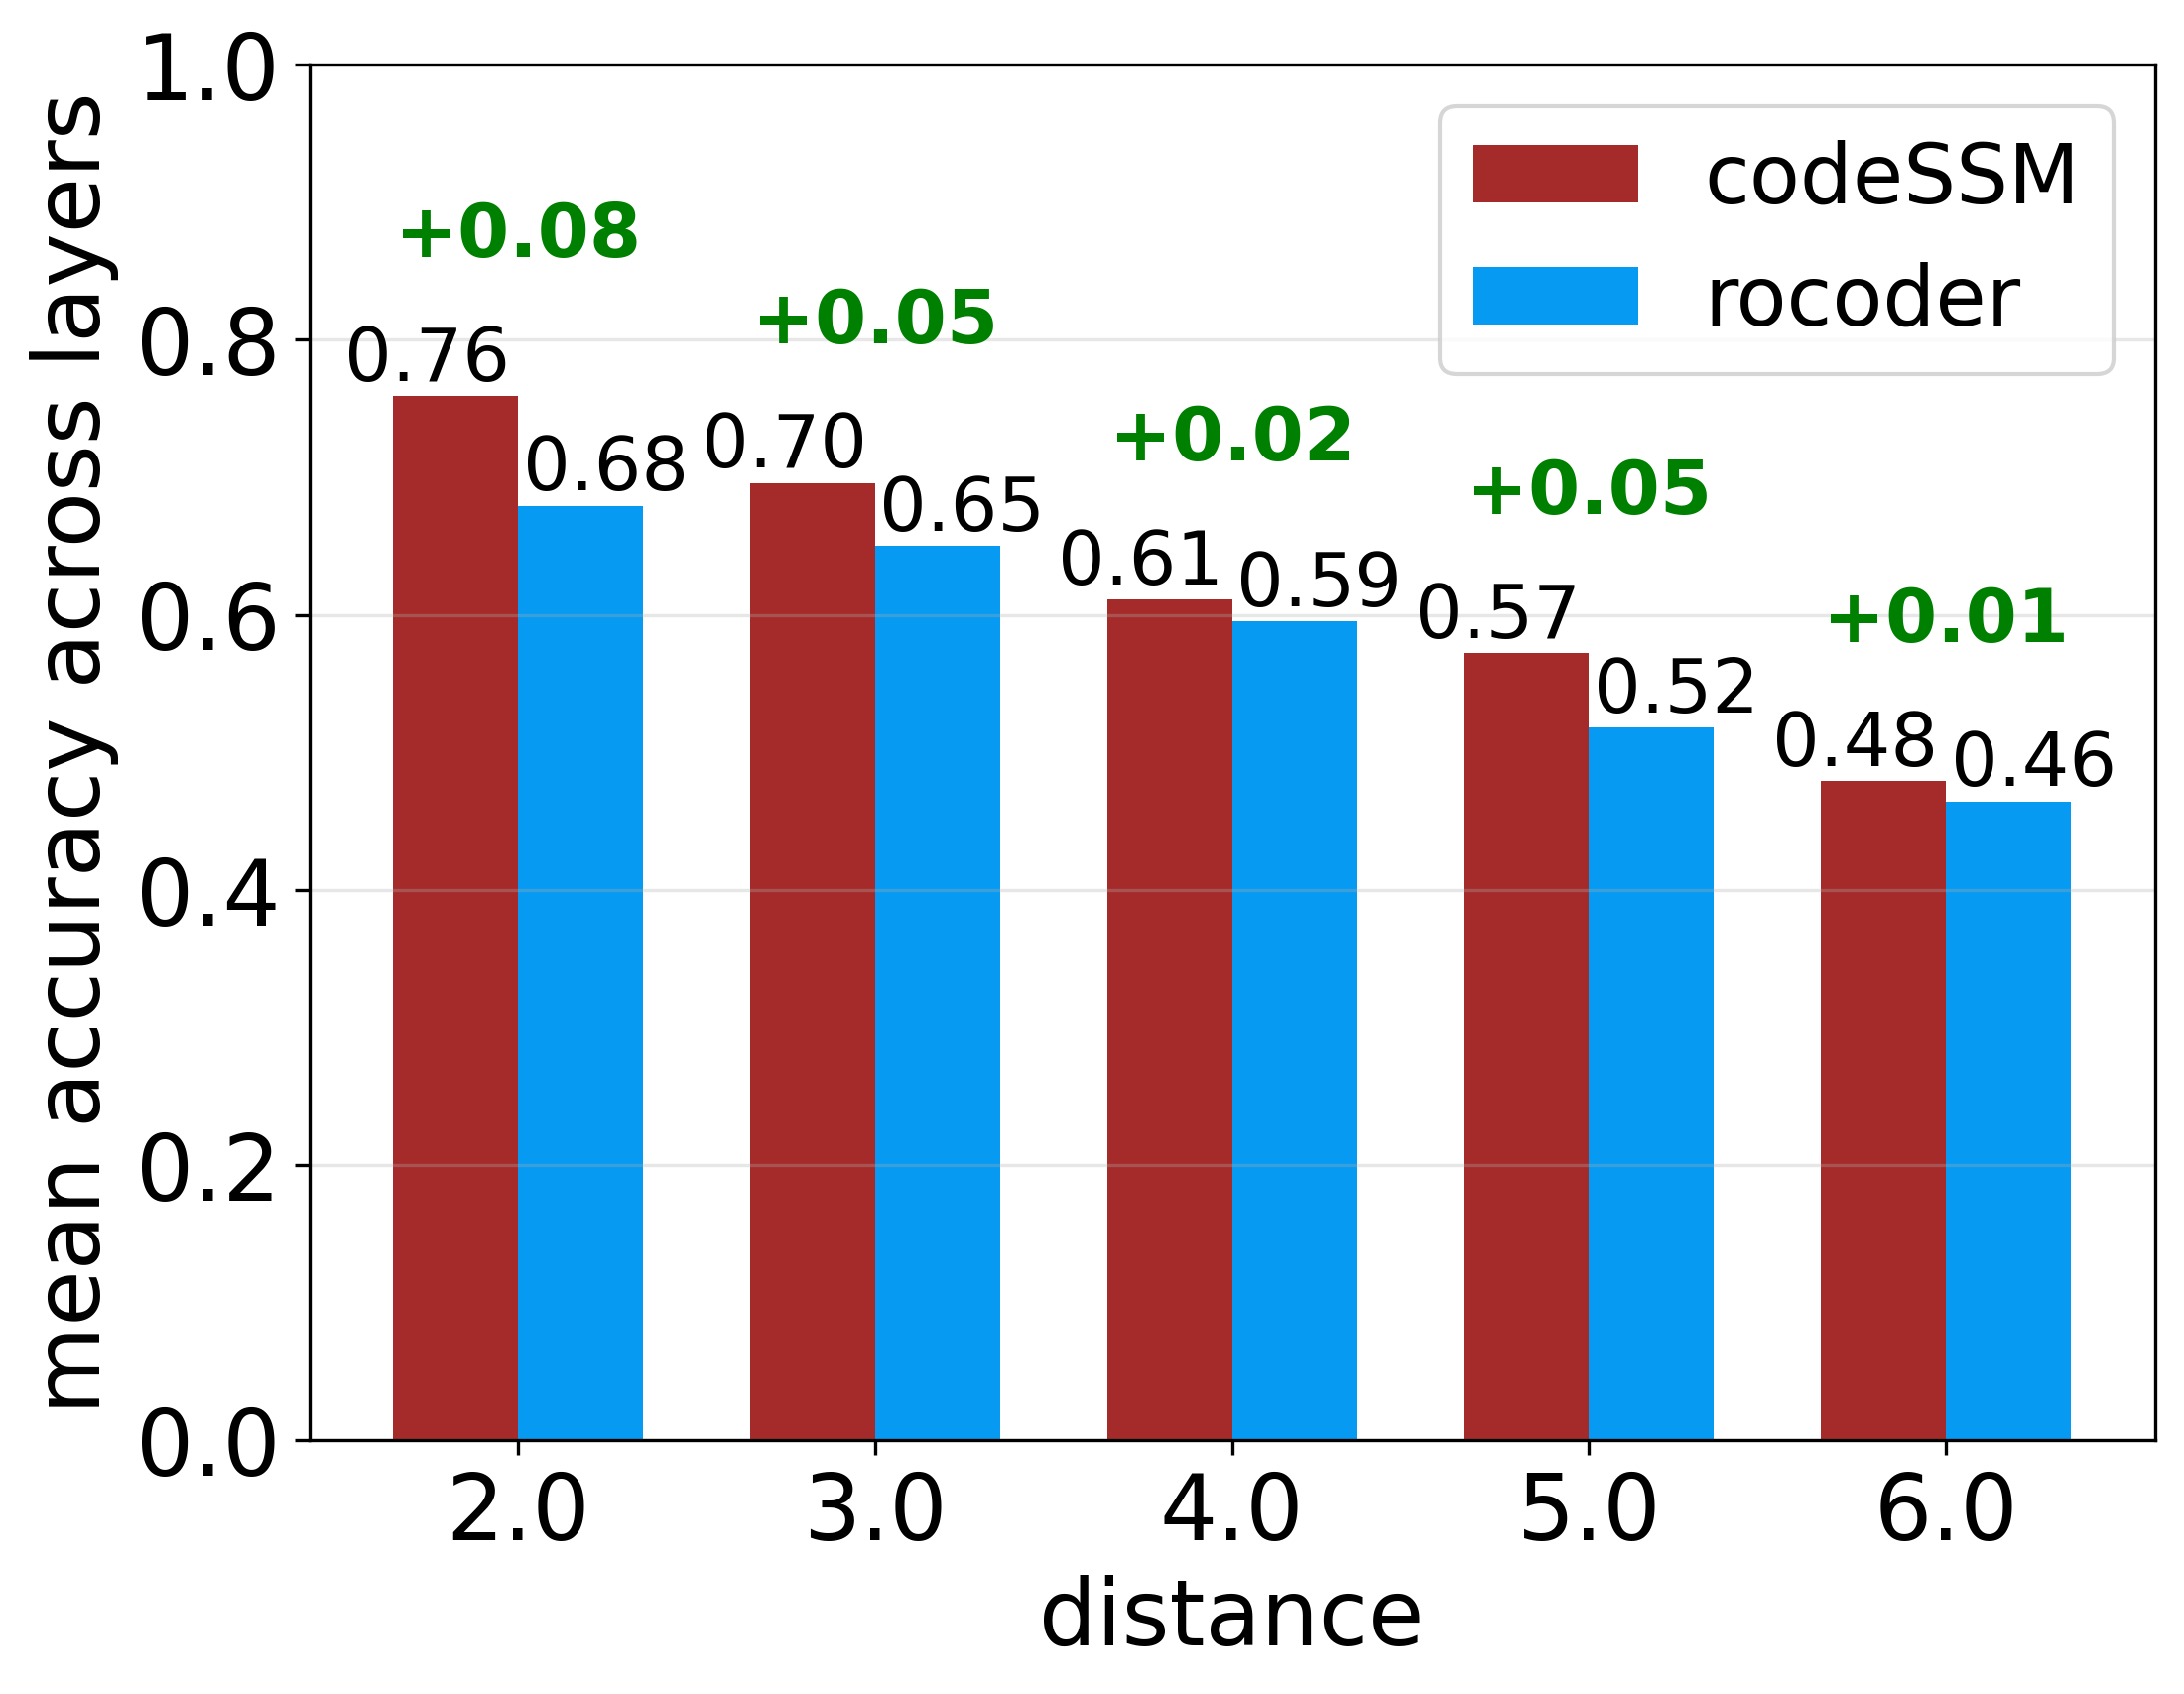

Accuracy_codeSSM_and_rocoder_distance_task_at_10_layer


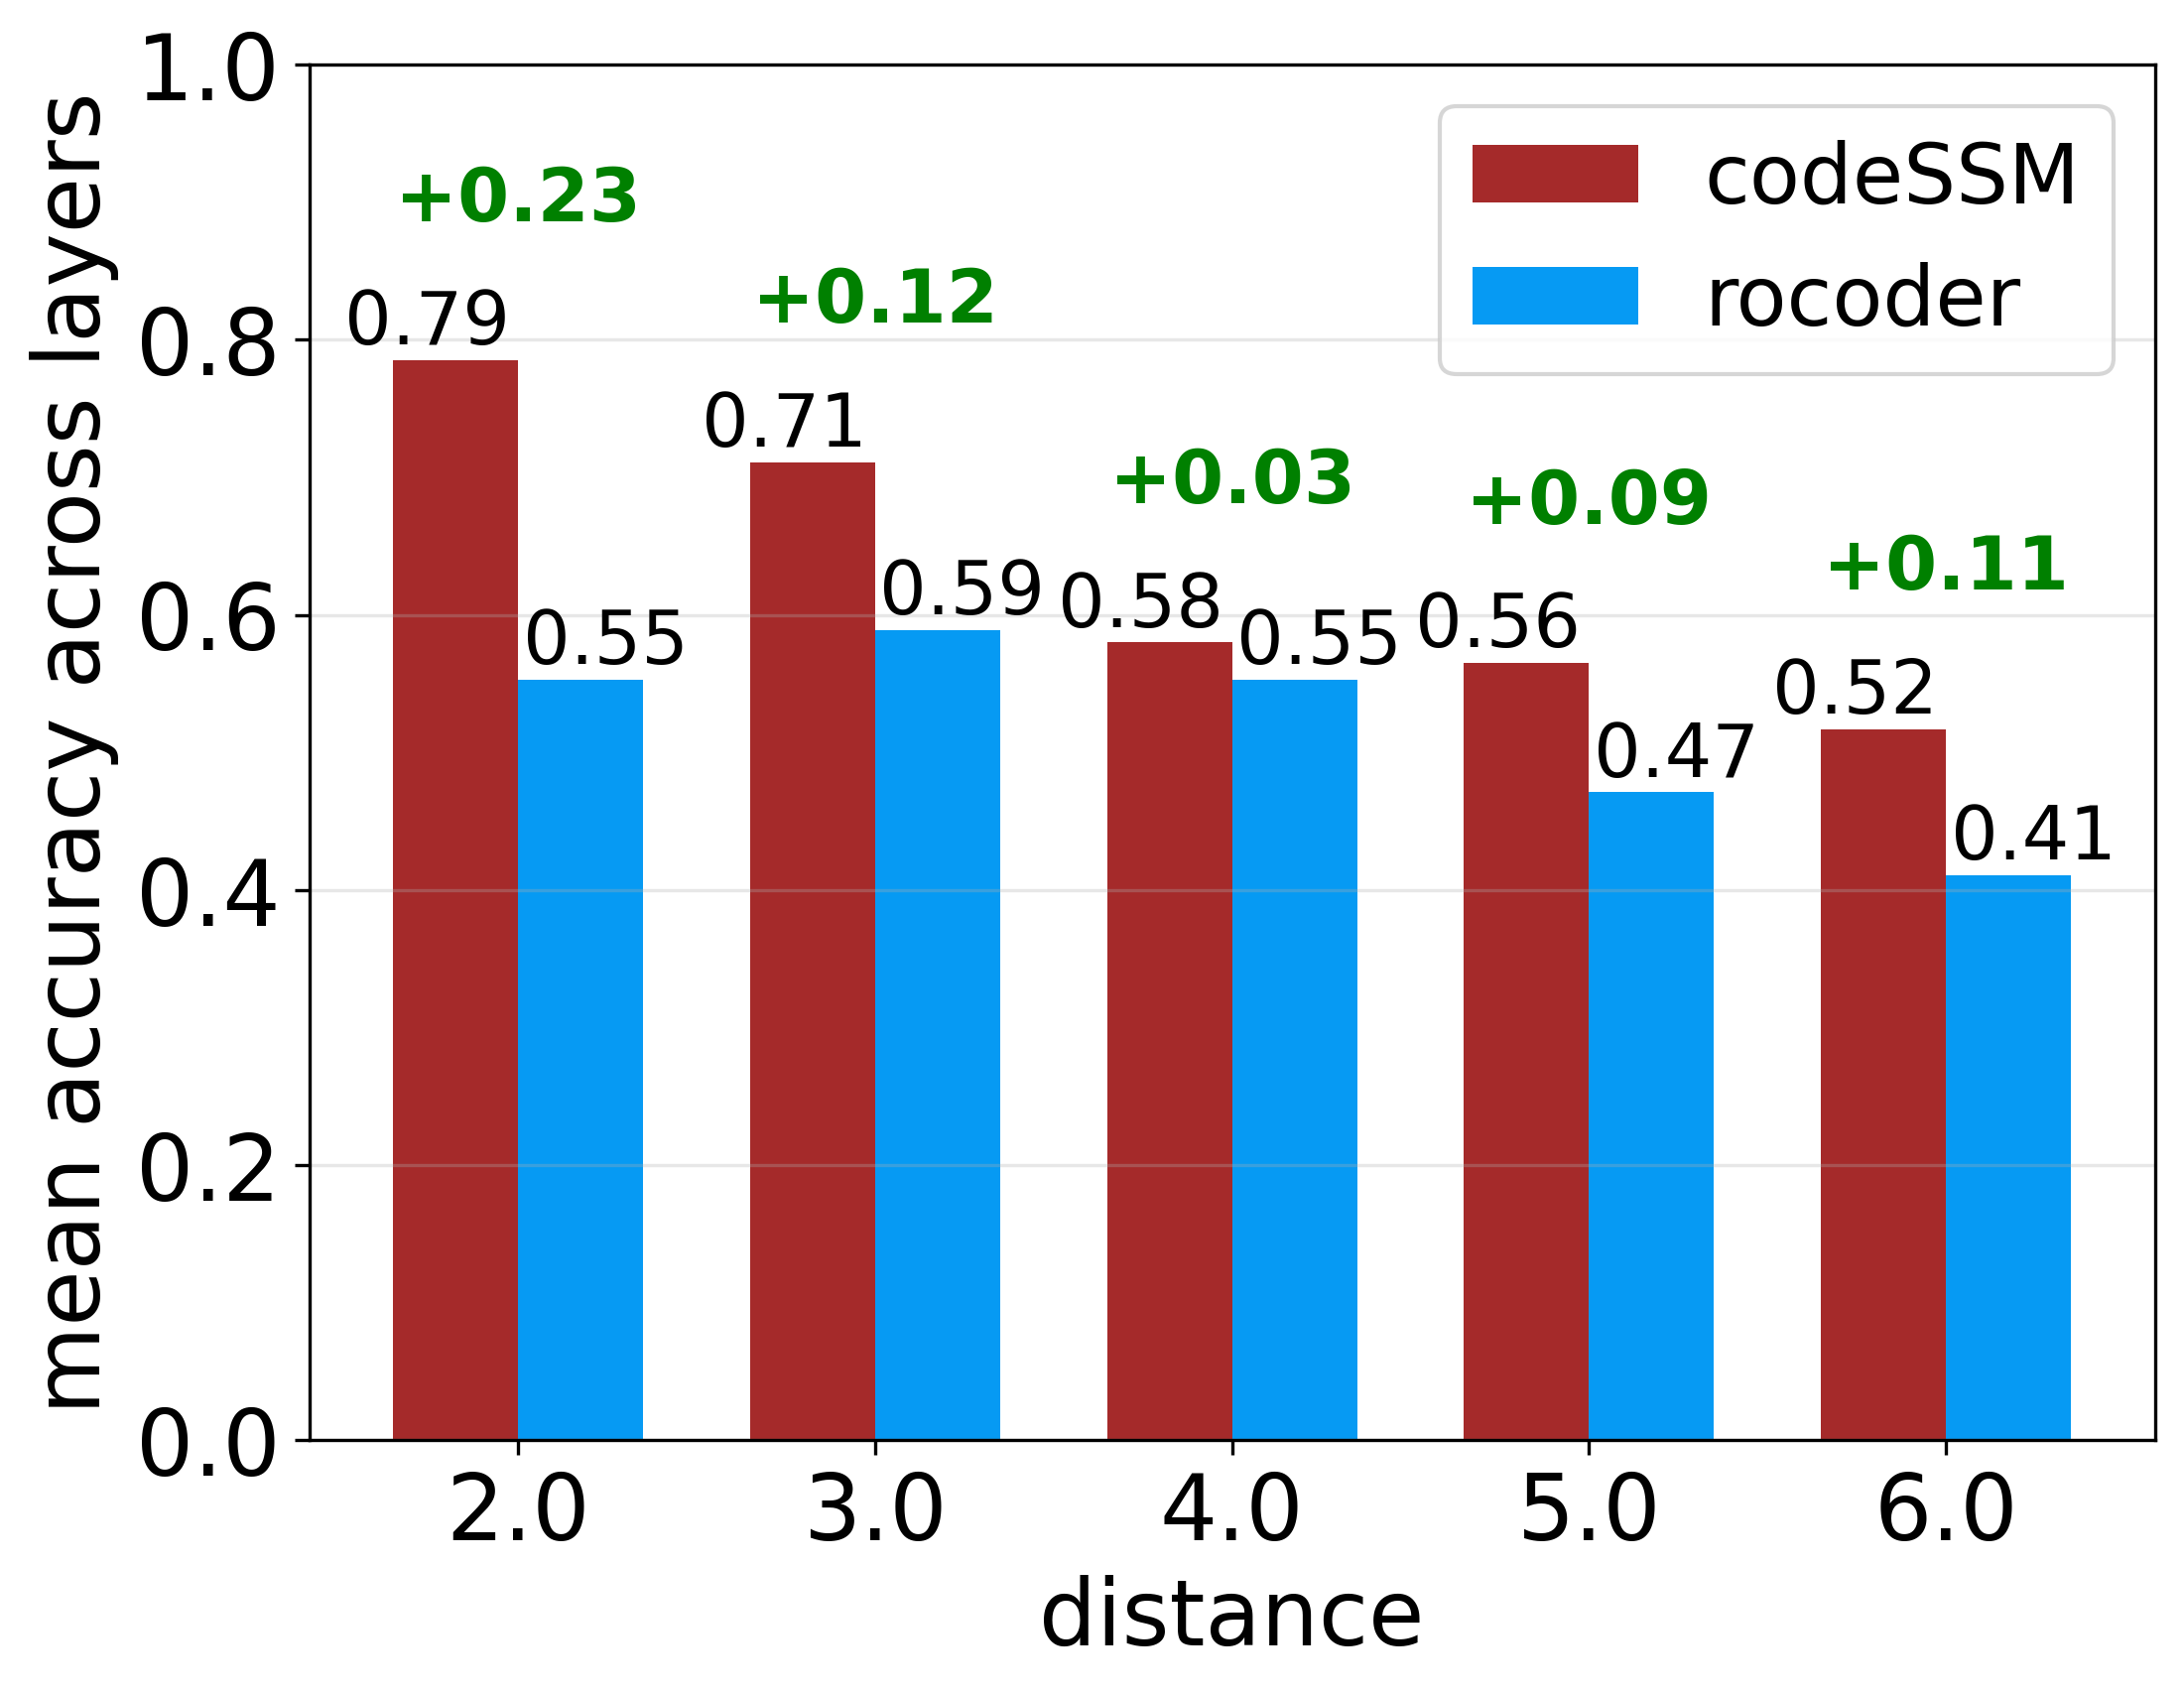

In [ ]:
res_dir = '../DirectProbe/results/'
color1 ='#a52a2A'
color2 = '#069AF3'
layers = [6,8,10]
plot_distance('codeSSM', 'rocoder',color1,color2,layers)

Accuracy_codessm_typeinf_and_rocoder_typeinf_distance_task_at_6_layer


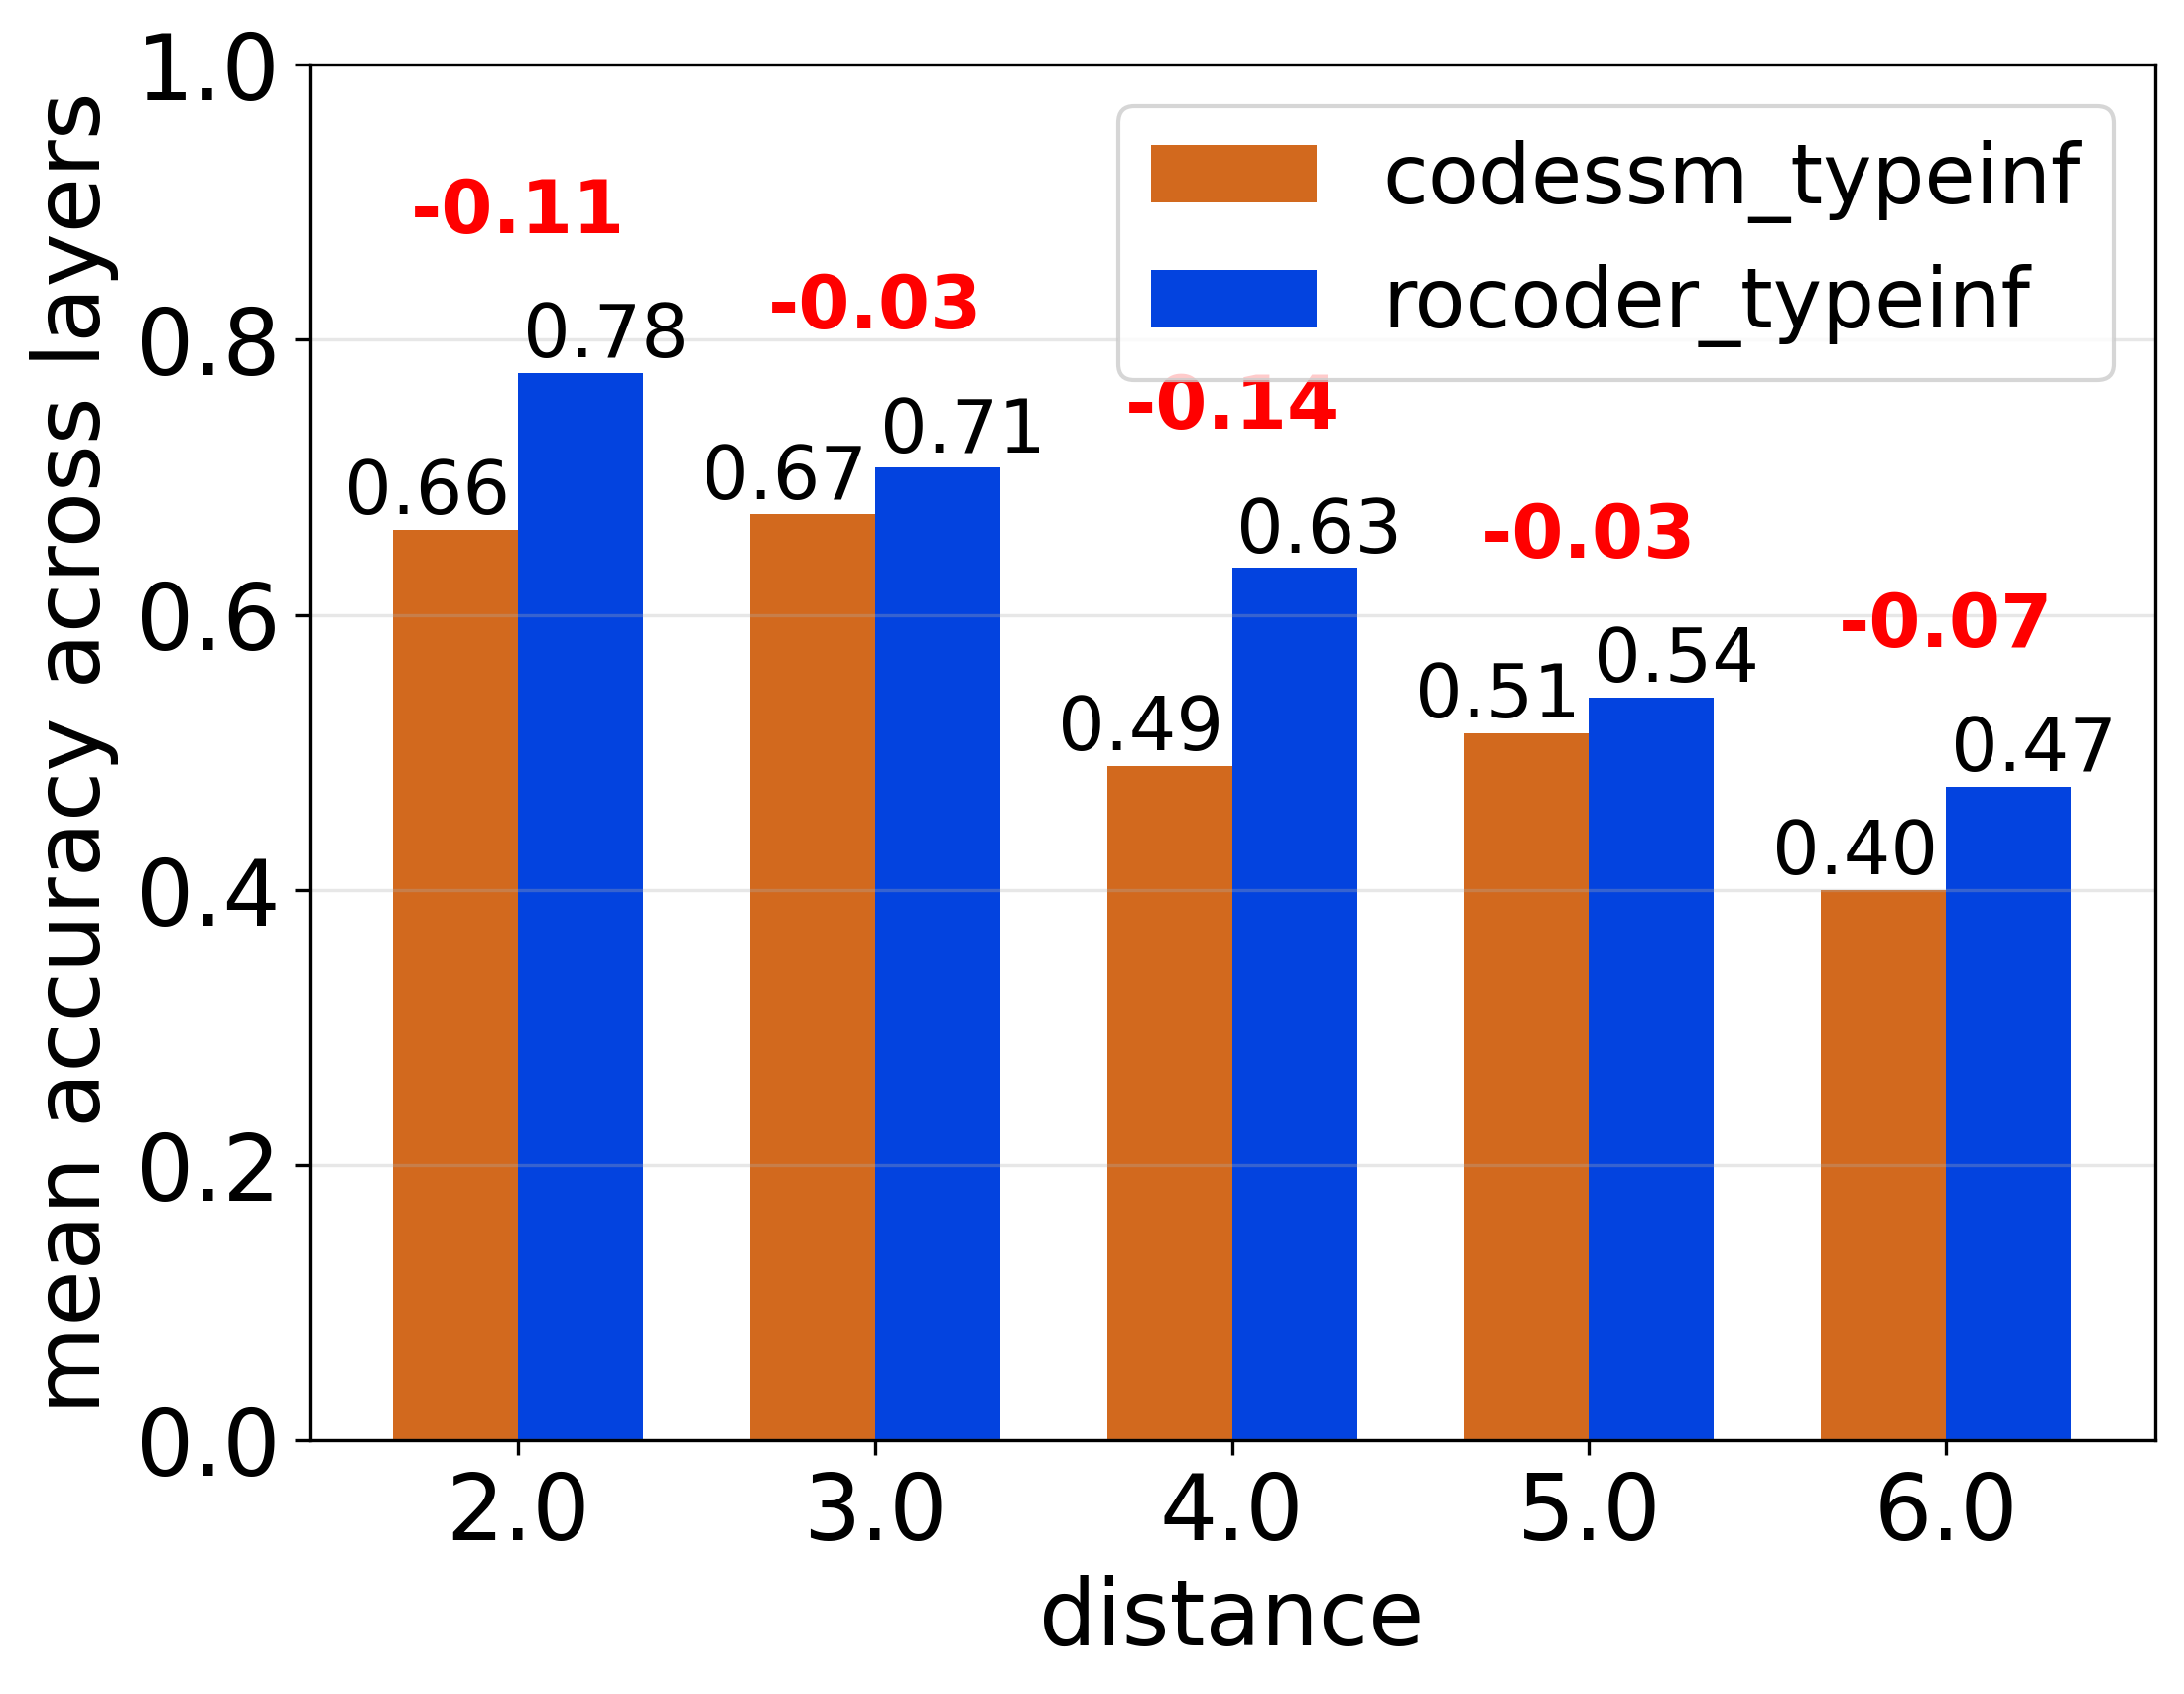

Accuracy_codessm_typeinf_and_rocoder_typeinf_distance_task_at_8_layer


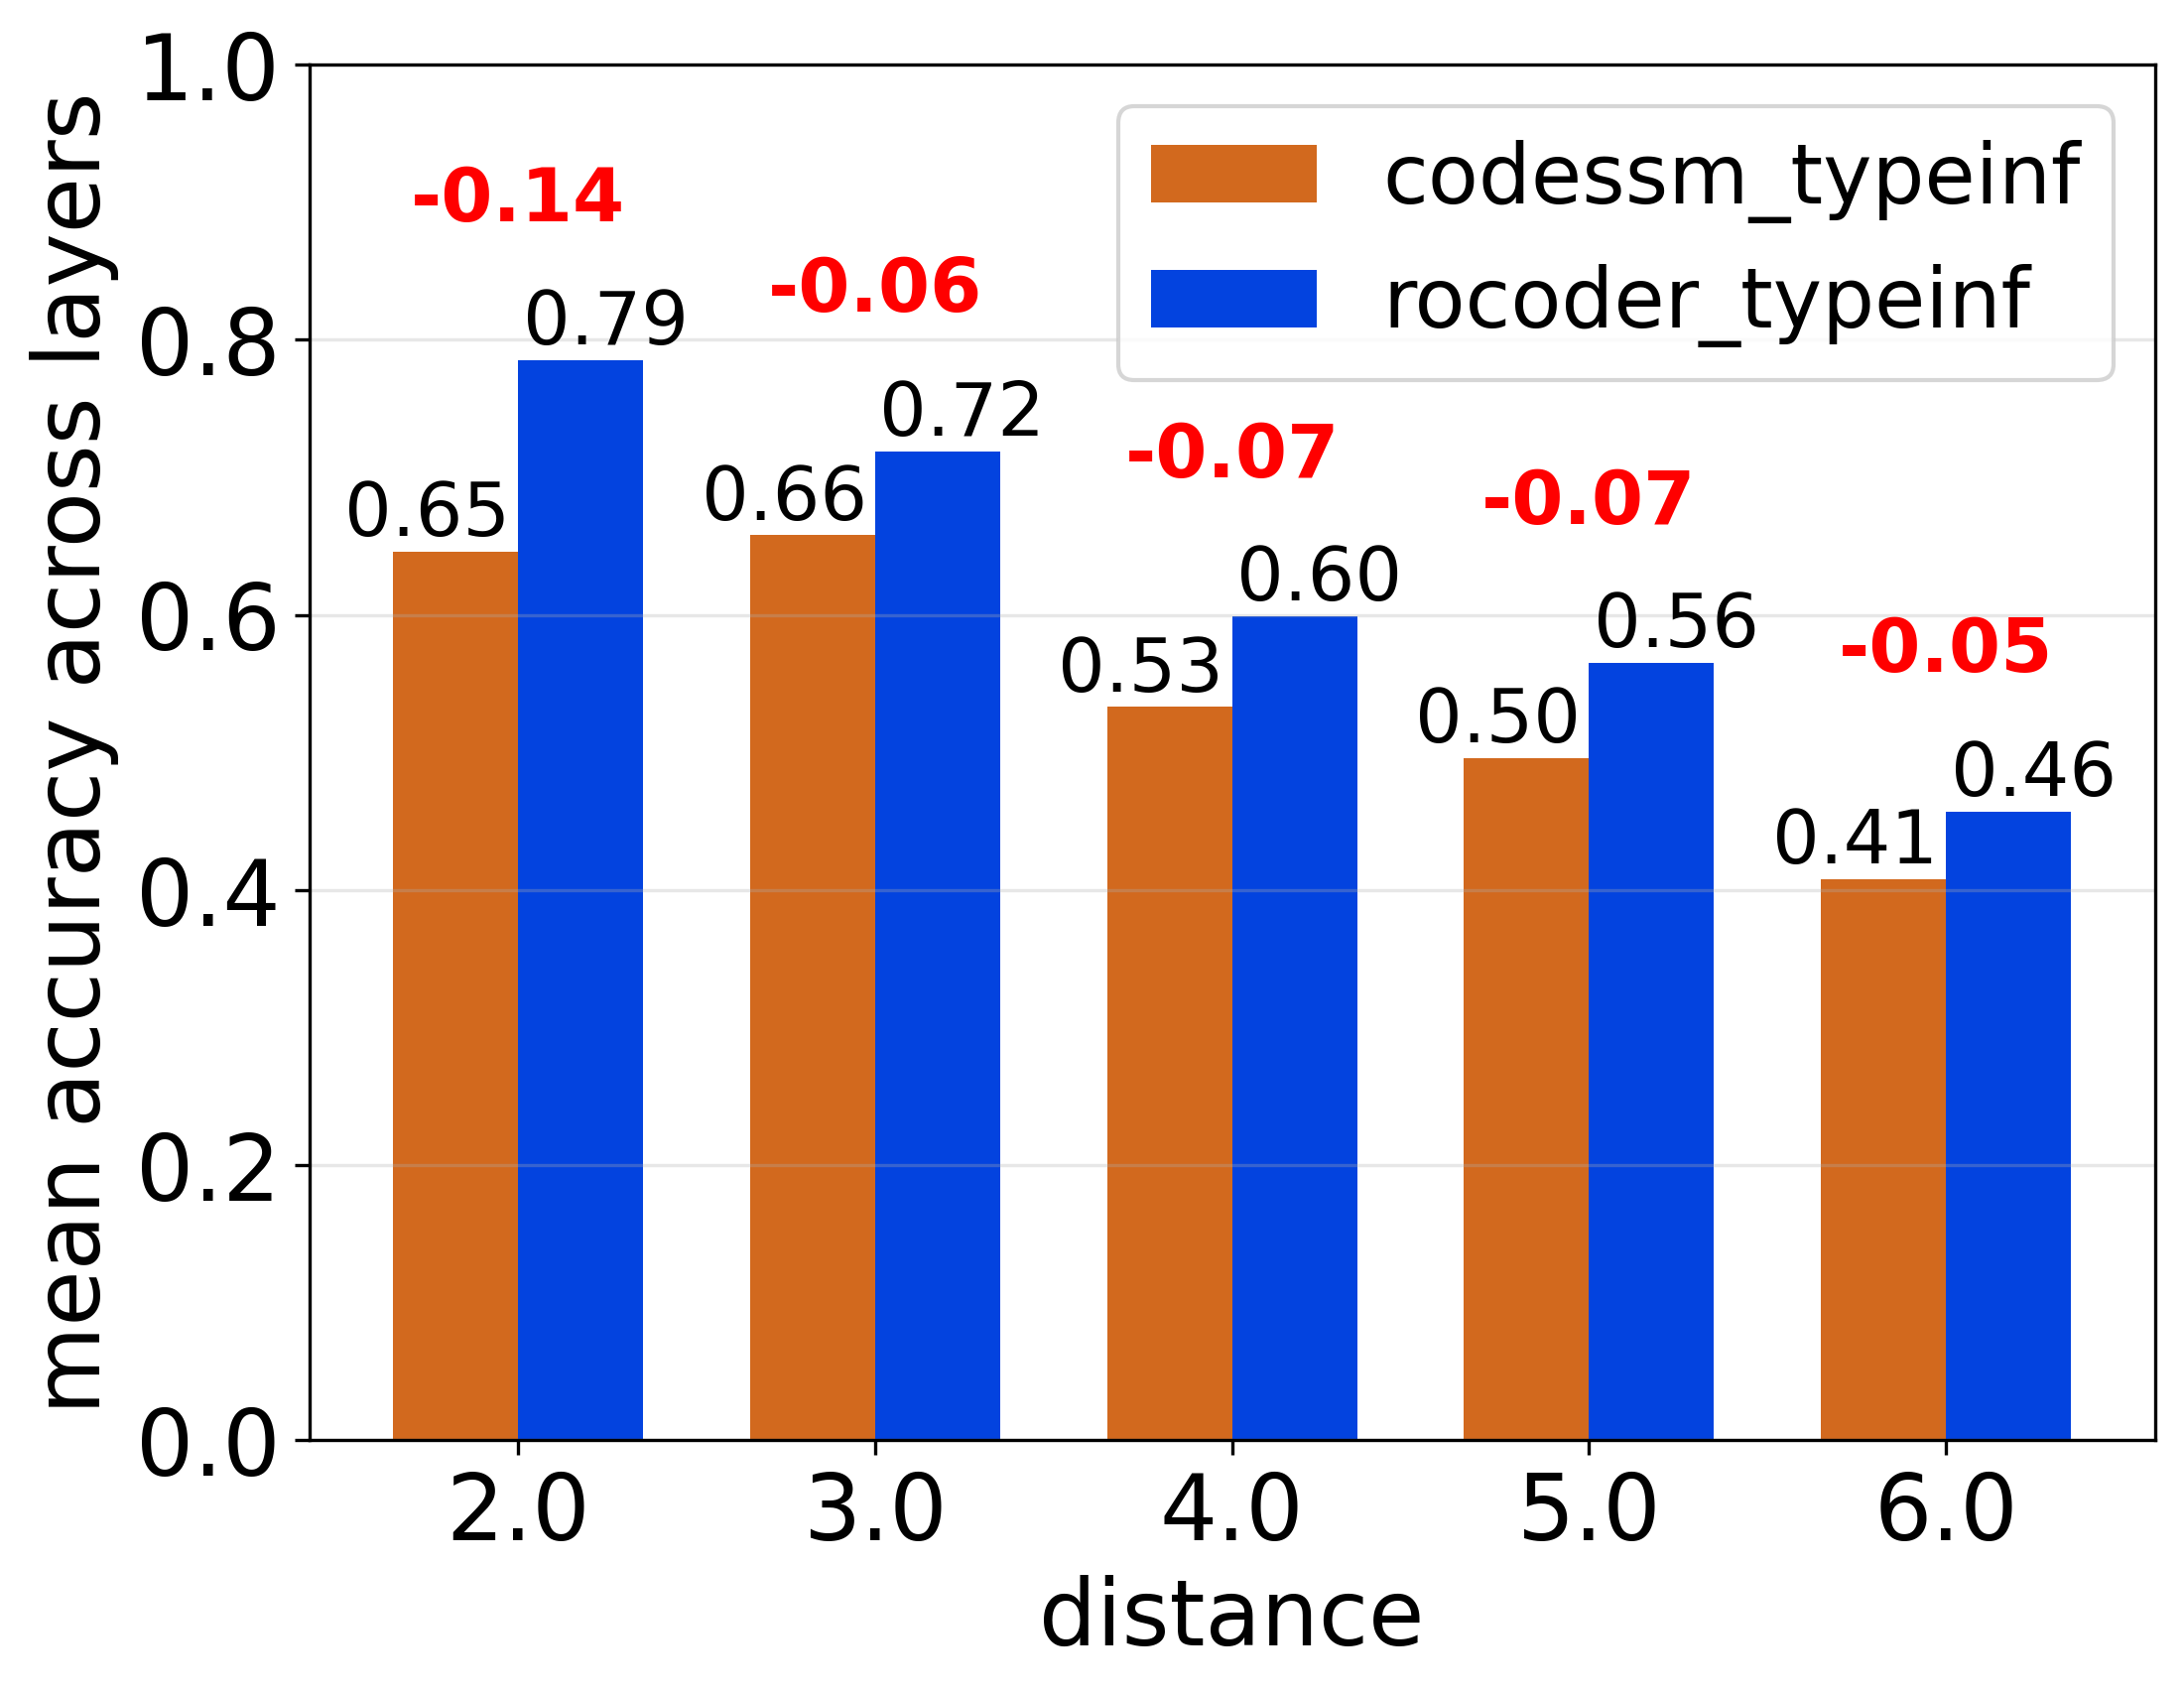

Accuracy_codessm_typeinf_and_rocoder_typeinf_distance_task_at_10_layer


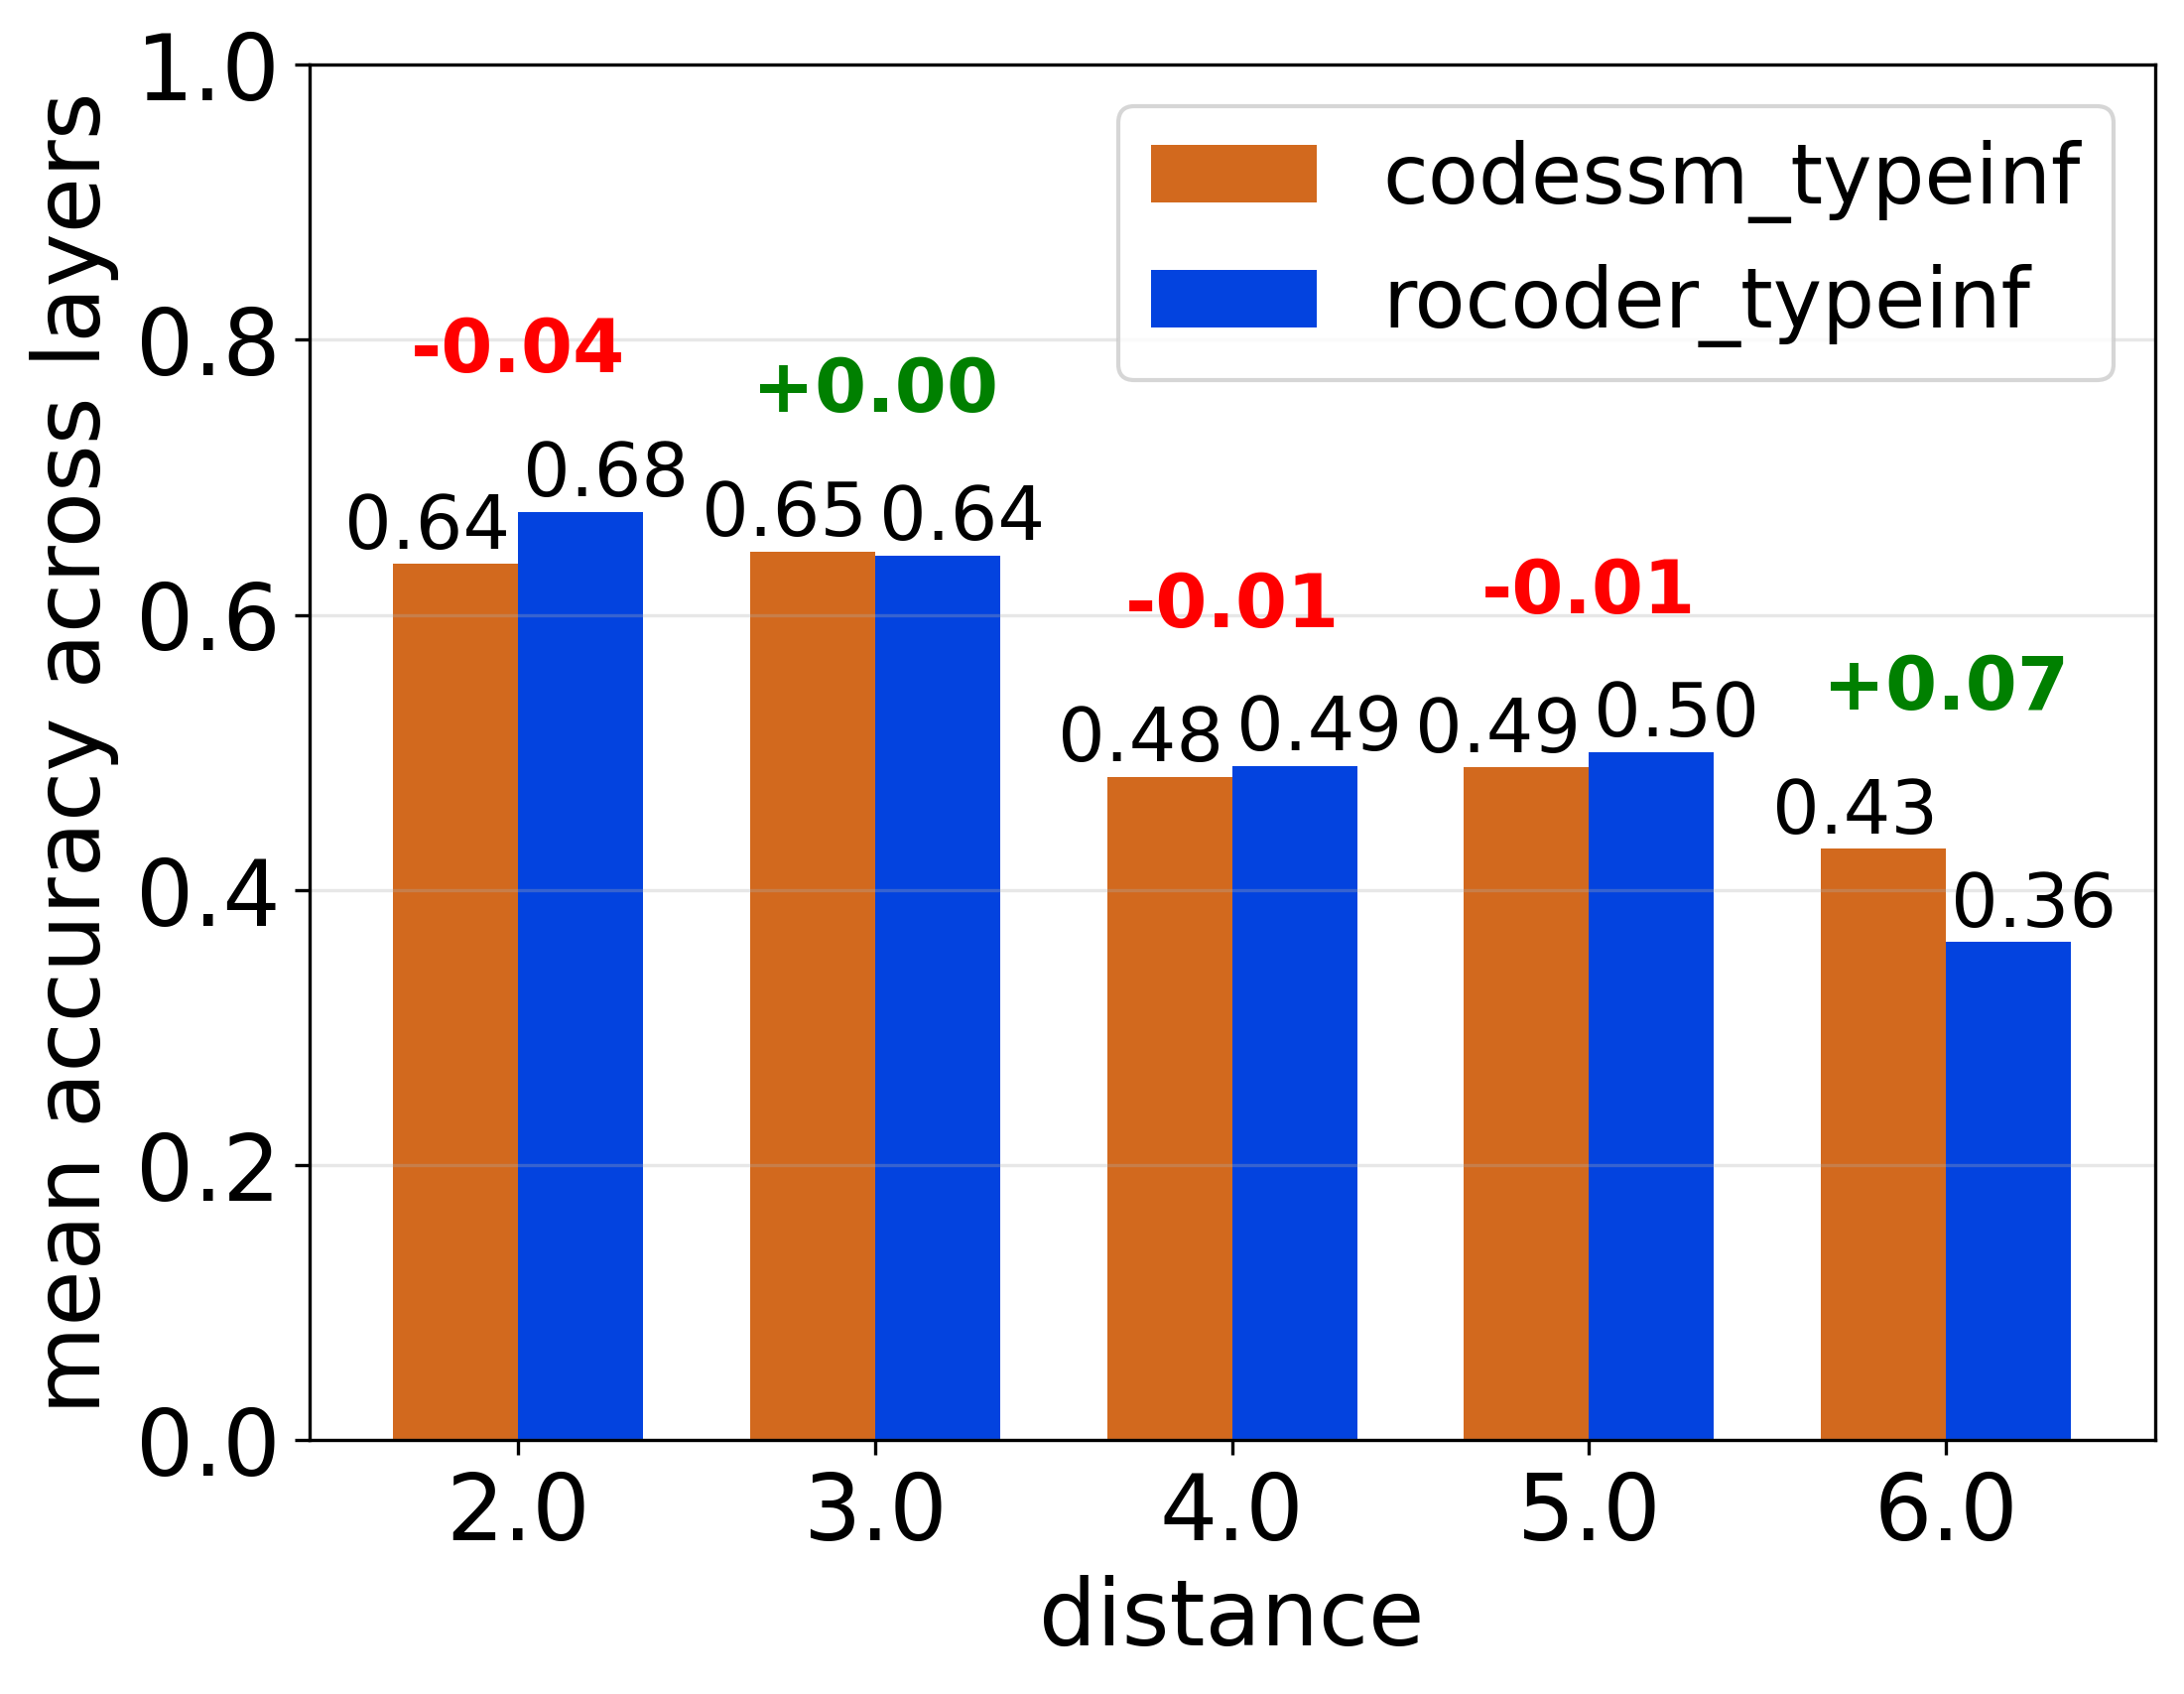

In [ ]:
res_dir = '../DirectProbe/results/'
color1 ='#D2691E'
color2 = '#0343DF'
layers = [6,8,10]
plot_distance('codessm_typeinf','rocoder_typeinf',color1,color2,layers)